# Survival Analysis of Blood-Based Biomarkers in Alzheimer’s Disease

This notebook explores whether blood-based biomarkers improve prediction of Alzheimer’s disease progression beyond baseline clinical diagnosis. The analysis uses longitudinal data and applies both Cox proportional hazards models and Random Survival Forests (RSF) to model time-to-event outcomes.

## 1. Package Import and Setup

This section imports the Python packages required for data manipulation, visualisation, and survival modelling. These libraries support exploratory data analysis, Cox proportional hazards modelling, Random Survival Forests, and evaluation metrics such as the concordance index and integrated Brier score.

In [ ]:
#Install packages
!pip -q install lifelines scikit-survival missingno seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 12.2 MB/s eta 0:00:00


In [ ]:
#Import packages
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, integrated_brier_score

## 2. Data Loading

This section loads the merged dataset containing participant identifiers, clinical diagnosis, visit dates, and blood-based biomarker measurements. The dataset is the starting point for all subsequent preprocessing, exploratory analysis, and survival modelling.

In [ ]:
#Load data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.chdir("/content/drive/MyDrive/Colab Docs/PROJ518")
os.getcwd()

'/content/drive/MyDrive/Colab Docs/PROJ518'

In [ ]:
df = pd.read_csv("MERGED_TIMEPOINTS_CLEAN_BIOMARKERS.csv")
df.head()

,RID,Visit.Code,Exam.Date,PT217,FQ_AB42,FQ_AB40,FQ_AB42_AB40,FQ_pT217_AB42,FQ_NFL,FQ_GFAP,DX,CDRSB,MMSE,ADAS13,ADAS11ish,Gender,APOE4
0,10,bl,2005-11-10,0.472,24.44,332.15,0.073581,0.019313,26.5,194.3,AD,NaN,NaN,24.33,12.33,Female,1.0
1,10,m24,2007-11-07,0.586,19.61,288.14,0.068057,0.029883,30.2,221.3,AD,5.0,28.0,30.33,19.33,Female,1.0
2,93,bl,2006-01-26,1.021,25.05,359.49,0.069682,0.040758,48.6,364.4,AD,NaN,NaN,36.67,22.67,Female,1.0
3,93,m24,2008-01-28,1.204,21.65,316.65,0.068372,0.055612,62.4,587.0,AD,17.0,4.0,NaN,NaN,Female,1.0
4,108,bl,2006-02-14,0.606,26.65,317.70,0.083884,0.022739,33.4,257.3,MCI,NaN,NaN,21.00,13.00,Male,1.0


## 3. Data Cleaning and Date Processing

This section prepares the raw dataset for analysis. Clinical diagnosis values are mapped to an ordinal scale, visit dates are converted to datetime format, and records are sorted by participant and visit date. Time since baseline is then calculated for each visit, providing the time variable needed for longitudinal exploration and survival analysis.

In [ ]:
#Cleaning and data handing
# Drop missing diagnosis
df = df.dropna(subset=["DX"]).copy()

# Parse dates
df["Exam.Date"] = pd.to_datetime(df["Exam.Date"], errors="coerce")
df = df.dropna(subset=["Exam.Date"]).copy()

# Sort by participant and time
df = df.sort_values(["RID", "Exam.Date"]).copy()

# Diagnosis mapping
dx_map = {"CN": 0, "MCI": 1, "AD": 2}
df["DX_score"] = df["DX"].map(dx_map)

# Remove rows with unknown mapped diagnoses
df = df.dropna(subset=["DX_score"]).copy()
df["DX_score"] = df["DX_score"].astype(int)

# Baseline date and time since baseline
df["baseline_date"] = df.groupby("RID")["Exam.Date"].transform("min")
df["time_years"] = (df["Exam.Date"] - df["baseline_date"]).dt.days / 365.25

print(df.shape)
df[["RID", "DX", "DX_score", "Exam.Date", "baseline_date", "time_years"]].head()

(400, 20)


,RID,DX,DX_score,Exam.Date,baseline_date,time_years
0,10,AD,2,2005-11-10,2005-11-10,0.000000
1,10,AD,2,2007-11-07,2005-11-10,1.990418
2,93,AD,2,2006-01-26,2006-01-26,0.000000
3,93,AD,2,2008-01-28,2006-01-26,2.004107
4,108,MCI,1,2006-02-14,2006-02-14,0.000000


## 4. Baseline Variables and Biomarker Selection

This section identifies the baseline diagnosis and key biomarker variables used throughout the analysis. Baseline diagnosis is retained because the project evaluates whether biomarkers improve prediction beyond diagnosis alone. The selected biomarkers represent amyloid, tau, neurodegeneration, and glial activation processes relevant to Alzheimer’s disease.

In [ ]:
#Baseline variables and covariates
biomarkers = ["PT217", "FQ_NFL", "FQ_GFAP", "FQ_AB42_AB40", "FQ_pT217_AB42"]

# Baseline diagnosis for each participant
baseline = (
    df.sort_values(["RID", "Exam.Date"])
      .groupby("RID")
      .head(1)[["RID", "DX", "DX_score"] + [c for c in biomarkers if c in df.columns]]
      .rename(columns={"DX": "DX_baseline", "DX_score": "DX_score_baseline"})
)

df = df.merge(baseline[["RID", "DX_baseline", "DX_score_baseline"]], on="RID", how="left")

print(df.shape)
baseline.head()

(400, 22)


,RID,DX_baseline,DX_score_baseline,PT217,FQ_NFL,FQ_GFAP,FQ_AB42_AB40,FQ_pT217_AB42
0,10,AD,2,0.472,26.5,194.3,0.073581,0.019313
2,93,AD,2,1.021,48.6,364.4,0.069682,0.040758
4,108,MCI,1,0.606,33.4,257.3,0.083884,0.022739
6,149,AD,2,0.290,44.0,335.3,0.070762,0.013615
8,183,AD,2,1.444,40.7,413.1,0.070731,0.065399


## 5. Initial Data Overview

This section provides a basic overview of the dataset structure and variable distributions. It is used to confirm that the data have been loaded and processed correctly before proceeding to more detailed exploratory analysis.

In [ ]:
print(df.dtypes)
print(df[["RID", "DX", "DX_score", "DX_baseline", "DX_score_baseline"] + biomarkers].describe(include="all"))

RID                           int64
Visit.Code                   object
Exam.Date            datetime64[ns]
PT217                       float64
FQ_AB42                     float64
FQ_AB40                     float64
FQ_AB42_AB40                float64
FQ_pT217_AB42               float64
FQ_NFL                      float64
FQ_GFAP                     float64
DX                           object
CDRSB                       float64
MMSE                        float64
ADAS13                      float64
ADAS11ish                   float64
Gender                       object
APOE4                       float64
DX_score                      int64
baseline_date        datetime64[ns]
time_years                  float64
DX_baseline                  object
DX_score_baseline             int64
dtype: object
                 RID   DX    DX_score DX_baseline  DX_score_baseline  \
count     400.000000  400  400.000000         400         400.000000   
unique           NaN    3         NaN           3 

## 6. Missing Data Assessment

This section examines the extent and pattern of missing data across variables. Missingness is important to evaluate because incomplete biomarker or follow-up information may affect model fitting, subgroup analyses, and interpretation of results. Visual and numerical summaries are used to identify variables with limited coverage.

RID              0.0
DX               0.0
Exam.Date        0.0
PT217            0.0
FQ_NFL           0.0
FQ_GFAP          0.0
FQ_AB42_AB40     0.0
FQ_pT217_AB42    0.0
dtype: float64


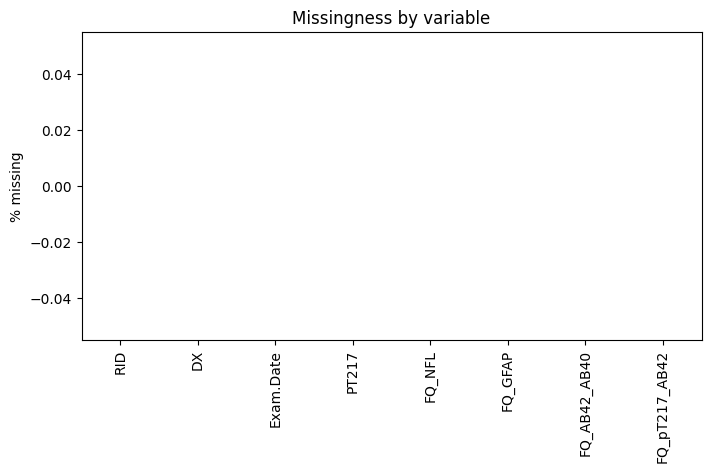

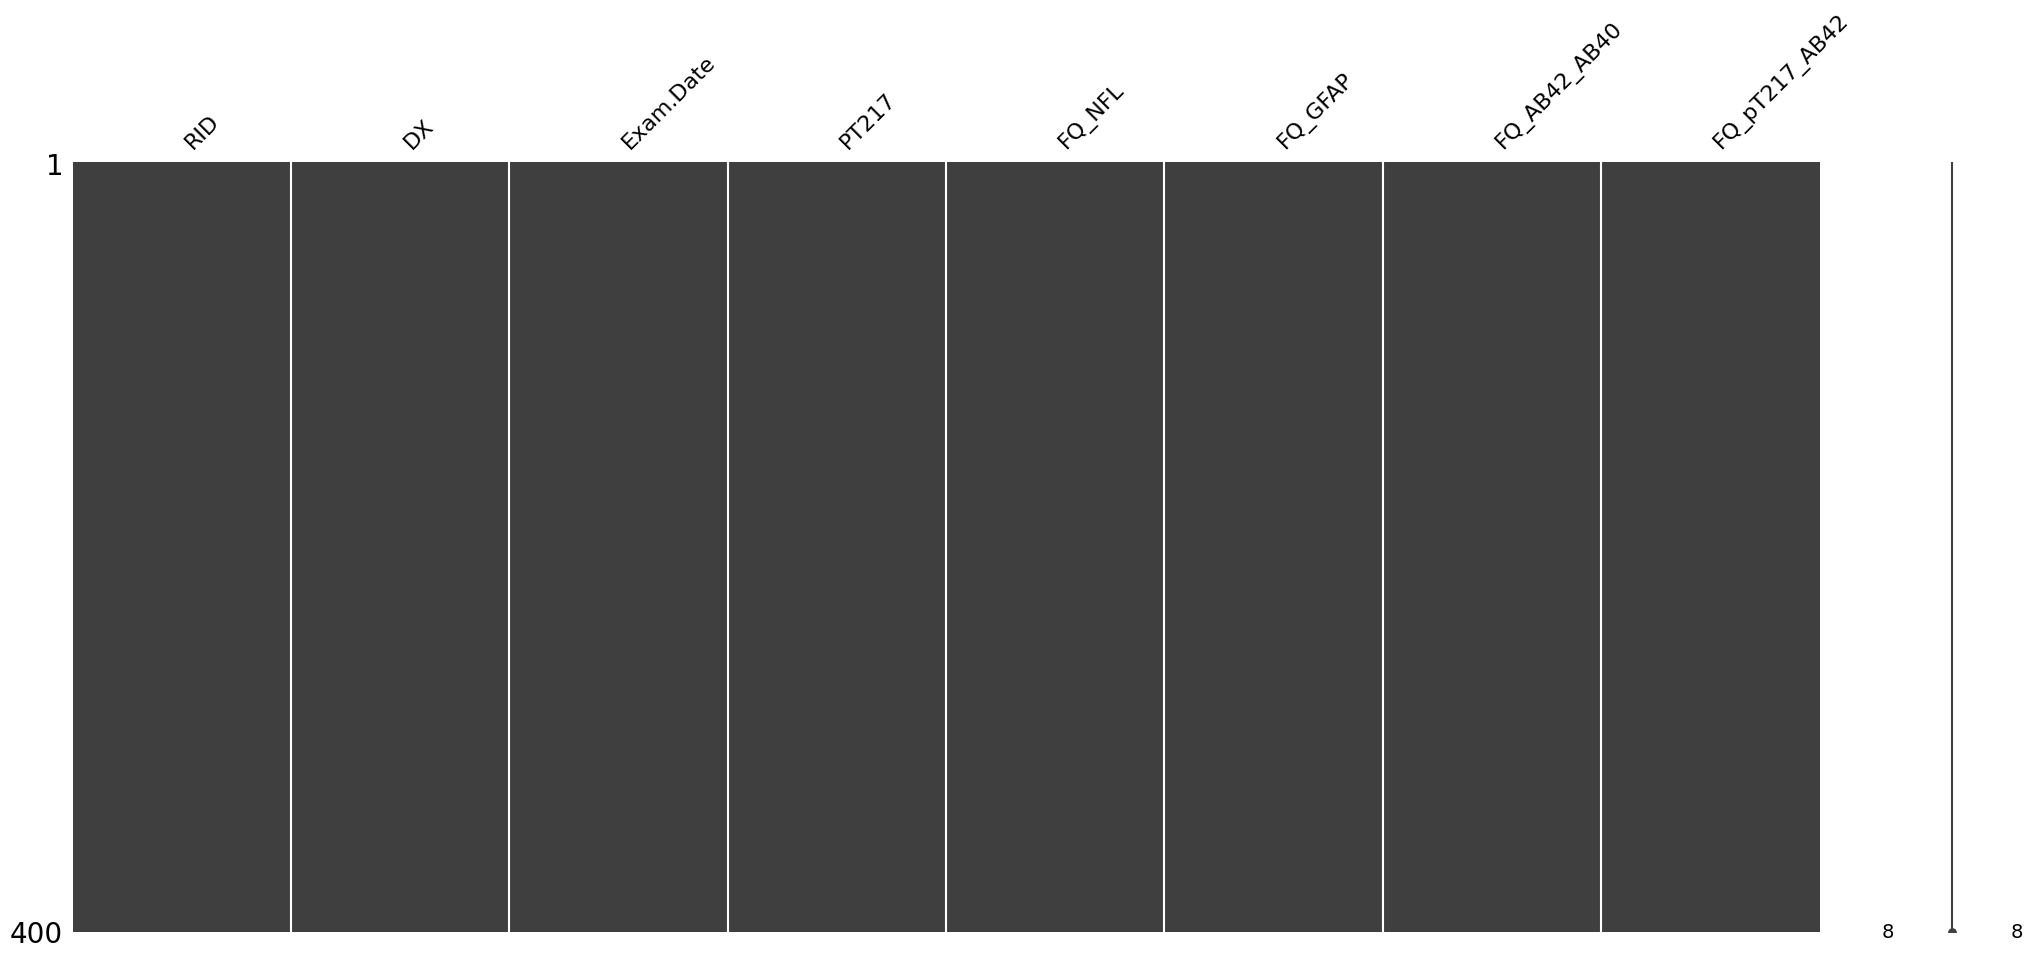

In [ ]:
#Missing data analysis
missing_summary = df[["RID", "DX", "Exam.Date"] + biomarkers].isna().mean().sort_values(ascending=False) * 100
print(missing_summary)

plt.figure(figsize=(8, 4))
missing_summary.plot(kind="bar")
plt.ylabel("% missing")
plt.title("Missingness by variable")
plt.show()

msno.matrix(df[["RID", "DX", "Exam.Date"] + biomarkers])
plt.show()

## 7. Distribution of Biomarkers

This section explores the distribution of each biomarker using histograms and density plots. Examining these distributions helps identify skewness, outliers, and possible transformation needs. This is particularly relevant for blood-based biomarkers, which often show non-normal distributions.

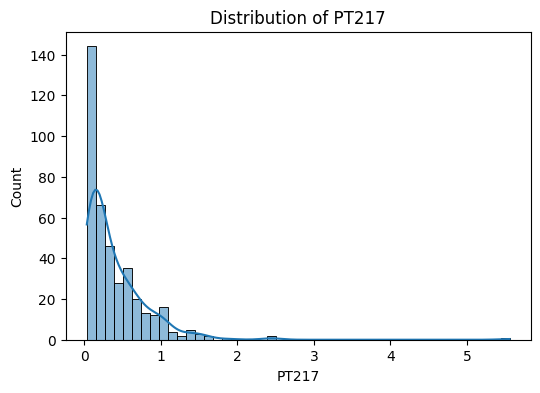

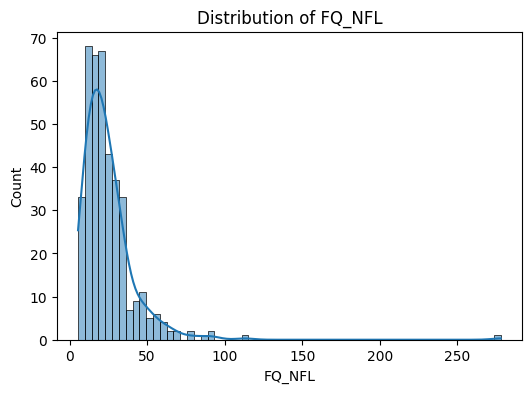

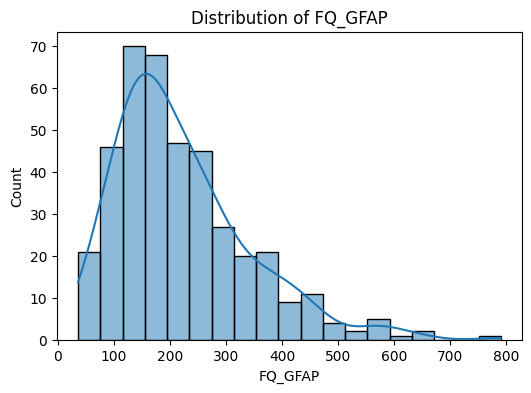

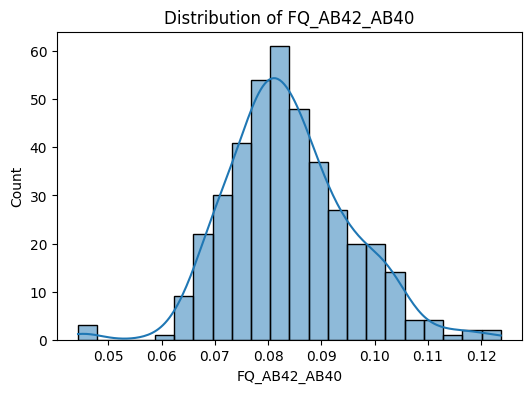

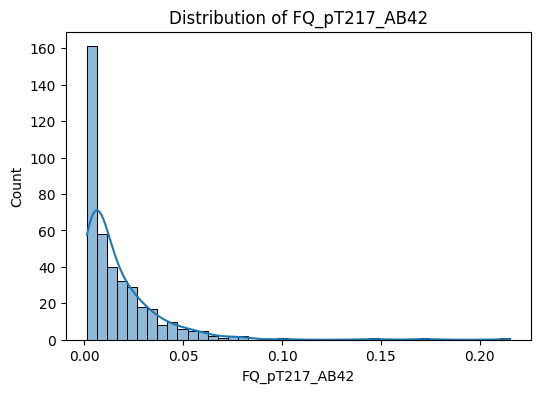

In [ ]:
#Exploratory distributions
for col in biomarkers:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.show()

## 8. Biomarker Levels by Baseline Diagnosis

This section compares biomarker values across clinical diagnostic groups. These plots help assess whether biomarker levels differ between cognitively normal, mild cognitive impairment, and Alzheimer’s disease groups, providing an initial descriptive view of their clinical relevance.

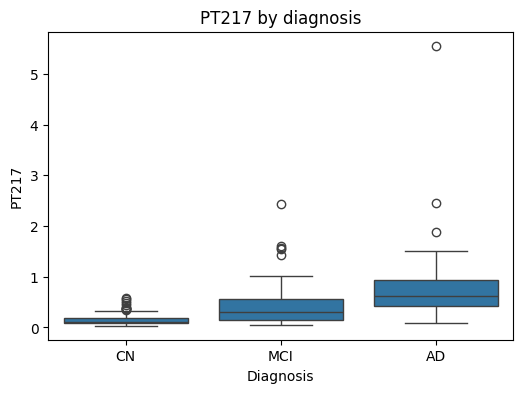

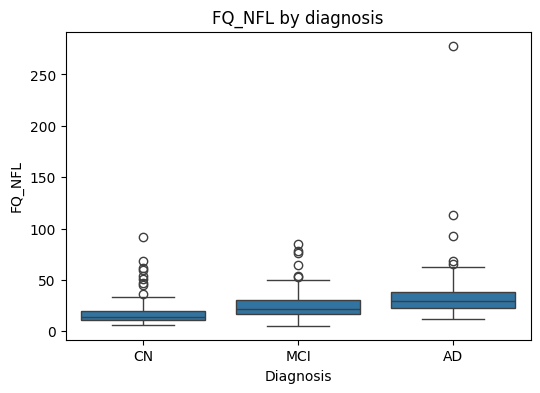

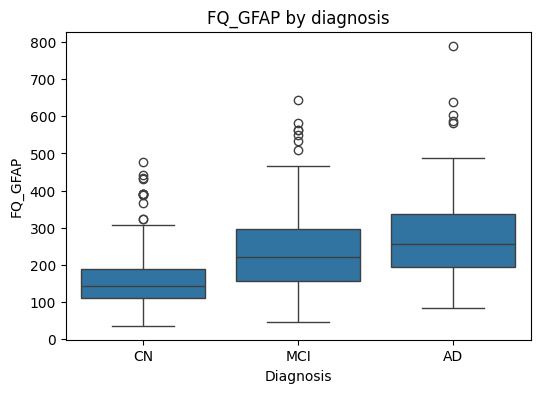

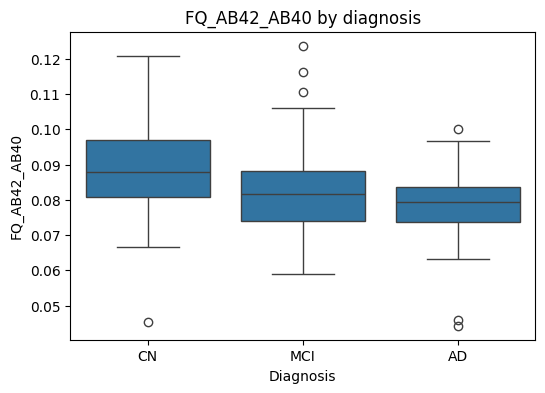

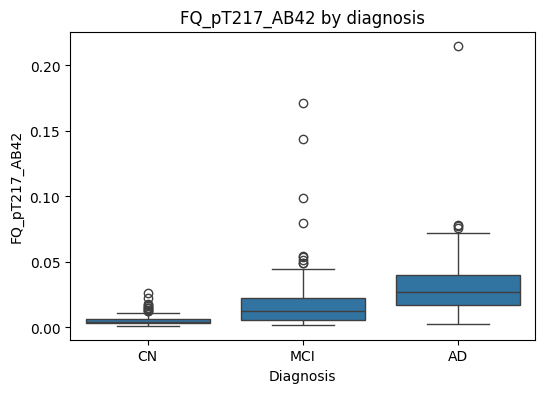

In [ ]:
#Biomarker distributions by diagnosis
for col in biomarkers:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=df, x="DX", y=col, order=["CN", "MCI", "AD"])
        plt.title(f"{col} by diagnosis")
        plt.xlabel("Diagnosis")
        plt.ylabel(col)
        plt.show()

## 9. Correlation Between Biomarkers

This section assesses pairwise correlations between biomarkers. Correlation analysis is useful for identifying overlap between markers, potential collinearity in multivariable models, and whether different biomarkers capture related or distinct aspects of disease biology.

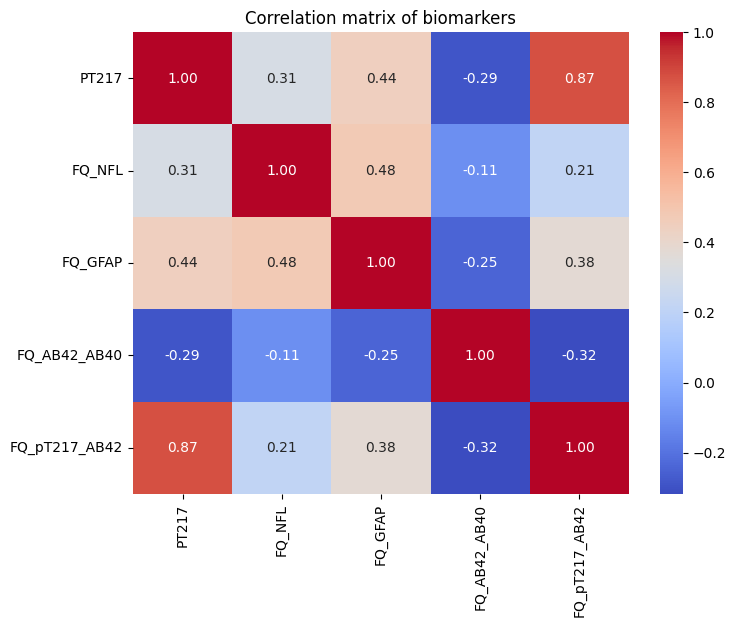

In [ ]:
#Correlation matrix
corr_df = df[biomarkers].copy()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix of biomarkers")
plt.show()

## 10. Longitudinal Biomarker Trajectories

This section visualises how biomarker values change over time. Mean trajectory plots and individual-level spaghetti plots are used to assess whether biomarker patterns differ by baseline diagnosis or progression status. This supports the project’s interest in modelling disease progression longitudinally rather than relying only on baseline measurements.

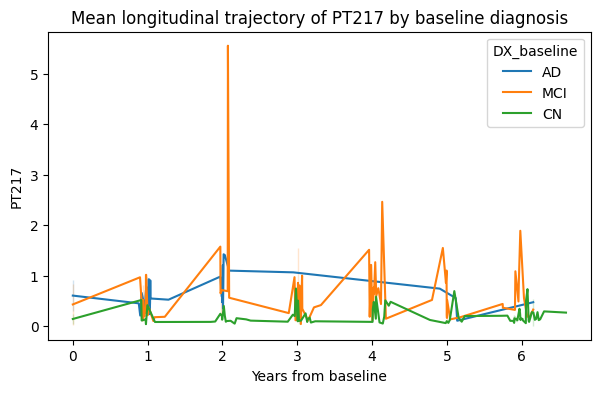

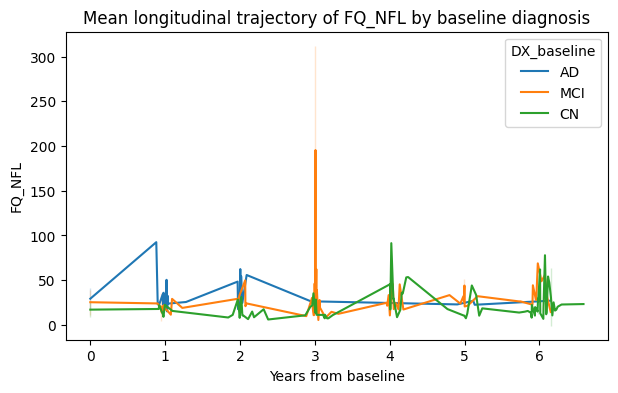

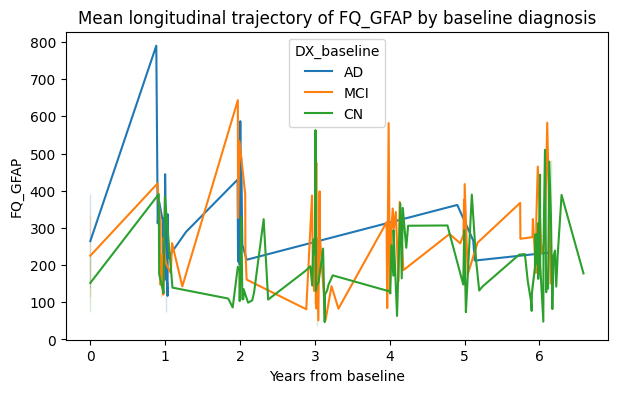

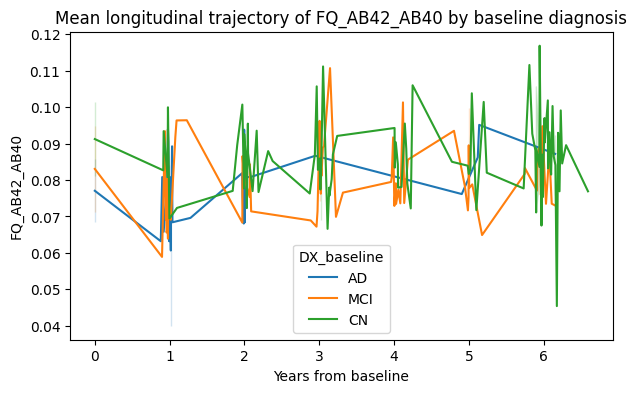

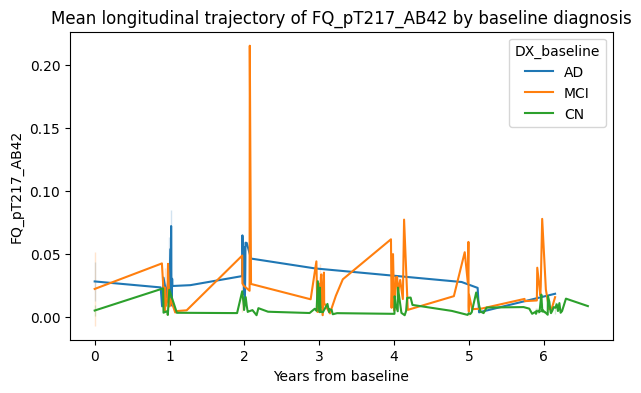

In [ ]:
#Longitudinal biomarker trajectories
for col in biomarkers:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        sns.lineplot(
            data=df,
            x="time_years",
            y=col,
            hue="DX_baseline",
            estimator="mean",
            errorbar="sd"
        )
        plt.title(f"Mean longitudinal trajectory of {col} by baseline diagnosis")
        plt.xlabel("Years from baseline")
        plt.ylabel(col)
        plt.show()

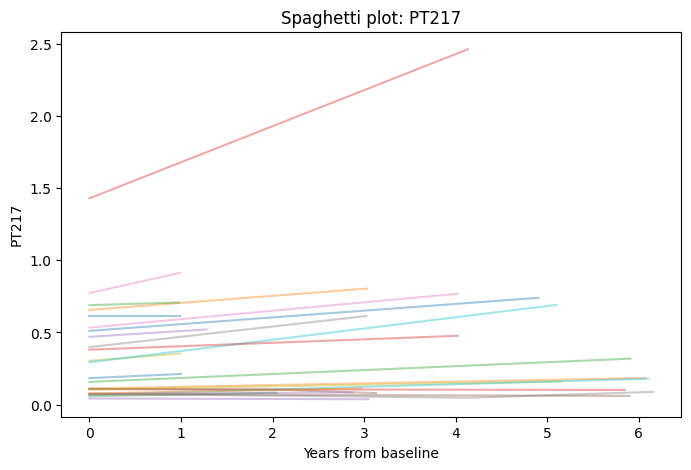

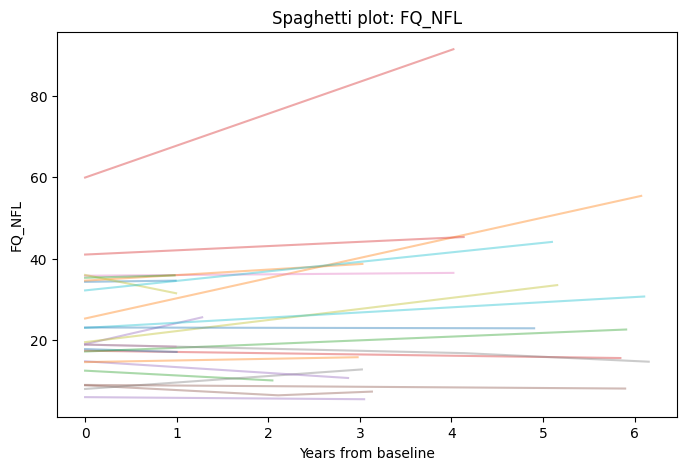

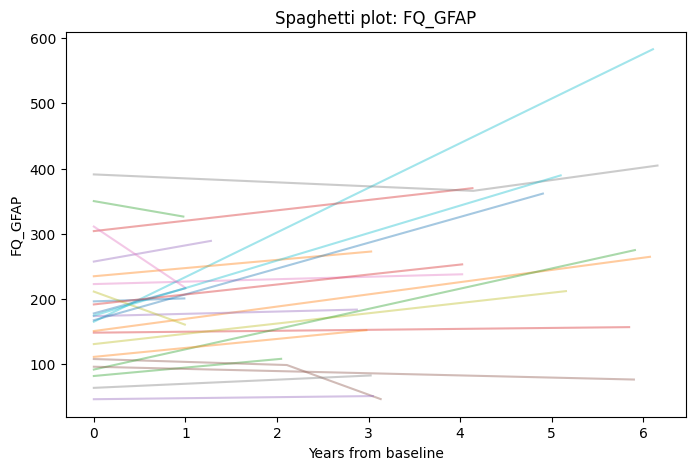

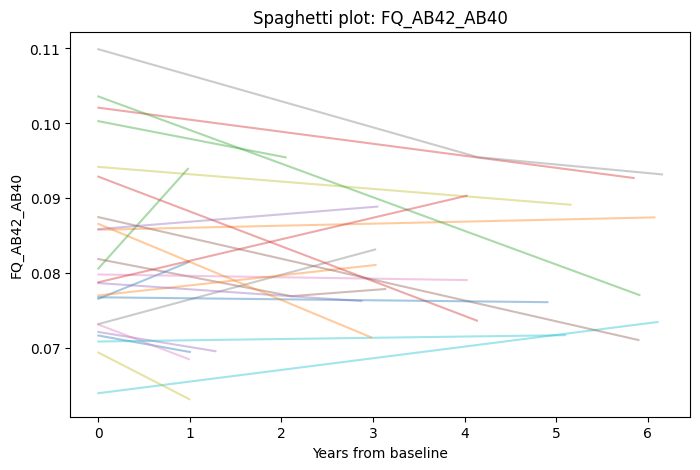

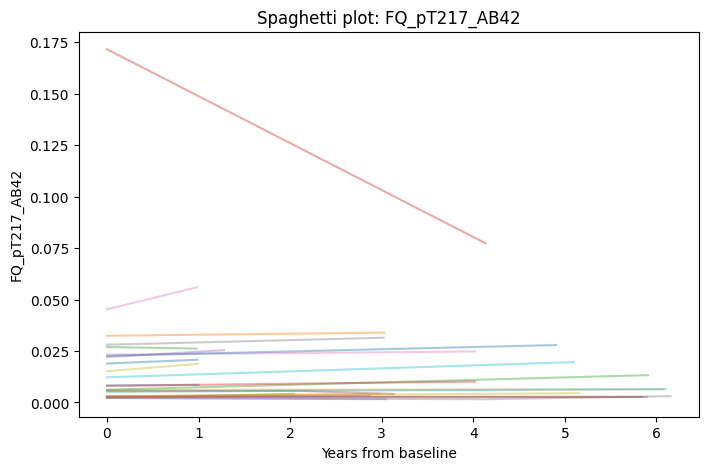

In [ ]:
#Spaghetti plots
np.random.seed(42)
sample_ids = np.random.choice(df["RID"].unique(), size=min(25, df["RID"].nunique()), replace=False)

for col in biomarkers:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        for rid in sample_ids:
            sub = df[df["RID"] == rid]
            plt.plot(sub["time_years"], sub[col], alpha=0.4)
        plt.title(f"Spaghetti plot: {col}")
        plt.xlabel("Years from baseline")
        plt.ylabel(col)
        plt.show()

## 11. Construction of Survival Endpoints

This section defines the time-to-event outcomes used in the survival analysis. Two clinically meaningful endpoints are created:

- **Endpoint A:** any clinical worsening, defined as progression from cognitively normal to mild cognitive impairment or from mild cognitive impairment to Alzheimer’s disease  
- **Endpoint B:** conversion to Alzheimer’s disease among participants who were not diagnosed with Alzheimer’s disease at baseline  

These endpoints allow disease progression to be modelled as a time-to-event process.

In [ ]:
#Build survival timepoints
#Endpoint A: Any worsening - CN → MCI or AD or MCI → AD
def make_survival_any_worsening(df_in: pd.DataFrame, baseline_covars: list[str]) -> pd.DataFrame:
    d = df_in.sort_values(["RID", "Exam.Date"]).copy()
    d["prev_dx"] = d.groupby("RID")["DX_score"].shift(1)
    d["worsen"] = (d["DX_score"] > d["prev_dx"]).fillna(False)

    base = d.groupby("RID").head(1)[["RID", "baseline_date"] + baseline_covars].copy()

    first_w = (
        d.loc[d["worsen"]]
         .groupby("RID")
         .head(1)[["RID", "Exam.Date"]]
         .rename(columns={"Exam.Date": "event_date"})
    )

    last = d.groupby("RID").tail(1)[["RID", "Exam.Date"]].rename(columns={"Exam.Date": "last_date"})

    out = base.merge(first_w, on="RID", how="left").merge(last, on="RID", how="left")
    out["event"] = out["event_date"].notna().astype(int)
    out["end_date"] = np.where(out["event"] == 1, out["event_date"], out["last_date"])
    out["time_years"] = (pd.to_datetime(out["end_date"]) - pd.to_datetime(out["baseline_date"])).dt.days / 365.25

    out = out.drop(columns=["event_date", "last_date", "end_date"])
    out = out.dropna(subset=["time_years"])
    out = out[out["time_years"] >= 0].copy()
    return out

In [ ]:
#Endpoint B: conversion to AD among non-AD at baseline
def make_survival_conversion_to_ad_baseline_nonad(df_in: pd.DataFrame, baseline_covars: list[str]) -> pd.DataFrame:
    d = df_in.sort_values(["RID", "Exam.Date"]).copy()

    baseline_rows = d.groupby("RID").head(1).copy()
    eligible_ids = baseline_rows.loc[baseline_rows["DX_score"] < 2, "RID"]

    d = d[d["RID"].isin(eligible_ids)].copy()

    base = d.groupby("RID").head(1)[["RID", "baseline_date"] + baseline_covars].copy()

    first_ad = (
        d.loc[d["DX_score"] == 2]
         .groupby("RID")
         .head(1)[["RID", "Exam.Date"]]
         .rename(columns={"Exam.Date": "event_date"})
    )

    last = d.groupby("RID").tail(1)[["RID", "Exam.Date"]].rename(columns={"Exam.Date": "last_date"})

    out = base.merge(first_ad, on="RID", how="left").merge(last, on="RID", how="left")
    out["event"] = out["event_date"].notna().astype(int)
    out["end_date"] = np.where(out["event"] == 1, out["event_date"], out["last_date"])
    out["time_years"] = (pd.to_datetime(out["end_date"]) - pd.to_datetime(out["baseline_date"])).dt.days / 365.25

    out = out.drop(columns=["event_date", "last_date", "end_date"])
    out = out.dropna(subset=["time_years"])
    out = out[out["time_years"] >= 0].copy()
    return out

## 12. Survival Datasets

This section creates the participant-level datasets used for modelling the survival outcomes. Each dataset contains follow-up time, event status, baseline diagnosis, and biomarker variables. These datasets form the basis for Cox and Random Survival Forest analyses.

In [ ]:
#Create survival datasets
baseline_covars = ["DX_score_baseline"] + [c for c in biomarkers if c in df.columns]

surv_worsen = make_survival_any_worsening(df, baseline_covars)
surv_ad = make_survival_conversion_to_ad_baseline_nonad(df, baseline_covars)

print("Endpoint A:", surv_worsen.shape, "events =", int(surv_worsen["event"].sum()))
print("Endpoint B:", surv_ad.shape, "events =", int(surv_ad["event"].sum()))

Endpoint A: (195, 10) events = 52
Endpoint B: (157, 10) events = 34


## 13. Standardisation of Biomarker Variables

This section standardises biomarker values to improve comparability across variables and model stability. Standardisation is particularly useful when biomarkers are measured on different scales and when coefficients or effect sizes need to be interpreted relative to standard deviations.

In [ ]:
#Standardise biomarker variable
def zscore_columns(df_in: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df_in.copy()
    for c in cols:
        if c in out.columns:
            mu = out[c].mean()
            sd = out[c].std()
            if pd.notna(sd) and sd != 0:
                out[c] = (out[c] - mu) / sd
    return out

surv_worsen_z = zscore_columns(surv_worsen, biomarkers)
surv_ad_z = zscore_columns(surv_ad, biomarkers)

## 14. Kaplan–Meier Survival Curves

This section plots Kaplan–Meier survival curves for key groups, such as baseline diagnosis categories or model-derived risk groups. These plots provide a non-parametric visual summary of time to progression and help illustrate differences in survival experience between groups before and after modelling.

In [ ]:
#Kaplan–Meier plots by baseline diagnosis
def plot_km_by_group(d: pd.DataFrame, title: str, group_col: str):
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(7, 5))

    group_order = ["CN", "MCI", "AD", 0, 1, 2]
    groups = list(d[group_col].dropna().unique())
    groups = sorted(groups, key=lambda x: group_order.index(x) if x in group_order else 999)

    for g in groups:
        sub = d[d[group_col] == g]
        if len(sub) == 0:
            continue
        kmf.fit(sub["time_years"], sub["event"], label=f"{g} (n={len(sub)})")
        kmf.plot(ci_show=False)

    plt.title(title)
    plt.xlabel("Years from baseline")
    plt.ylabel("Survival probability")
    plt.grid(alpha=0.3)
    plt.show()

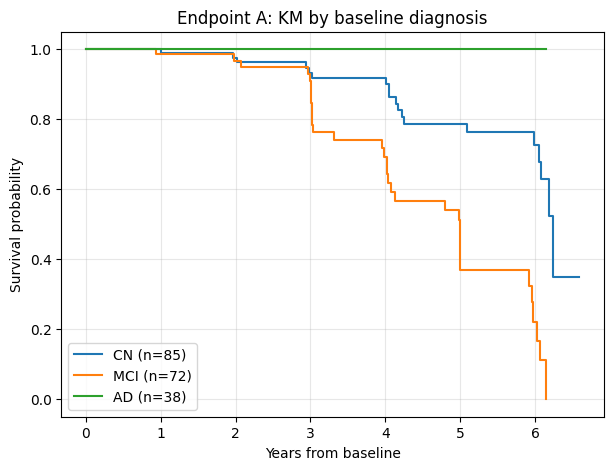

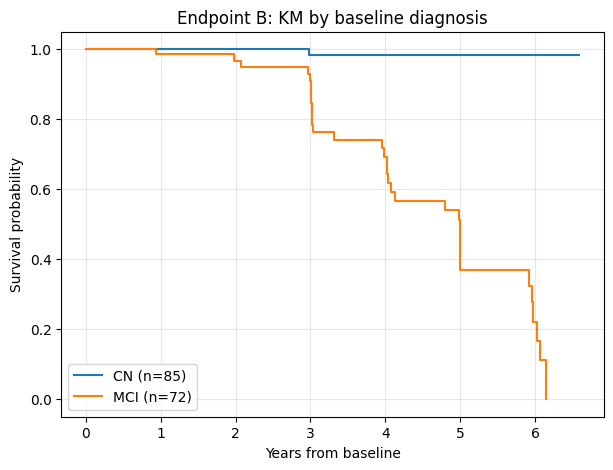

In [ ]:
# Add baseline diagnosis labels
dx_label_map = {0: "CN", 1: "MCI", 2: "AD"}

surv_worsen_z["DX_baseline_label"] = surv_worsen_z["DX_score_baseline"].map(dx_label_map)
surv_ad_z["DX_baseline_label"] = surv_ad_z["DX_score_baseline"].map(dx_label_map)

plot_km_by_group(surv_worsen_z, "Endpoint A: KM by baseline diagnosis", "DX_baseline_label")
plot_km_by_group(surv_ad_z, "Endpoint B: KM by baseline diagnosis", "DX_baseline_label")

## 15. Cox Proportional Hazards Modelling

This section applies Cox proportional hazards models to estimate the association between baseline predictors and time to disease progression. The Cox model is used because it is well established, interpretable, and appropriate for right-censored longitudinal data. It provides hazard ratios that quantify the relative effect of diagnosis and biomarkers on progression risk.

In [ ]:
#Cox models
model_sets = {
    "DX only": ["DX_score_baseline"],
    "DX + PT217": ["DX_score_baseline", "PT217"],
    "DX + PT217 + NFL": ["DX_score_baseline", "PT217", "FQ_NFL"],
    "DX + PT217 + GFAP": ["DX_score_baseline", "PT217", "FQ_GFAP"],
    "DX + all biomarkers": ["DX_score_baseline", "PT217", "FQ_NFL", "FQ_GFAP", "FQ_AB42_AB40", "FQ_pT217_AB42"]
}

In [ ]:
#Fit one Cox model
def fit_cox(surv_df: pd.DataFrame, covars: list[str]):
    d = surv_df[["time_years", "event"] + covars].dropna().copy()
    cph = CoxPHFitter()
    cph.fit(d, duration_col="time_years", event_col="event")
    return cph, d

In [ ]:
#Cross validated Cox performance
def cox_cv_cindex(surv_df: pd.DataFrame, covars: list[str], n_splits: int = 5):
    d = surv_df[["RID", "time_years", "event"] + covars].dropna().copy()
    groups = d["RID"].values
    gkf = GroupKFold(n_splits=n_splits)

    scores = []

    for train_idx, test_idx in gkf.split(d, groups=groups):
        train = d.iloc[train_idx].copy()
        test = d.iloc[test_idx].copy()

        cph = CoxPHFitter()
        cph.fit(train.drop(columns=["RID"]), duration_col="time_years", event_col="event")

        risk_scores = cph.predict_partial_hazard(test.drop(columns=["RID", "time_years", "event"]))
        cidx = concordance_index(
            test["time_years"],
            -risk_scores.values.flatten(),
            test["event"]
        )
        scores.append(cidx)

    return np.mean(scores), np.std(scores)

## 16. Comparison of Cox Models

This section compares Cox models with different sets of predictors, such as diagnosis alone, biomarkers alone, and combined models. The aim is to determine whether blood-based biomarkers improve predictive performance beyond baseline clinical diagnosis.

In [ ]:
def compare_cox_models(surv_df: pd.DataFrame, endpoint_name: str, model_sets: dict):
    rows = []
    for name, covars in model_sets.items():
        mean_c, sd_c = cox_cv_cindex(surv_df, covars)
        rows.append({
            "endpoint": endpoint_name,
            "model": name,
            "mean_cv_cindex": mean_c,
            "sd_cv_cindex": sd_c
        })
    return pd.DataFrame(rows).sort_values("mean_cv_cindex", ascending=False)

cox_table_A = compare_cox_models(surv_worsen_z, "Endpoint A", model_sets)
cox_table_B = compare_cox_models(surv_ad_z, "Endpoint B", model_sets)

print("Cox results - Endpoint A")
display(cox_table_A)

print("Cox results - Endpoint B")
display(cox_table_B)

Cox results - Endpoint A


,endpoint,model,mean_cv_cindex,sd_cv_cindex
1,Endpoint A,DX + PT217,0.775863,0.102997
3,Endpoint A,DX + PT217 + GFAP,0.770565,0.110440
4,Endpoint A,DX + all biomarkers,0.766643,0.097144
2,Endpoint A,DX + PT217 + NFL,0.765520,0.105599
0,Endpoint A,DX only,0.633780,0.076685


Cox results - Endpoint B


,endpoint,model,mean_cv_cindex,sd_cv_cindex
1,Endpoint B,DX + PT217,0.892374,0.041256
2,Endpoint B,DX + PT217 + NFL,0.892119,0.037489
4,Endpoint B,DX + all biomarkers,0.875741,0.036898
3,Endpoint B,DX + PT217 + GFAP,0.875454,0.034924
0,Endpoint B,DX only,0.806735,0.057714


In [ ]:
#Cox hazard ratios for best model
best_covars_A = ["DX_score_baseline", "PT217"]
best_covars_B = ["DX_score_baseline", "PT217"]

cox_A, cox_A_df = fit_cox(surv_worsen_z, best_covars_A)
cox_B, cox_B_df = fit_cox(surv_ad_z, best_covars_B)

print("Cox summary - Endpoint A")
display(cox_A.summary)

print("Cox summary - Endpoint B")
display(cox_B.summary)

Cox summary - Endpoint A


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
DX_score_baseline,0.265852,1.304542,0.250284,-0.224696,0.756400,0.798759,2.130593,0.0,1.062200,2.881450e-01,1.795133
PT217,0.698749,2.011235,0.114708,0.473925,0.923573,1.606286,2.518273,0.0,6.091527,1.118388e-09,29.735932


Cox summary - Endpoint B


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
DX_score_baseline,3.948520,51.858560,1.036047,1.917906,5.979134,6.806687,395.098259,0.0,3.811140,0.000138,12.819628
PT217,0.582351,1.790242,0.126379,0.334652,0.830050,1.397454,2.293432,0.0,4.607958,0.000004,17.907805


## 17. Assessment of the Proportional Hazards Assumption

This section evaluates whether the proportional hazards assumption holds for the Cox models. Checking this assumption is important because violations may affect the validity of estimated hazard ratios and may strengthen the case for more flexible modelling approaches such as Random Survival Forests.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.

   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'DX_score_baseline' failed the non-proportional test: p-value is 0.0510.

   Advice: with so few unique values (only 2), you can include `strata=['DX_score_baseline', ...]`
in the call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



[[<Axes: xlabel='rank-transformed time\n(p=0.0510)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0528)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4546)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5037)'>]]

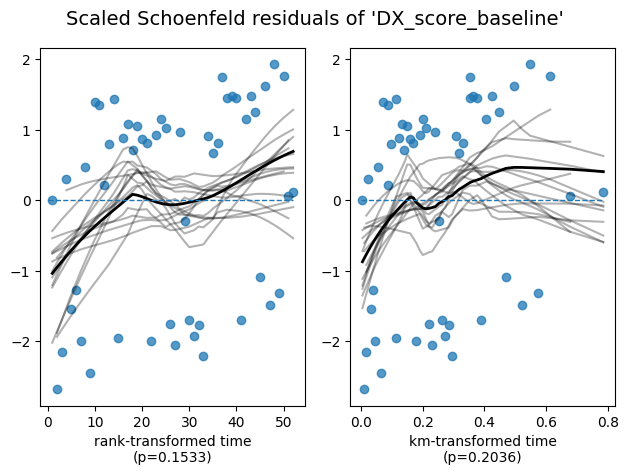

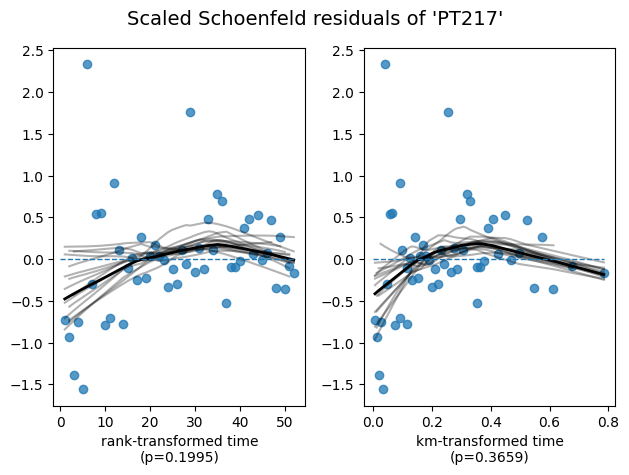

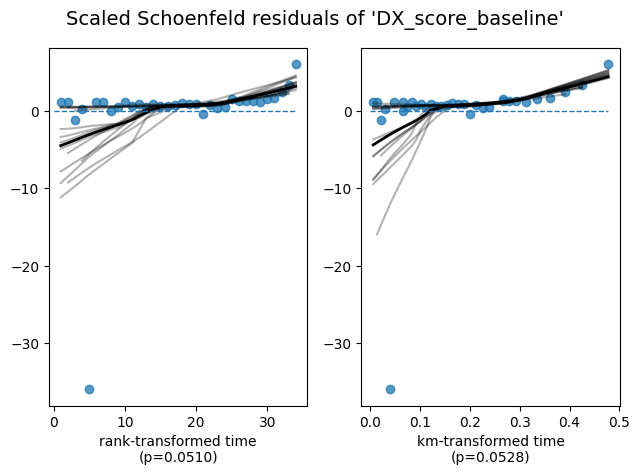

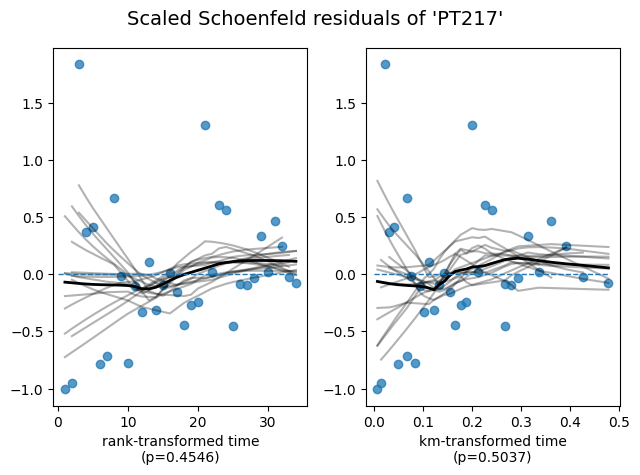

In [ ]:
#Proportional hazards assumption check
cox_A.check_assumptions(cox_A_df, p_value_threshold=0.05, show_plots=True)
cox_B.check_assumptions(cox_B_df, p_value_threshold=0.05, show_plots=True)

In [ ]:
#Cox risk groups and KM plots
def add_risk_groups_from_cox(surv_df: pd.DataFrame, covars: list[str], n_groups: int = 3):
    d = surv_df[["time_years", "event"] + covars].dropna().copy()

    cph = CoxPHFitter()
    cph.fit(d, duration_col="time_years", event_col="event")

    d["risk_score"] = cph.predict_partial_hazard(d[covars]).values.flatten()
    d["risk_rank"] = d["risk_score"].rank(method="average")

    q = min(n_groups, d["risk_rank"].nunique())
    labels = ["Low", "Mid", "High"][:q]
    d["risk_group"] = pd.qcut(d["risk_rank"], q=q, labels=labels)

    return cph, d

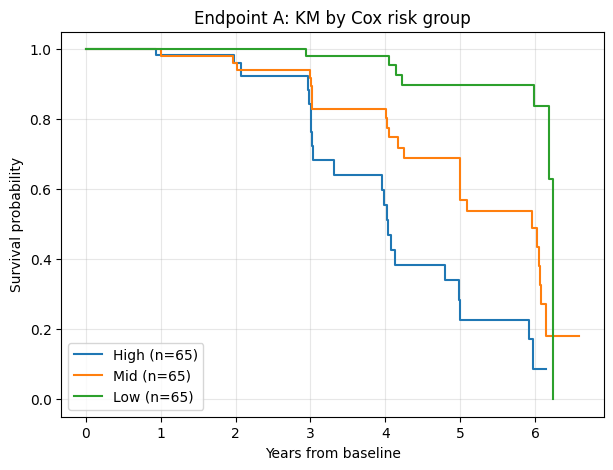

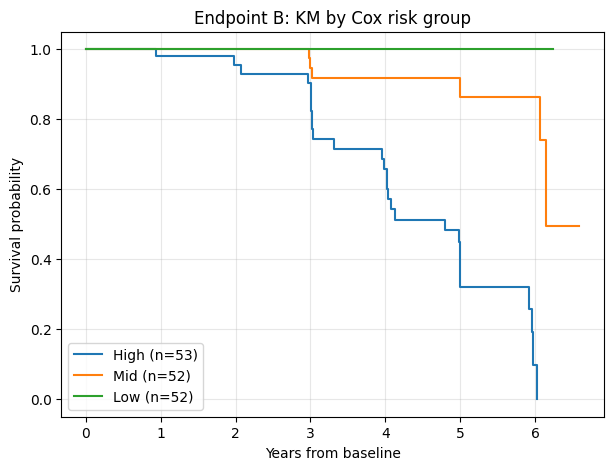

In [ ]:
cox_rg_A, cox_groups_A = add_risk_groups_from_cox(surv_worsen_z, best_covars_A)
cox_rg_B, cox_groups_B = add_risk_groups_from_cox(surv_ad_z, best_covars_B)

plot_km_by_group(cox_groups_A, "Endpoint A: KM by Cox risk group", "risk_group")
plot_km_by_group(cox_groups_B, "Endpoint B: KM by Cox risk group", "risk_group")

## 18. Random Survival Forest Modelling

This section applies Random Survival Forests (RSF), a machine learning approach to time-to-event modelling. RSF is useful because it can capture non-linear relationships and interactions without requiring proportional hazards assumptions. This makes it a useful complement to the Cox model.

In [ ]:
#Random Survival Forest
#Structured survival object
def make_y(df_in: pd.DataFrame):
    return Surv.from_arrays(
        event=df_in["event"].astype(bool).values,
        time=df_in["time_years"].astype(float).values
    )

In [ ]:
#Fit RSF
def fit_rsf(X_train, y_train,
            n_estimators=500,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42):
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        n_jobs=-1,
        random_state=random_state
    )
    rsf.fit(X_train, y_train)
    return rsf

In [ ]:
#Cross-validated RSF comparison
def rsf_cv_metrics(surv_df: pd.DataFrame, covars: list[str], n_splits: int = 5):
    d = surv_df[["RID", "time_years", "event"] + covars].dropna().copy()
    groups = d["RID"].values
    gkf = GroupKFold(n_splits=n_splits)

    cidxs = []

    for train_idx, test_idx in gkf.split(d, groups=groups):
        train = d.iloc[train_idx].copy()
        test = d.iloc[test_idx].copy()

        X_train = train[covars]
        y_train = make_y(train)
        X_test = test[covars]
        y_test = make_y(test)

        rsf = fit_rsf(X_train, y_train)
        risk_scores = rsf.predict(X_test)

        cidx = concordance_index_censored(y_test["event"], y_test["time"], risk_scores)[0]
        cidxs.append(cidx)

    return np.mean(cidxs), np.std(cidxs)

In [ ]:
def compare_rsf_models(surv_df: pd.DataFrame, endpoint_name: str, model_sets: dict):
    rows = []
    for name, covars in model_sets.items():
        mean_c, sd_c = rsf_cv_metrics(surv_df, covars)
        rows.append({
            "endpoint": endpoint_name,
            "model": name,
            "mean_cv_cindex": mean_c,
            "sd_cv_cindex": sd_c
        })
    return pd.DataFrame(rows).sort_values("mean_cv_cindex", ascending=False)

rsf_table_A = compare_rsf_models(surv_worsen_z, "Endpoint A", model_sets)
rsf_table_B = compare_rsf_models(surv_ad_z, "Endpoint B", model_sets)

print("RSF results - Endpoint A")
display(rsf_table_A)

print("RSF results - Endpoint B")
display(rsf_table_B)

RSF results - Endpoint A


,endpoint,model,mean_cv_cindex,sd_cv_cindex
3,Endpoint A,DX + PT217 + GFAP,0.810171,0.049859
2,Endpoint A,DX + PT217 + NFL,0.795881,0.067845
4,Endpoint A,DX + all biomarkers,0.795351,0.081424
1,Endpoint A,DX + PT217,0.795345,0.066636
0,Endpoint A,DX only,0.683867,0.060228


RSF results - Endpoint B


,endpoint,model,mean_cv_cindex,sd_cv_cindex
4,Endpoint B,DX + all biomarkers,0.901169,0.030005
2,Endpoint B,DX + PT217 + NFL,0.881860,0.028771
3,Endpoint B,DX + PT217 + GFAP,0.878142,0.041700
1,Endpoint B,DX + PT217,0.872544,0.021518
0,Endpoint B,DX only,0.806735,0.057714


In [ ]:
#Direct Cox vs RSF comparison table
comparison_A = cox_table_A.merge(
    rsf_table_A,
    on=["endpoint", "model"],
    suffixes=("_cox", "_rsf")
)

comparison_B = cox_table_B.merge(
    rsf_table_B,
    on=["endpoint", "model"],
    suffixes=("_cox", "_rsf")
)

print("Model comparison - Endpoint A")
display(comparison_A)

print("Model comparison - Endpoint B")
display(comparison_B)

Model comparison - Endpoint A


,endpoint,model,mean_cv_cindex_cox,sd_cv_cindex_cox,mean_cv_cindex_rsf,sd_cv_cindex_rsf
0,Endpoint A,DX + PT217,0.775863,0.102997,0.795345,0.066636
1,Endpoint A,DX + PT217 + GFAP,0.770565,0.110440,0.810171,0.049859
2,Endpoint A,DX + all biomarkers,0.766643,0.097144,0.795351,0.081424
3,Endpoint A,DX + PT217 + NFL,0.765520,0.105599,0.795881,0.067845
4,Endpoint A,DX only,0.633780,0.076685,0.683867,0.060228


Model comparison - Endpoint B


,endpoint,model,mean_cv_cindex_cox,sd_cv_cindex_cox,mean_cv_cindex_rsf,sd_cv_cindex_rsf
0,Endpoint B,DX + PT217,0.892374,0.041256,0.872544,0.021518
1,Endpoint B,DX + PT217 + NFL,0.892119,0.037489,0.881860,0.028771
2,Endpoint B,DX + all biomarkers,0.875741,0.036898,0.901169,0.030005
3,Endpoint B,DX + PT217 + GFAP,0.875454,0.034924,0.878142,0.041700
4,Endpoint B,DX only,0.806735,0.057714,0.806735,0.057714


In [ ]:
#Fit final RSF models
rsf_A_df = surv_worsen_z[["RID", "time_years", "event"] + best_covars_A].dropna().copy()
rsf_B_df = surv_ad_z[["RID", "time_years", "event"] + best_covars_B].dropna().copy()

rsf_A = fit_rsf(rsf_A_df[best_covars_A], make_y(rsf_A_df))
rsf_B = fit_rsf(rsf_B_df[best_covars_B], make_y(rsf_B_df))

## 19. Random Survival Forest Feature Importance

This section evaluates which predictors contribute most strongly to the RSF model. Feature importance helps identify the biomarkers and clinical variables that are most informative for predicting progression risk, complementing the hazard ratio interpretation from the Cox model.

In [ ]:
#RSF feature importance
def permutation_importance_survival(rsf, X, y_struct, n_repeats=20, random_state=42):
    def score_fn(estimator, X_perm, y_perm):
        risk = estimator.predict(X_perm)
        return concordance_index_censored(y_perm["event"], y_perm["time"], risk)[0]

    result = permutation_importance(
        rsf,
        X,
        y_struct,
        scoring=score_fn,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_sd": result.importances_std
    }).sort_values("importance_mean", ascending=False)

    return out

,feature,importance_mean,importance_sd
1,PT217,0.306542,0.050295
0,DX_score_baseline,0.104915,0.027680


,feature,importance_mean,importance_sd
1,PT217,0.212844,0.028893
0,DX_score_baseline,0.062118,0.021653


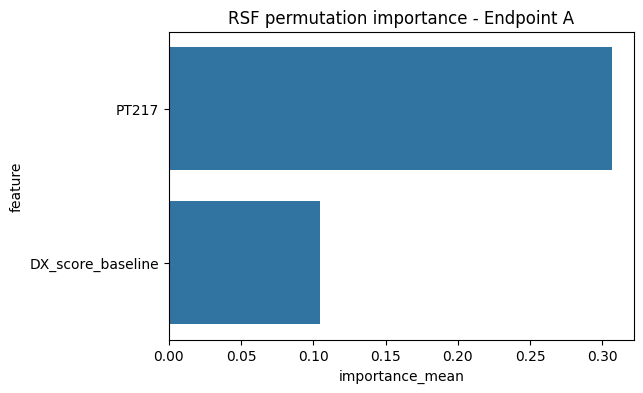

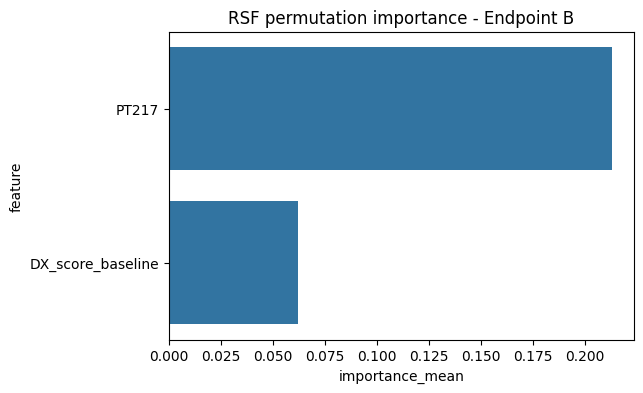

In [ ]:
imp_A = permutation_importance_survival(rsf_A, rsf_A_df[best_covars_A], make_y(rsf_A_df))
imp_B = permutation_importance_survival(rsf_B, rsf_B_df[best_covars_B], make_y(rsf_B_df))

display(imp_A)
display(imp_B)

plt.figure(figsize=(6, 4))
sns.barplot(data=imp_A, x="importance_mean", y="feature")
plt.title("RSF permutation importance - Endpoint A")
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=imp_B, x="importance_mean", y="feature")
plt.title("RSF permutation importance - Endpoint B")
plt.show()

In [ ]:
#RSF risk groups and KM plots
def add_rsf_risk_groups(surv_df, covars, n_groups=3):
    d = surv_df[["time_years", "event"] + covars].dropna().copy()
    rsf = fit_rsf(d[covars], make_y(d))
    d["risk_score"] = rsf.predict(d[covars])
    d["risk_rank"] = d["risk_score"].rank(method="average")
    labels = ["Low", "Mid", "High"][:n_groups]
    d["risk_group"] = pd.qcut(d["risk_rank"], q=n_groups, labels=labels)
    return d, rsf

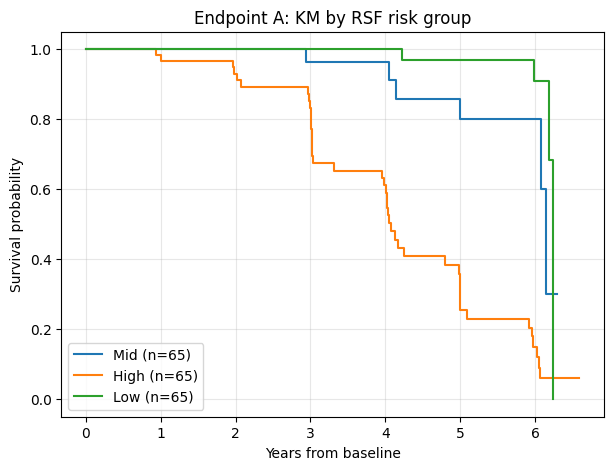

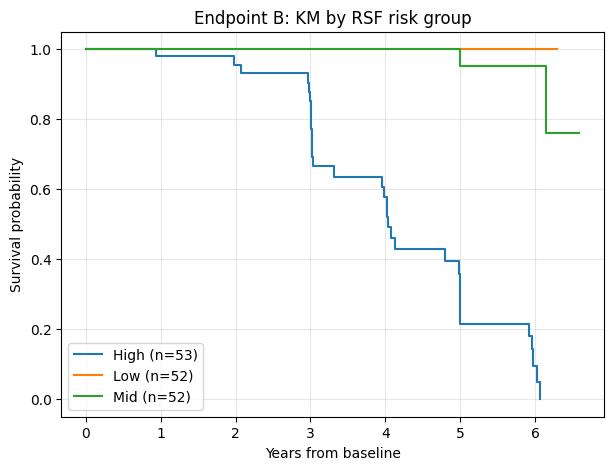

In [ ]:
risk_A, rsf_A_fit = add_rsf_risk_groups(surv_worsen_z, best_covars_A, n_groups=3)
risk_B, rsf_B_fit = add_rsf_risk_groups(surv_ad_z, best_covars_B, n_groups=3)

plot_km_by_group(risk_A, "Endpoint A: KM by RSF risk group", "risk_group")
plot_km_by_group(risk_B, "Endpoint B: KM by RSF risk group", "risk_group")

In [ ]:
#Manual partial dependence plots for RSF
def rsf_partial_dependence(rsf, X, feature, n_points=30):
    X_temp = X.copy()
    grid = np.linspace(X[feature].quantile(0.05), X[feature].quantile(0.95), n_points)

    mean_risk = []
    for val in grid:
        X_temp[feature] = val
        preds = rsf.predict(X_temp)
        mean_risk.append(np.mean(preds))

    return pd.DataFrame({feature: grid, "mean_predicted_risk": mean_risk})

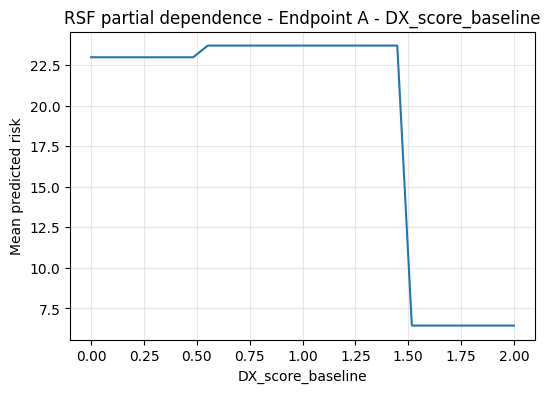

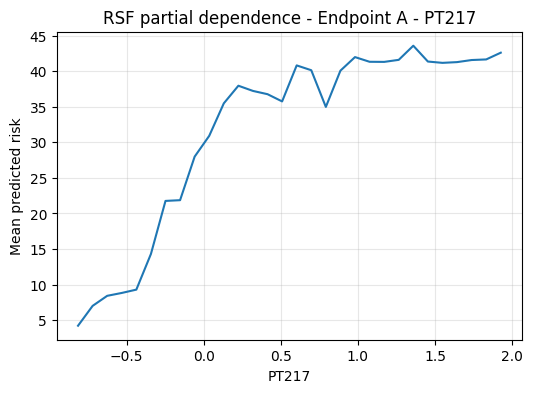

In [ ]:
for feat in best_covars_A:
    pdp = rsf_partial_dependence(rsf_A, rsf_A_df[best_covars_A], feat)
    plt.figure(figsize=(6, 4))
    plt.plot(pdp[feat], pdp["mean_predicted_risk"])
    plt.title(f"RSF partial dependence - Endpoint A - {feat}")
    plt.xlabel(feat)
    plt.ylabel("Mean predicted risk")
    plt.grid(alpha=0.3)
    plt.show()

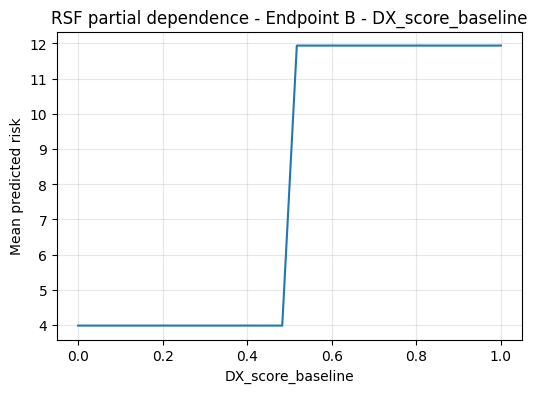

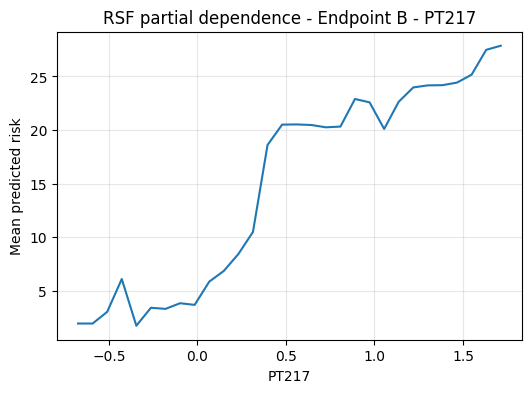

In [ ]:
for feat in best_covars_B:
    pdp = rsf_partial_dependence(rsf_B, rsf_B_df[best_covars_B], feat)
    plt.figure(figsize=(6, 4))
    plt.plot(pdp[feat], pdp["mean_predicted_risk"])
    plt.title(f"RSF partial dependence - Endpoint B - {feat}")
    plt.xlabel(feat)
    plt.ylabel("Mean predicted risk")
    plt.grid(alpha=0.3)
    plt.show()

## Calibration Assessment

Calibration is evaluated by comparing predicted and observed risks. This assesses how well model predictions align with actual outcomes.

,group,n,mean_predicted,observed
0,G1,39,0.000000,0.000000
1,G2,39,0.005382,0.000000
2,G3,39,0.021874,0.000000
3,G4,39,0.066018,0.000000
4,G5,39,0.255126,0.321399


,group,n,mean_predicted,observed
0,G1,32,0.000000,0.000000
1,G2,31,0.000020,0.000000
2,G3,31,0.003670,0.000000
3,G4,31,0.039663,0.000000
4,G5,32,0.219261,0.240476


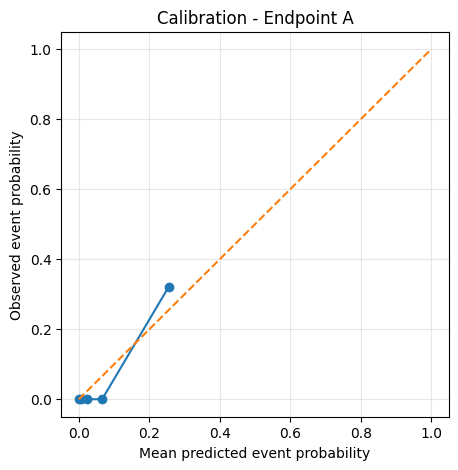

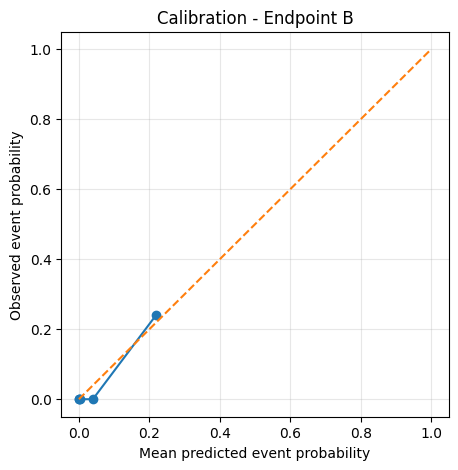

In [ ]:
def calibration_table_rsf(surv_df, covars, t0=3.0, n_groups=5):
    d = surv_df[["time_years", "event"] + covars].dropna().copy()

    X = d[covars]
    y = make_y(d)

    rsf = fit_rsf(X, y)
    surv_fns = rsf.predict_survival_function(X, return_array=False)
    d["pred_event_prob_t0"] = [1.0 - fn(t0) for fn in surv_fns]

    # Use ranks to avoid duplicate bin-edge problems from tied predictions
    ranks = d["pred_event_prob_t0"].rank(method="first")
    n_actual_groups = min(n_groups, ranks.nunique())

    d["risk_group"] = pd.qcut(
        ranks,
        q=n_actual_groups,
        labels=[f"G{i+1}" for i in range(n_actual_groups)]
    )

    kmf = KaplanMeierFitter()
    rows = []

    for g in d["risk_group"].cat.categories:
        sub = d[d["risk_group"] == g]
        kmf.fit(sub["time_years"], sub["event"])
        obs = 1.0 - float(kmf.survival_function_at_times(t0).iloc[0])
        pred = sub["pred_event_prob_t0"].mean()
        rows.append((g, len(sub), pred, obs))

    return pd.DataFrame(rows, columns=["group", "n", "mean_predicted", "observed"])


cal_A = calibration_table_rsf(surv_worsen_z, best_covars_A, t0=3.0, n_groups=5)
cal_B = calibration_table_rsf(surv_ad_z, best_covars_B, t0=3.0, n_groups=5)

display(cal_A)
display(cal_B)

for cal_df, title in [(cal_A, "Calibration - Endpoint A"), (cal_B, "Calibration - Endpoint B")]:
    plt.figure(figsize=(5, 5))
    plt.plot(cal_df["mean_predicted"], cal_df["observed"], marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted event probability")
    plt.ylabel("Observed event probability")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

## Subgroup Analyses

This section evaluates model performance and biomarker effects across subgroups such as sex and APOE4 status. This helps assess whether predictive relationships differ between participant groups.

In [ ]:
#Subgroup analysis
# Baseline diagnosis subgroups
surv_worsen_cn = surv_worsen_z[surv_worsen_z["DX_score_baseline"] == 0].copy()
surv_worsen_mci = surv_worsen_z[surv_worsen_z["DX_score_baseline"] == 1].copy()
surv_worsen_ad = surv_worsen_z[surv_worsen_z["DX_score_baseline"] == 2].copy()

surv_ad_cn = surv_ad_z[surv_ad_z["DX_score_baseline"] == 0].copy()
surv_ad_mci = surv_ad_z[surv_ad_z["DX_score_baseline"] == 1].copy()

In [ ]:
#Sex-based subgroup analysis
gender_df = df.groupby("RID").first()[["Gender"]].reset_index()
surv_worsen_z = surv_worsen_z.merge(gender_df, on="RID", how="left")
surv_ad_z = surv_ad_z.merge(gender_df, on="RID", how="left")

surv_worsen_male = surv_worsen_z[surv_worsen_z["Gender"] == "Male"].copy()
surv_worsen_female = surv_worsen_z[surv_worsen_z["Gender"] == "Female"].copy()

surv_ad_male = surv_ad_z[surv_ad_z["Gender"] == "Male"].copy()
surv_ad_female = surv_ad_z[surv_ad_z["Gender"] == "Female"].copy()

In [ ]:
#APOE subgroup analysis
apoe4_df = df.groupby("RID").first()[["APOE4"]].reset_index()
surv_worsen_z = surv_worsen_z.merge(apoe4_df, on="RID", how="left")
surv_ad_z = surv_ad_z.merge(apoe4_df, on="RID", how="left")

surv_worsen_apoe_pos = surv_worsen_z[surv_worsen_z["APOE4"] == 1].copy()
surv_worsen_apoe_neg = surv_worsen_z[surv_worsen_z["APOE4"] == 0].copy()

surv_ad_apoe_pos = surv_ad_z[surv_ad_z["APOE4"] == 1].copy()
surv_ad_apoe_neg = surv_ad_z[surv_ad_z["APOE4"] == 0].copy()

In [ ]:
#Generic subgroup summary helper
def subgroup_summary(name, d):
    print(f"{name}:")
    print(f"  n = {len(d)}")
    print(f"  events = {int(d['event'].sum())}")
    if len(d) > 0:
        print(f"  median follow-up = {d['time_years'].median():.2f} years")
    print("-" * 40)

subgroup_summary("Endpoint A - CN", surv_worsen_cn)
subgroup_summary("Endpoint A - MCI", surv_worsen_mci)
subgroup_summary("Endpoint B - CN", surv_ad_cn)
subgroup_summary("Endpoint B - MCI", surv_ad_mci)

Endpoint A - CN:
  n = 85
  events = 19
  median follow-up = 4.22 years
----------------------------------------
Endpoint A - MCI:
  n = 72
  events = 33
  median follow-up = 3.06 years
----------------------------------------
Endpoint B - CN:
  n = 85
  events = 1
  median follow-up = 4.25 years
----------------------------------------
Endpoint B - MCI:
  n = 72
  events = 33
  median follow-up = 3.06 years
----------------------------------------


In [ ]:
#Sensitivity analysis
def remove_outliers_iqr(df_in, cols):
    d = df_in.copy()
    for c in cols:
        if c in d.columns:
            q1 = d[c].quantile(0.25)
            q3 = d[c].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            d = d[(d[c].isna()) | ((d[c] >= lower) & (d[c] <= upper))]
    return d

surv_worsen_no_out = remove_outliers_iqr(surv_worsen_z, biomarkers)
surv_ad_no_out = remove_outliers_iqr(surv_ad_z, biomarkers)

print("Original Endpoint A:", surv_worsen_z.shape)
print("No-outlier Endpoint A:", surv_worsen_no_out.shape)

Original Endpoint A: (195, 13)
No-outlier Endpoint A: (161, 13)


In [ ]:
cox_sens_A = compare_cox_models(surv_worsen_no_out, "Endpoint A - no outliers", model_sets)
rsf_sens_A = compare_rsf_models(surv_worsen_no_out, "Endpoint A - no outliers", model_sets)

display(cox_sens_A)
display(rsf_sens_A)

,endpoint,model,mean_cv_cindex,sd_cv_cindex
1,Endpoint A - no outliers,DX + PT217,0.768077,0.102990
2,Endpoint A - no outliers,DX + PT217 + NFL,0.761474,0.112086
4,Endpoint A - no outliers,DX + all biomarkers,0.759356,0.084004
3,Endpoint A - no outliers,DX + PT217 + GFAP,0.753156,0.104402
0,Endpoint A - no outliers,DX only,0.589208,0.089101


,endpoint,model,mean_cv_cindex,sd_cv_cindex
1,Endpoint A - no outliers,DX + PT217,0.779349,0.087821
3,Endpoint A - no outliers,DX + PT217 + GFAP,0.768917,0.083533
2,Endpoint A - no outliers,DX + PT217 + NFL,0.763535,0.074246
4,Endpoint A - no outliers,DX + all biomarkers,0.753162,0.081067
0,Endpoint A - no outliers,DX only,0.621266,0.093416


In [ ]:
summary_table = comparison_A.copy()
summary_table["best_model"] = np.where(
    summary_table["mean_cv_cindex_rsf"] > summary_table["mean_cv_cindex_cox"],
    "RSF",
    "Cox"
)

display(summary_table)

,endpoint,model,mean_cv_cindex_cox,sd_cv_cindex_cox,mean_cv_cindex_rsf,sd_cv_cindex_rsf,best_model
0,Endpoint A,DX + PT217,0.775863,0.102997,0.795345,0.066636,RSF
1,Endpoint A,DX + PT217 + GFAP,0.770565,0.110440,0.810171,0.049859,RSF
2,Endpoint A,DX + all biomarkers,0.766643,0.097144,0.795351,0.081424,RSF
3,Endpoint A,DX + PT217 + NFL,0.765520,0.105599,0.795881,0.067845,RSF
4,Endpoint A,DX only,0.633780,0.076685,0.683867,0.060228,RSF


In [ ]:
def subgroup_summary(name, d):
    print(f"{name}:")
    print(f"  n = {len(d)}")
    print(f"  events = {int(d['event'].sum())}")
    if len(d) > 0:
        print(f"  median follow-up = {d['time_years'].median():.2f} years")
    print("-" * 40)

subgroup_summary("Endpoint A - CN", surv_worsen_cn)
subgroup_summary("Endpoint A - MCI", surv_worsen_mci)
subgroup_summary("Endpoint A - Male", surv_worsen_male)
subgroup_summary("Endpoint A - Female", surv_worsen_female)
subgroup_summary("Endpoint A - APOE4+", surv_worsen_apoe_pos)
subgroup_summary("Endpoint A - APOE4-", surv_worsen_apoe_neg)

Endpoint A - CN:
  n = 85
  events = 19
  median follow-up = 4.22 years
----------------------------------------
Endpoint A - MCI:
  n = 72
  events = 33
  median follow-up = 3.06 years
----------------------------------------
Endpoint A - Male:
  n = 110
  events = 37
  median follow-up = 3.06 years
----------------------------------------
Endpoint A - Female:
  n = 85
  events = 15
  median follow-up = 3.02 years
----------------------------------------
Endpoint A - APOE4+:
  n = 52
  events = 18
  median follow-up = 4.09 years
----------------------------------------
Endpoint A - APOE4-:
  n = 70
  events = 24
  median follow-up = 4.23 years
----------------------------------------


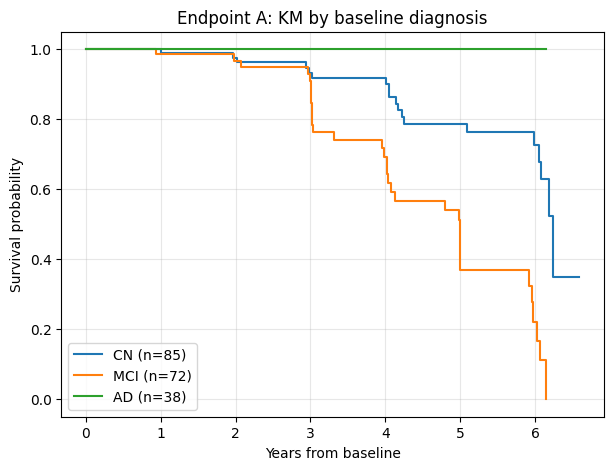

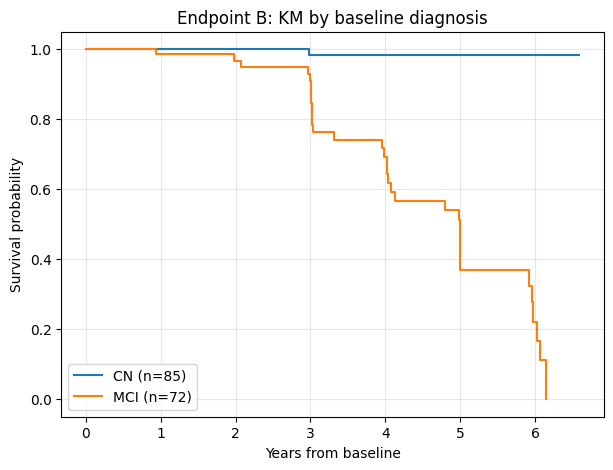

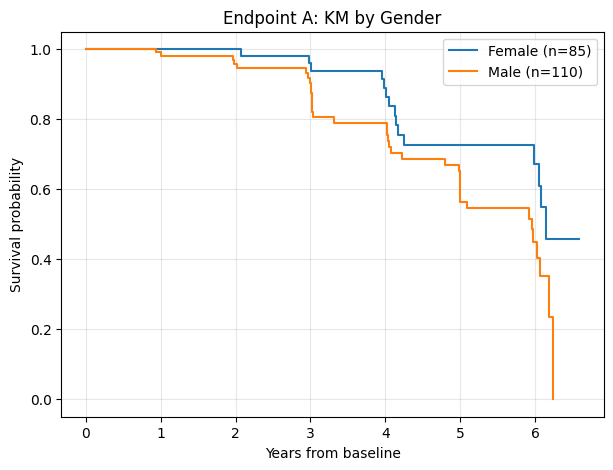

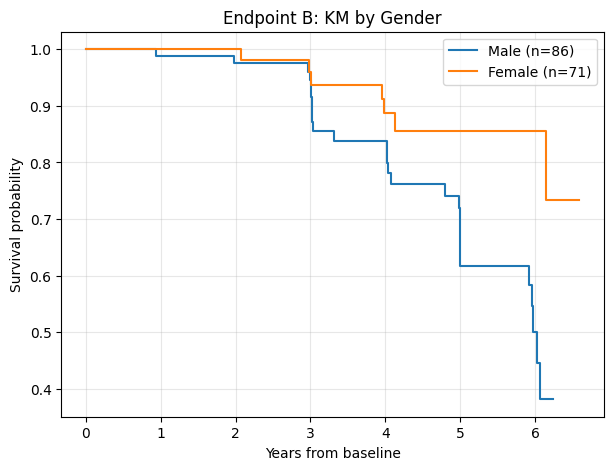

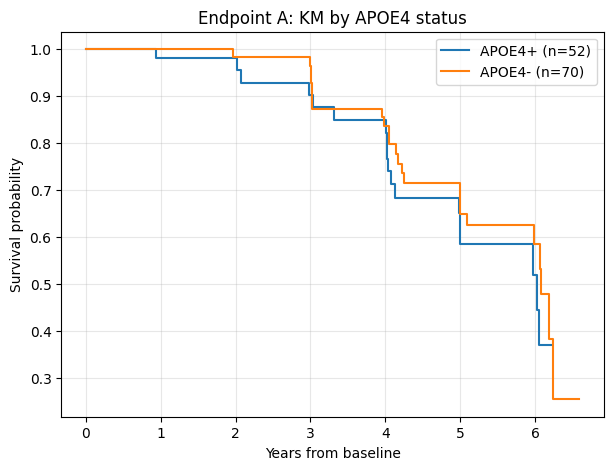

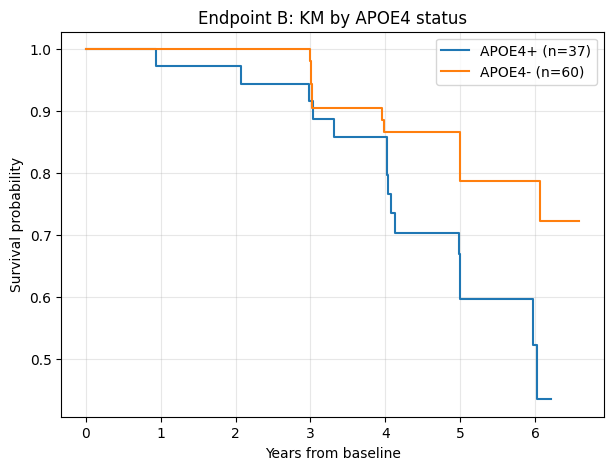

In [ ]:
# By baseline diagnosis
plot_km_by_group(surv_worsen_z, "Endpoint A: KM by baseline diagnosis", "DX_baseline_label")
plot_km_by_group(surv_ad_z, "Endpoint B: KM by baseline diagnosis", "DX_baseline_label")

# By Gender
plot_km_by_group(surv_worsen_z, "Endpoint A: KM by Gender", "Gender")
plot_km_by_group(surv_ad_z, "Endpoint B: KM by Gender", "Gender")

# By APOE4
surv_worsen_z["APOE4_label"] = surv_worsen_z["APOE4"].map({0: "APOE4-", 1: "APOE4+"})
surv_ad_z["APOE4_label"] = surv_ad_z["APOE4"].map({0: "APOE4-", 1: "APOE4+"})

plot_km_by_group(surv_worsen_z, "Endpoint A: KM by APOE4 status", "APOE4_label")
plot_km_by_group(surv_ad_z, "Endpoint B: KM by APOE4 status", "APOE4_label")

In [ ]:
from lifelines import CoxPHFitter

def fit_cox(surv_df, covars, penalizer=0.1):
    d = surv_df[["time_years", "event"] + covars].dropna().copy()

    # Drop constant columns
    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[["time_years", "event"] + valid_covars].copy()

    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(d, duration_col="time_years", event_col="event")
    return cph, d, valid_covars

In [ ]:
#Endpoint A - CN only
cn_covars_A = [c for c in best_covars_A if c != "DX_score_baseline"]

if len(surv_worsen_cn) > 20 and surv_worsen_cn["event"].sum() > 5:
    cox_cn_A, cox_cn_A_df, used_covars = fit_cox(
        surv_worsen_cn,
        cn_covars_A,
        penalizer=0.1
    )
    print("Used covariates:", used_covars)
    display(cox_cn_A.summary)

Used covariates: ['PT217']


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
PT217,2.292271,9.897391,0.565423,1.184062,3.40048,3.267622,29.978486,0.0,4.054082,0.00005,14.278176


In [ ]:
#Endpoint A — MCI only
mci_covars_A = [c for c in best_covars_A if c != "DX_score_baseline"]

if len(surv_worsen_mci) > 20 and surv_worsen_mci["event"].sum() > 5:
    cox_mci_A, cox_mci_A_df, used_covars = fit_cox(
        surv_worsen_mci,
        mci_covars_A,
        penalizer=0.1
    )
    print("Used covariates:", used_covars)
    display(cox_mci_A.summary)

Used covariates: ['PT217']


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
PT217,0.51065,1.666374,0.13249,0.250974,0.770326,1.285276,2.160471,0.0,3.854243,0.000116,13.072492


In [ ]:
#Endpoint A — AD only
ad_covars_A = [c for c in best_covars_A if c != "DX_score_baseline"]

if len(surv_worsen_ad) > 20 and surv_worsen_ad["event"].sum() > 5:
    cox_ad_A, cox_ad_A_df, used_covars = fit_cox(
        surv_worsen_ad,
        ad_covars_A,
        penalizer=0.1
    )
    print("Used covariates:", used_covars)
    display(cox_ad_A.summary)

In [ ]:
#Endpoint B — CN only
cn_covars_B = [c for c in best_covars_B if c != "DX_score_baseline"]

if len(surv_ad_cn) > 20 and surv_ad_cn["event"].sum() > 5:
    cox_cn_B, cox_cn_B_df, used_covars = fit_cox(
        surv_ad_cn,
        cn_covars_B,
        penalizer=0.1
    )
    print("Used covariates:", used_covars)
    display(cox_cn_B.summary)

In [ ]:
#Endpoint B — MCI only
mci_covars_B = [c for c in best_covars_B if c != "DX_score_baseline"]

if len(surv_ad_mci) > 20 and surv_ad_mci["event"].sum() > 5:
    cox_mci_B, cox_mci_B_df, used_covars = fit_cox(
        surv_ad_mci,
        mci_covars_B,
        penalizer=0.1
    )
    print("Used covariates:", used_covars)
    display(cox_mci_B.summary)

Used covariates: ['PT217']


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
PT217,0.474682,1.607502,0.123158,0.233296,0.716067,1.262755,2.046369,0.0,3.854243,0.000116,13.072492


In [ ]:
#Endpoint A - Male only
if len(surv_worsen_male) > 20 and surv_worsen_male["event"].sum() > 5:
    cox_male_A, cox_male_A_df, used_covars = fit_cox(
        surv_worsen_male,
        best_covars_A,
        penalizer=0.1
    )
    print("Used covariates:", used_covars)
    display(cox_male_A.summary)

Used covariates: ['DX_score_baseline', 'PT217']


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
DX_score_baseline,0.177766,1.194545,0.245977,-0.30434,0.659871,0.737610,1.934544,0.0,0.722693,0.469868,1.089671
PT217,0.661453,1.937605,0.202117,0.26531,1.057596,1.303835,2.879439,0.0,3.272617,0.001066,9.874161


In [ ]:
#Endpoint A - Female only
if len(surv_worsen_female) > 20 and surv_worsen_female["event"].sum() > 5:
    cox_female_A, cox_female_A_df, used_covars = fit_cox(
        surv_worsen_female,
        best_covars_A,
        penalizer=0.1
    )
    print("Used covariates:", used_covars)
    display(cox_female_A.summary)

Used covariates: ['DX_score_baseline', 'PT217']


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
DX_score_baseline,0.029694,1.030139,0.346261,-0.648965,0.708352,0.522586,2.030643,0.0,0.085755,0.931661,0.102123
PT217,0.628019,1.873894,0.172095,0.290718,0.965320,1.337387,2.625627,0.0,3.649246,0.000263,11.892591


In [ ]:
#Endpoint B - Male only
if len(surv_ad_male) > 20 and surv_ad_male["event"].sum() > 5:
    cox_male_B, cox_male_B_df, used_covars = fit_cox(
        surv_ad_male,
        best_covars_B,
        penalizer=0.1
    )
    print("Used covariates:", used_covars)
    display(cox_male_B.summary)

Used covariates: ['DX_score_baseline', 'PT217']


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
DX_score_baseline,1.726086,5.618622,0.455987,0.832369,2.619804,2.298758,13.733030,0.0,3.785388,0.000153,12.669764
PT217,0.640141,1.896749,0.222033,0.204965,1.075318,1.227482,2.930925,0.0,2.883092,0.003938,7.988348


In [ ]:
#Endpoint B - Female only
if len(surv_ad_female) > 20 and surv_ad_female["event"].sum() > 5:
    cox_female_B, cox_female_B_df, used_covars = fit_cox(
        surv_ad_female,
        best_covars_B,
        penalizer=0.1
    )
    print("Used covariates:", used_covars)
    display(cox_female_B.summary)

Used covariates: ['DX_score_baseline', 'PT217']


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
DX_score_baseline,0.974145,2.648901,0.596141,-0.194269,2.142559,0.823436,8.521215,0.0,1.634085,0.102241,3.289956
PT217,0.546193,1.726668,0.179901,0.193593,0.898794,1.213602,2.456638,0.0,3.036069,0.002397,8.704647


In [ ]:
#Endpoint A - APOE4 Positive
if len(surv_worsen_apoe_pos) > 20 and surv_worsen_apoe_pos["event"].sum() > 5:
    cox_apoe_pos_A, cox_apoe_pos_A_df, used_covars = fit_cox(
        surv_worsen_apoe_pos,
        best_covars_A,
        penalizer=0.1
    )
    print("Used covariates:", used_covars)
    display(cox_apoe_pos_A.summary)

Used covariates: ['DX_score_baseline', 'PT217']


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
DX_score_baseline,0.074212,1.077035,0.327389,-0.567459,0.715882,0.566964,2.045991,0.0,0.226677,0.820675,0.285118
PT217,0.538361,1.713197,0.145721,0.252754,0.823968,1.287566,2.279527,0.0,3.694475,0.000220,12.147971


In [ ]:
#Endpoint A — APOE4 negative
if len(surv_worsen_apoe_neg) > 20 and surv_worsen_apoe_neg["event"].sum() > 5:
    cox_apoe_neg_A, cox_apoe_neg_A_df, used_covars = fit_cox(
        surv_worsen_apoe_neg,
        best_covars_A,
        penalizer=0.1
    )
    print("Used covariates:", used_covars)
    display(cox_apoe_neg_A.summary)

Used covariates: ['DX_score_baseline', 'PT217']


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
DX_score_baseline,0.440022,1.552741,0.317919,-0.183087,1.063131,0.832695,2.895421,0.0,1.384070,0.166337,2.587819
PT217,1.016473,2.763430,0.391051,0.250027,1.782918,1.284061,5.947185,0.0,2.599337,0.009340,6.742300


## Participant-Level Biomarker Slopes

This section derives participant-specific biomarker slopes from longitudinal measurements. These slopes capture rates of change over time and are used to evaluate whether dynamic biomarker information improves prediction.

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

def compute_subject_slopes(df_long, biomarker_cols, id_col="RID", time_col="time_years", min_points=2):
    rows = []

    for rid, sub in df_long.groupby(id_col):
        row = {id_col: rid}

        for col in biomarker_cols:
            temp = sub[[time_col, col]].dropna().copy()

            if len(temp) >= min_points and temp[time_col].nunique() > 1:
                X = temp[[time_col]].values
                y = temp[col].values
                model = LinearRegression().fit(X, y)
                row[f"{col}_slope"] = model.coef_[0]
                row[f"{col}_baseline"] = temp.sort_values(time_col)[col].iloc[0]
            else:
                row[f"{col}_slope"] = np.nan
                row[f"{col}_baseline"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
biomarker_cols = ["PT217", "FQ_GFAP", "FQ_NFL", "FQ_AB42_AB40", "FQ_pT217_AB42"]

slope_df = compute_subject_slopes(df, biomarker_cols)
display(slope_df.head())
print(slope_df.shape)

,RID,PT217_slope,PT217_baseline,FQ_GFAP_slope,FQ_GFAP_baseline,FQ_NFL_slope,FQ_NFL_baseline,FQ_AB42_AB40_slope,FQ_AB42_AB40_baseline,FQ_pT217_AB42_slope,FQ_pT217_AB42_baseline
0,10,0.057274,0.472,13.564993,194.3,1.858906,26.5,-0.002775,0.073581,0.005310,0.019313
1,93,0.091313,1.021,111.071926,364.4,6.885861,48.6,-0.000654,0.069682,0.007412,0.040758
2,108,0.214233,0.606,34.718819,257.3,5.920261,33.4,0.001819,0.083884,0.009227,0.022739
3,149,0.028403,0.290,48.832879,335.3,-1.096248,44.0,0.006174,0.070762,-0.000354,0.013615
4,183,-0.011414,1.444,37.467901,413.1,6.749185,40.7,0.004636,0.070731,-0.003157,0.065399


(195, 11)


In [ ]:
surv_worsen_slopes = surv_worsen_z.merge(slope_df, on="RID", how="left")
surv_ad_slopes = surv_ad_z.merge(slope_df, on="RID", how="left")

print(surv_worsen_slopes.shape)
print(surv_ad_slopes.shape)

(195, 24)
(157, 24)


In [ ]:
def zscore_columns(df_in, cols):
    out = df_in.copy()
    for c in cols:
        if c in out.columns:
            mu = out[c].mean()
            sd = out[c].std()
            if pd.notna(sd) and sd != 0:
                out[c] = (out[c] - mu) / sd
    return out

slope_cols = [f"{c}_slope" for c in biomarker_cols]
baseline_cols = [f"{c}_baseline" for c in biomarker_cols]

surv_worsen_slopes = zscore_columns(surv_worsen_slopes, slope_cols + baseline_cols)
surv_ad_slopes = zscore_columns(surv_ad_slopes, slope_cols + baseline_cols)

## Models Incorporating Biomarker Slopes

This section compares models using baseline biomarkers and biomarker slopes. The aim is to assess whether incorporating longitudinal change improves predictive performance.

In [ ]:
model_sets_slopes_A = {
    "DX only": ["DX_score_baseline"],
    "DX + PT217 baseline": ["DX_score_baseline", "PT217_baseline"],
    "DX + PT217 slope": ["DX_score_baseline", "PT217_slope"],
    "DX + PT217 baseline + slope": ["DX_score_baseline", "PT217_baseline", "PT217_slope"],
    "DX + GFAP baseline + slope": ["DX_score_baseline", "FQ_GFAP_baseline", "FQ_GFAP_slope"],
    "DX + NFL baseline + slope": ["DX_score_baseline", "FQ_NFL_baseline", "FQ_NFL_slope"],
    "DX + all baseline biomarkers": ["DX_score_baseline"] + baseline_cols,
    "DX + all baseline biomarkers + slopes": ["DX_score_baseline"] + baseline_cols + slope_cols
}

model_sets_slopes_B = model_sets_slopes_A.copy()

In [ ]:
from lifelines import CoxPHFitter

def fit_cox_safe(surv_df, covars, penalizer=0.1):
    d = surv_df[["time_years", "event"] + covars].dropna().copy()

    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[["time_years", "event"] + valid_covars].copy()

    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(d, duration_col="time_years", event_col="event")
    return cph, d, valid_covars

In [ ]:
from sklearn.model_selection import GroupKFold
from lifelines.utils import concordance_index

def cox_cv_cindex(surv_df, covars, n_splits=5, penalizer=0.1):
    d = surv_df[["RID", "time_years", "event"] + covars].dropna().copy()

    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[["RID", "time_years", "event"] + valid_covars].copy()

    n_unique = d["RID"].nunique()
    n_splits = min(n_splits, n_unique)
    if n_splits < 2:
        return np.nan, np.nan

    groups = d["RID"].values
    gkf = GroupKFold(n_splits=n_splits)

    scores = []

    for train_idx, test_idx in gkf.split(d, groups=groups):
        train = d.iloc[train_idx].copy()
        test = d.iloc[test_idx].copy()

        train_covars = [c for c in valid_covars if train[c].nunique() > 1]
        if len(train_covars) == 0:
            continue

        cph = CoxPHFitter(penalizer=penalizer)
        cph.fit(train[["time_years", "event"] + train_covars], duration_col="time_years", event_col="event")

        risk_scores = cph.predict_partial_hazard(test[train_covars])
        cidx = concordance_index(
            test["time_years"],
            -risk_scores.values.flatten(),
            test["event"]
        )
        scores.append(cidx)

    if len(scores) == 0:
        return np.nan, np.nan

    return np.mean(scores), np.std(scores)

In [ ]:
def compare_cox_models(surv_df, endpoint_name, model_sets):
    rows = []
    for name, covars in model_sets.items():
        mean_c, sd_c = cox_cv_cindex(surv_df, covars)
        rows.append({
            "endpoint": endpoint_name,
            "model": name,
            "mean_cv_cindex": mean_c,
            "sd_cv_cindex": sd_c
        })
    return pd.DataFrame(rows).sort_values("mean_cv_cindex", ascending=False)

In [ ]:
cox_slopes_A = compare_cox_models(surv_worsen_slopes, "Endpoint A", model_sets_slopes_A)
cox_slopes_B = compare_cox_models(surv_ad_slopes, "Endpoint B", model_sets_slopes_B)

display(cox_slopes_A)
display(cox_slopes_B)

,endpoint,model,mean_cv_cindex,sd_cv_cindex
7,Endpoint A,DX + all baseline biomarkers + slopes,0.800784,0.066053
3,Endpoint A,DX + PT217 baseline + slope,0.788566,0.042542
6,Endpoint A,DX + all baseline biomarkers,0.786754,0.053661
1,Endpoint A,DX + PT217 baseline,0.782554,0.034450
4,Endpoint A,DX + GFAP baseline + slope,0.728459,0.137622
5,Endpoint A,DX + NFL baseline + slope,0.727833,0.067767
2,Endpoint A,DX + PT217 slope,0.714620,0.064335
0,Endpoint A,DX only,0.633780,0.076685


,endpoint,model,mean_cv_cindex,sd_cv_cindex
3,Endpoint B,DX + PT217 baseline + slope,0.908134,0.030343
1,Endpoint B,DX + PT217 baseline,0.906674,0.032648
6,Endpoint B,DX + all baseline biomarkers,0.901358,0.036387
7,Endpoint B,DX + all baseline biomarkers + slopes,0.897879,0.029001
4,Endpoint B,DX + GFAP baseline + slope,0.880490,0.028453
2,Endpoint B,DX + PT217 slope,0.871804,0.034044
5,Endpoint B,DX + NFL baseline + slope,0.849861,0.039154
0,Endpoint B,DX only,0.806735,0.057714


In [ ]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

def make_y(df_in):
    return Surv.from_arrays(
        event=df_in["event"].astype(bool).values,
        time=df_in["time_years"].astype(float).values
    )

def fit_rsf(X_train, y_train,
            n_estimators=500,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42):
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        n_jobs=-1,
        random_state=random_state
    )
    rsf.fit(X_train, y_train)
    return rsf

In [ ]:
def rsf_cv_metrics(surv_df, covars, n_splits=5):
    d = surv_df[["RID", "time_years", "event"] + covars].dropna().copy()
    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[["RID", "time_years", "event"] + valid_covars].copy()

    n_unique = d["RID"].nunique()
    n_splits = min(n_splits, n_unique)
    if n_splits < 2:
        return np.nan, np.nan

    groups = d["RID"].values
    gkf = GroupKFold(n_splits=n_splits)

    cidxs = []

    for train_idx, test_idx in gkf.split(d, groups=groups):
        train = d.iloc[train_idx].copy()
        test = d.iloc[test_idx].copy()

        X_train = train[valid_covars]
        y_train = make_y(train)
        X_test = test[valid_covars]
        y_test = make_y(test)

        rsf = fit_rsf(X_train, y_train)
        risk_scores = rsf.predict(X_test)

        cidx = concordance_index_censored(y_test["event"], y_test["time"], risk_scores)[0]
        cidxs.append(cidx)

    if len(cidxs) == 0:
        return np.nan, np.nan

    return np.mean(cidxs), np.std(cidxs)

In [ ]:
def compare_rsf_models(surv_df, endpoint_name, model_sets):
    rows = []
    for name, covars in model_sets.items():
        mean_c, sd_c = rsf_cv_metrics(surv_df, covars)
        rows.append({
            "endpoint": endpoint_name,
            "model": name,
            "mean_cv_cindex": mean_c,
            "sd_cv_cindex": sd_c
        })
    return pd.DataFrame(rows).sort_values("mean_cv_cindex", ascending=False)

In [ ]:
rsf_slopes_A = compare_rsf_models(surv_worsen_slopes, "Endpoint A", model_sets_slopes_A)
rsf_slopes_B = compare_rsf_models(surv_ad_slopes, "Endpoint B", model_sets_slopes_B)

display(rsf_slopes_A)
display(rsf_slopes_B)

,endpoint,model,mean_cv_cindex,sd_cv_cindex
7,Endpoint A,DX + all baseline biomarkers + slopes,0.822250,0.058995
3,Endpoint A,DX + PT217 baseline + slope,0.791270,0.051548
6,Endpoint A,DX + all baseline biomarkers,0.787592,0.055381
1,Endpoint A,DX + PT217 baseline,0.769243,0.014474
4,Endpoint A,DX + GFAP baseline + slope,0.761062,0.092021
2,Endpoint A,DX + PT217 slope,0.752060,0.089452
5,Endpoint A,DX + NFL baseline + slope,0.726683,0.052391
0,Endpoint A,DX only,0.683867,0.060228


,endpoint,model,mean_cv_cindex,sd_cv_cindex
7,Endpoint B,DX + all baseline biomarkers + slopes,0.906067,0.031627
6,Endpoint B,DX + all baseline biomarkers,0.895236,0.030820
3,Endpoint B,DX + PT217 baseline + slope,0.882779,0.035540
1,Endpoint B,DX + PT217 baseline,0.867087,0.041712
2,Endpoint B,DX + PT217 slope,0.850016,0.045681
4,Endpoint B,DX + GFAP baseline + slope,0.836718,0.054756
5,Endpoint B,DX + NFL baseline + slope,0.826430,0.069091
0,Endpoint B,DX only,0.806735,0.057714


## 20. Comparison of Cox and Random Survival Forest Models

This section directly compares the performance of Cox and RSF models using measures such as the concordance index. The purpose is to assess whether more flexible machine learning models offer an advantage over traditional survival models for this dataset and research question.

In [ ]:
comparison_slopes_A = cox_slopes_A.merge(
    rsf_slopes_A,
    on=["endpoint", "model"],
    suffixes=("_cox", "_rsf")
)

comparison_slopes_B = cox_slopes_B.merge(
    rsf_slopes_B,
    on=["endpoint", "model"],
    suffixes=("_cox", "_rsf")
)

display(comparison_slopes_A)
display(comparison_slopes_B)

,endpoint,model,mean_cv_cindex_cox,sd_cv_cindex_cox,mean_cv_cindex_rsf,sd_cv_cindex_rsf
0,Endpoint A,DX + all baseline biomarkers + slopes,0.800784,0.066053,0.822250,0.058995
1,Endpoint A,DX + PT217 baseline + slope,0.788566,0.042542,0.791270,0.051548
2,Endpoint A,DX + all baseline biomarkers,0.786754,0.053661,0.787592,0.055381
3,Endpoint A,DX + PT217 baseline,0.782554,0.034450,0.769243,0.014474
4,Endpoint A,DX + GFAP baseline + slope,0.728459,0.137622,0.761062,0.092021
5,Endpoint A,DX + NFL baseline + slope,0.727833,0.067767,0.726683,0.052391
6,Endpoint A,DX + PT217 slope,0.714620,0.064335,0.752060,0.089452
7,Endpoint A,DX only,0.633780,0.076685,0.683867,0.060228


,endpoint,model,mean_cv_cindex_cox,sd_cv_cindex_cox,mean_cv_cindex_rsf,sd_cv_cindex_rsf
0,Endpoint B,DX + PT217 baseline + slope,0.908134,0.030343,0.882779,0.035540
1,Endpoint B,DX + PT217 baseline,0.906674,0.032648,0.867087,0.041712
2,Endpoint B,DX + all baseline biomarkers,0.901358,0.036387,0.895236,0.030820
3,Endpoint B,DX + all baseline biomarkers + slopes,0.897879,0.029001,0.906067,0.031627
4,Endpoint B,DX + GFAP baseline + slope,0.880490,0.028453,0.836718,0.054756
5,Endpoint B,DX + PT217 slope,0.871804,0.034044,0.850016,0.045681
6,Endpoint B,DX + NFL baseline + slope,0.849861,0.039154,0.826430,0.069091
7,Endpoint B,DX only,0.806735,0.057714,0.806735,0.057714


In [ ]:
def bootstrap_cindex_difference(surv_df, covars, n_boot=200, penalizer=0.1):
    d = surv_df[["time_years", "event"] + covars].dropna().copy()
    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[["time_years", "event"] + valid_covars].copy()

    diffs = []

    for _ in range(n_boot):
        boot = d.sample(len(d), replace=True)

        # Cox
        try:
            cph = CoxPHFitter(penalizer=penalizer)
            cph.fit(boot, duration_col="time_years", event_col="event")
            cox_risk = cph.predict_partial_hazard(boot[valid_covars]).values.flatten()
            cox_c = concordance_index(boot["time_years"], -cox_risk, boot["event"])
        except:
            continue

        # RSF
        try:
            rsf = fit_rsf(boot[valid_covars], make_y(boot))
            rsf_risk = rsf.predict(boot[valid_covars])
            rsf_c = concordance_index_censored(
                boot["event"].astype(bool),
                boot["time_years"],
                rsf_risk
            )[0]
        except:
            continue

        diffs.append(rsf_c - cox_c)

    if len(diffs) == 0:
        return None

    return {
        "mean_diff": np.mean(diffs),
        "lower_95": np.percentile(diffs, 2.5),
        "upper_95": np.percentile(diffs, 97.5),
        "n_successful_bootstraps": len(diffs)
    }

In [ ]:
bootstrap_diff_A = bootstrap_cindex_difference(
    surv_worsen_slopes,
    ["DX_score_baseline", "PT217_baseline", "PT217_slope"],
    n_boot=200
)
print(bootstrap_diff_A)

bootstrap_diff_B = bootstrap_cindex_difference(
    surv_ad_slopes,
    ["DX_score_baseline", "PT217_baseline", "PT217_slope"],
    n_boot=200
)
print(bootstrap_diff_B)

{'mean_diff': np.float64(0.12465543760253317), 'lower_95': np.float64(0.072945992714874), 'upper_95': np.float64(0.18043498226359472), 'n_successful_bootstraps': 200}
{'mean_diff': np.float64(0.054398902983060264), 'lower_95': np.float64(0.020382908445935596), 'upper_95': np.float64(0.09583864871762059), 'n_successful_bootstraps': 200}


In [ ]:
#Integrated Brier Score (IBS)
from sksurv.metrics import integrated_brier_score

In [ ]:
#Cox Survival functions
def cox_survival_predictions(train_df, test_df, covars, penalizer=0.1):
    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(train_df[["time_years", "event"] + covars], duration_col="time_years", event_col="event")

    surv_fns = cph.predict_survival_function(test_df[covars])
    return surv_fns

In [ ]:
#RSF Survival functions
def rsf_survival_predictions(train_df, test_df, covars):
    rsf = fit_rsf(train_df[covars], make_y(train_df))
    surv_fns = rsf.predict_survival_function(test_df[covars], return_array=False)
    return surv_fns

## Integrated Brier Score

The integrated Brier score (IBS) is used to assess overall prediction error across time. Lower IBS values indicate more accurate prediction of survival probabilities.

In [ ]:
#IBS comparison function
def compare_ibs(surv_df, covars, n_splits=5, penalizer=0.1):
    d = surv_df[["RID", "time_years", "event"] + covars].dropna().copy()
    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[["RID", "time_years", "event"] + valid_covars].copy()

    n_unique = d["RID"].nunique()
    n_splits = min(n_splits, n_unique)
    if n_splits < 2:
        return {"cox_ibs_mean": np.nan, "rsf_ibs_mean": np.nan}

    groups = d["RID"].values
    gkf = GroupKFold(n_splits=n_splits)

    cox_scores = []
    rsf_scores = []

    for train_idx, test_idx in gkf.split(d, groups=groups):
        train = d.iloc[train_idx].copy()
        test = d.iloc[test_idx].copy()

        # Need enough events
        if train["event"].sum() < 5 or test["event"].sum() < 2:
            continue

        y_train = make_y(train)
        y_test = make_y(test)

        # Safe time range for IBS:
        # must be within [min_test_time, max_test_time)
        t_min = test["time_years"].min()
        t_max = test["time_years"].max()

        if t_max <= t_min:
            continue

        # Use slightly inside the interval to avoid boundary errors
        eps = 1e-6
        lower = t_min + eps
        upper = t_max - eps

        if upper <= lower:
            continue

        times = np.linspace(lower, upper, 30)

        # -------------------
        # Cox
        # -------------------
        try:
            cox_surv = cox_survival_predictions(train, test, valid_covars, penalizer=penalizer)

            # Reindex onto desired times and interpolate
            cox_surv_interp = (
                cox_surv.reindex(cox_surv.index.union(times))
                .sort_index()
                .interpolate(method="index")
                .loc[times]
            )

            cox_preds = cox_surv_interp.T.values
            cox_ibs = integrated_brier_score(y_train, y_test, cox_preds, times)
            cox_scores.append(cox_ibs)

        except Exception as e:
            print("Cox IBS failed:", repr(e))

        # -------------------
        # RSF
        # -------------------
        try:
            rsf_surv = rsf_survival_predictions(train, test, valid_covars)

            rsf_preds = np.asarray([[fn(t) for t in times] for fn in rsf_surv])
            rsf_ibs = integrated_brier_score(y_train, y_test, rsf_preds, times)
            rsf_scores.append(rsf_ibs)

        except Exception as e:
            print("RSF IBS failed:", repr(e))

    return {
        "cox_ibs_mean": np.mean(cox_scores) if cox_scores else np.nan,
        "rsf_ibs_mean": np.mean(rsf_scores) if rsf_scores else np.nan
    }

In [ ]:
ibs_A = compare_ibs(
    surv_worsen_slopes,
    ["DX_score_baseline", "PT217_baseline", "PT217_slope"]
)
print("Endpoint A IBS:", ibs_A)

ibs_B = compare_ibs(
    surv_ad_slopes,
    ["DX_score_baseline", "PT217_baseline", "PT217_slope"]
)
print("Endpoint B IBS:", ibs_B)

Cox IBS failed: ValueError('Input estimate contains NaN.')
RSF IBS failed: ValueError('x must be within [0.000000; 6.225873]')
Endpoint A IBS: {'cox_ibs_mean': np.float64(0.1132944515378668), 'rsf_ibs_mean': np.float64(0.10579450673254864)}
RSF IBS failed: ValueError('x must be within [0.000000; 6.297057]')
Cox IBS failed: ValueError('Input estimate contains NaN.')
Endpoint B IBS: {'cox_ibs_mean': np.float64(0.071018540109511), 'rsf_ibs_mean': np.float64(0.07240726065459765)}


In [ ]:
from sksurv.metrics import integrated_brier_score
import numpy as np

def cox_survival_predictions(train_df, test_df, covars, penalizer=0.1):
    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(train_df[["time_years", "event"] + covars], duration_col="time_years", event_col="event")
    surv_fns = cph.predict_survival_function(test_df[covars])
    return surv_fns

def rsf_survival_predictions(train_df, test_df, covars):
    rsf = fit_rsf(train_df[covars], make_y(train_df))
    surv_fns = rsf.predict_survival_function(test_df[covars], return_array=False)
    return surv_fns

def compare_ibs(surv_df, covars, n_splits=5, penalizer=0.1):
    d = surv_df[["RID", "time_years", "event"] + covars].dropna().copy()
    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[["RID", "time_years", "event"] + valid_covars].copy()

    n_unique = d["RID"].nunique()
    n_splits = min(n_splits, n_unique)
    if n_splits < 2:
        return {"cox_ibs_mean": np.nan, "rsf_ibs_mean": np.nan}

    groups = d["RID"].values
    gkf = GroupKFold(n_splits=n_splits)

    cox_scores = []
    rsf_scores = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(d, groups=groups), start=1):
        train = d.iloc[train_idx].copy()
        test = d.iloc[test_idx].copy()

        # Skip weak folds
        if train["event"].sum() < 5 or test["event"].sum() < 2:
            print(f"Skipping fold {fold}: too few events")
            continue

        y_train = make_y(train)
        y_test = make_y(test)

        # More conservative time range to avoid edge issues
        lower = np.percentile(test["time_years"], 15)
        upper = np.percentile(test["time_years"], 85)

        if not np.isfinite(lower) or not np.isfinite(upper) or upper <= lower:
            print(f"Skipping fold {fold}: invalid time range")
            continue

        times = np.linspace(lower, upper, 20)

        # -------------------
        # Cox IBS
        # -------------------
        try:
            cox_surv = cox_survival_predictions(train, test, valid_covars, penalizer=penalizer)

            # Interpolate onto requested times
            cox_surv_interp = (
                cox_surv.reindex(cox_surv.index.union(times))
                .sort_index()
                .interpolate(method="index")
                .ffill()
                .bfill()
                .loc[times]
            )

            cox_preds = cox_surv_interp.T.values

            # Skip if still unstable
            if np.isnan(cox_preds).any():
                raise ValueError("Input estimate contains NaN.")

            cox_ibs = integrated_brier_score(y_train, y_test, cox_preds, times)
            cox_scores.append(cox_ibs)

        except Exception as e:
            print(f"Cox IBS failed in fold {fold}: {repr(e)}")

        # -------------------
        # RSF IBS
        # -------------------
        try:
            rsf_surv = rsf_survival_predictions(train, test, valid_covars)

            rsf_preds = np.asarray([[fn(t) for t in times] for fn in rsf_surv])

            if np.isnan(rsf_preds).any():
                raise ValueError("RSF predictions contain NaN.")

            rsf_ibs = integrated_brier_score(y_train, y_test, rsf_preds, times)
            rsf_scores.append(rsf_ibs)

        except Exception as e:
            print(f"RSF IBS failed in fold {fold}: {repr(e)}")

    return {
        "cox_ibs_mean": np.mean(cox_scores) if cox_scores else np.nan,
        "rsf_ibs_mean": np.mean(rsf_scores) if rsf_scores else np.nan,
        "cox_n_folds": len(cox_scores),
        "rsf_n_folds": len(rsf_scores)
    }

# Run for Endpoint A
ibs_A = compare_ibs(
    surv_worsen_slopes,
    ["DX_score_baseline", "PT217_baseline", "PT217_slope"]
)
print("Endpoint A IBS:", ibs_A)

# Run for Endpoint B
ibs_B = compare_ibs(
    surv_ad_slopes,
    ["DX_score_baseline", "PT217_baseline", "PT217_slope"]
)
print("Endpoint B IBS:", ibs_B)

Endpoint A IBS: {'cox_ibs_mean': np.float64(0.10727321601291118), 'rsf_ibs_mean': np.float64(0.102494994329935), 'cox_n_folds': 5, 'rsf_n_folds': 5}
Endpoint B IBS: {'cox_ibs_mean': np.float64(0.0892833114080582), 'rsf_ibs_mean': np.float64(0.08824331532322813), 'cox_n_folds': 5, 'rsf_n_folds': 5}


## Added Value of Biomarkers

Nested Cox models are compared using log-likelihood and AIC to evaluate whether biomarkers and their longitudinal changes provide additional predictive value beyond baseline diagnosis.

In [ ]:
# Endpoint A
cox_dx_A, cox_dx_A_df, _ = fit_cox_safe(
    surv_worsen_slopes,
    ["DX_score_baseline"]
)

cox_dx_pt_A, cox_dx_pt_A_df, _ = fit_cox_safe(
    surv_worsen_slopes,
    ["DX_score_baseline", "PT217_baseline"]
)

cox_dx_pt_slope_A, cox_dx_pt_slope_A_df, _ = fit_cox_safe(
    surv_worsen_slopes,
    ["DX_score_baseline", "PT217_baseline", "PT217_slope"]
)

print("Endpoint A")
print("Diagnosis only log-likelihood:", cox_dx_A.log_likelihood_)
print("Diagnosis + PT217 baseline log-likelihood:", cox_dx_pt_A.log_likelihood_)
print("Diagnosis + PT217 baseline + slope log-likelihood:", cox_dx_pt_slope_A.log_likelihood_)

print("Diagnosis only AIC:", cox_dx_A.AIC_partial_)
print("Diagnosis + PT217 baseline AIC:", cox_dx_pt_A.AIC_partial_)
print("Diagnosis + PT217 baseline + slope AIC:", cox_dx_pt_slope_A.AIC_partial_)


# Endpoint B
cox_dx_B, cox_dx_B_df, _ = fit_cox_safe(
    surv_ad_slopes,
    ["DX_score_baseline"]
)

cox_dx_pt_B, cox_dx_pt_B_df, _ = fit_cox_safe(
    surv_ad_slopes,
    ["DX_score_baseline", "PT217_baseline"]
)

cox_dx_pt_slope_B, cox_dx_pt_slope_B_df, _ = fit_cox_safe(
    surv_ad_slopes,
    ["DX_score_baseline", "PT217_baseline", "PT217_slope"]
)

print("\nEndpoint B")
print("Diagnosis only log-likelihood:", cox_dx_B.log_likelihood_)
print("Diagnosis + PT217 baseline log-likelihood:", cox_dx_pt_B.log_likelihood_)
print("Diagnosis + PT217 baseline + slope log-likelihood:", cox_dx_pt_slope_B.log_likelihood_)

print("Diagnosis only AIC:", cox_dx_B.AIC_partial_)
print("Diagnosis + PT217 baseline AIC:", cox_dx_pt_B.AIC_partial_)
print("Diagnosis + PT217 baseline + slope AIC:", cox_dx_pt_slope_B.AIC_partial_)

Endpoint A
Diagnosis only log-likelihood: -211.4329731080319
Diagnosis + PT217 baseline log-likelihood: -201.63254460468832
Diagnosis + PT217 baseline + slope log-likelihood: -216.79576296011402
Diagnosis only AIC: 424.8659462160638
Diagnosis + PT217 baseline AIC: 407.26508920937664
Diagnosis + PT217 baseline + slope AIC: 439.59152592022804

Endpoint B
Diagnosis only log-likelihood: -122.94502485863354
Diagnosis + PT217 baseline log-likelihood: -114.32925675879568
Diagnosis + PT217 baseline + slope log-likelihood: -114.30051093954957
Diagnosis only AIC: 247.8900497172671
Diagnosis + PT217 baseline AIC: 232.65851351759136
Diagnosis + PT217 baseline + slope AIC: 234.60102187909914


In [ ]:
cox_slopes_A.to_csv("cox_slopes_endpoint_A.csv", index=False)
cox_slopes_B.to_csv("cox_slopes_endpoint_B.csv", index=False)

rsf_slopes_A.to_csv("rsf_slopes_endpoint_A.csv", index=False)
rsf_slopes_B.to_csv("rsf_slopes_endpoint_B.csv", index=False)

comparison_slopes_A.to_csv("cox_vs_rsf_slopes_endpoint_A.csv", index=False)
comparison_slopes_B.to_csv("cox_vs_rsf_slopes_endpoint_B.csv", index=False)

pd.DataFrame([ibs_A]).to_csv("ibs_endpoint_A.csv", index=False)
pd.DataFrame([ibs_B]).to_csv("ibs_endpoint_B.csv", index=False)

In [ ]:
summary_rows = [
    {
        "endpoint": "A",
        "comparison": "Diagnosis only vs Diagnosis + PT217 baseline",
        "cox_cindex_model_1": cox_slopes_A.loc[
            cox_slopes_A["model"] == "DX only", "mean_cv_cindex"
        ].values[0],
        "cox_cindex_model_2": cox_slopes_A.loc[
            cox_slopes_A["model"] == "DX + PT217 baseline", "mean_cv_cindex"
        ].values[0],
        "rsf_cindex_model_1": rsf_slopes_A.loc[
            rsf_slopes_A["model"] == "DX only", "mean_cv_cindex"
        ].values[0],
        "rsf_cindex_model_2": rsf_slopes_A.loc[
            rsf_slopes_A["model"] == "DX + PT217 baseline", "mean_cv_cindex"
        ].values[0],
        "cox_ibs": ibs_A["cox_ibs_mean"],
        "rsf_ibs": ibs_A["rsf_ibs_mean"]
    },
    {
        "endpoint": "A",
        "comparison": "Diagnosis + PT217 baseline vs Diagnosis + PT217 baseline + slope",
        "cox_cindex_model_1": cox_slopes_A.loc[
            cox_slopes_A["model"] == "DX + PT217 baseline", "mean_cv_cindex"
        ].values[0],
        "cox_cindex_model_2": cox_slopes_A.loc[
            cox_slopes_A["model"] == "DX + PT217 baseline + slope", "mean_cv_cindex"
        ].values[0],
        "rsf_cindex_model_1": rsf_slopes_A.loc[
            rsf_slopes_A["model"] == "DX + PT217 baseline", "mean_cv_cindex"
        ].values[0],
        "rsf_cindex_model_2": rsf_slopes_A.loc[
            rsf_slopes_A["model"] == "DX + PT217 baseline + slope", "mean_cv_cindex"
        ].values[0],
        "cox_ibs": ibs_A["cox_ibs_mean"],
        "rsf_ibs": ibs_A["rsf_ibs_mean"]
    },
    {
        "endpoint": "B",
        "comparison": "Diagnosis only vs Diagnosis + PT217 baseline",
        "cox_cindex_model_1": cox_slopes_B.loc[
            cox_slopes_B["model"] == "DX only", "mean_cv_cindex"
        ].values[0],
        "cox_cindex_model_2": cox_slopes_B.loc[
            cox_slopes_B["model"] == "DX + PT217 baseline", "mean_cv_cindex"
        ].values[0],
        "rsf_cindex_model_1": rsf_slopes_B.loc[
            rsf_slopes_B["model"] == "DX only", "mean_cv_cindex"
        ].values[0],
        "rsf_cindex_model_2": rsf_slopes_B.loc[
            rsf_slopes_B["model"] == "DX + PT217 baseline", "mean_cv_cindex"
        ].values[0],
        "cox_ibs": ibs_B["cox_ibs_mean"],
        "rsf_ibs": ibs_B["rsf_ibs_mean"]
    },
    {
        "endpoint": "B",
        "comparison": "Diagnosis + PT217 baseline vs Diagnosis + PT217 baseline + slope",
        "cox_cindex_model_1": cox_slopes_B.loc[
            cox_slopes_B["model"] == "DX + PT217 baseline", "mean_cv_cindex"
        ].values[0],
        "cox_cindex_model_2": cox_slopes_B.loc[
            cox_slopes_B["model"] == "DX + PT217 baseline + slope", "mean_cv_cindex"
        ].values[0],
        "rsf_cindex_model_1": rsf_slopes_B.loc[
            rsf_slopes_B["model"] == "DX + PT217 baseline", "mean_cv_cindex"
        ].values[0],
        "rsf_cindex_model_2": rsf_slopes_B.loc[
            rsf_slopes_B["model"] == "DX + PT217 baseline + slope", "mean_cv_cindex"
        ].values[0],
        "cox_ibs": ibs_B["cox_ibs_mean"],
        "rsf_ibs": ibs_B["rsf_ibs_mean"]
    }
]

summary_table = pd.DataFrame(summary_rows)
display(summary_table)

summary_table.to_csv("summary_table_added_value.csv", index=False)

,endpoint,comparison,cox_cindex_model_1,cox_cindex_model_2,rsf_cindex_model_1,rsf_cindex_model_2,cox_ibs,rsf_ibs
0,A,Diagnosis only vs Diagnosis + PT217 baseline,0.633780,0.782554,0.683867,0.769243,0.107273,0.102495
1,A,Diagnosis + PT217 baseline vs Diagnosis + PT21...,0.782554,0.788566,0.769243,0.791270,0.107273,0.102495
2,B,Diagnosis only vs Diagnosis + PT217 baseline,0.806735,0.906674,0.806735,0.867087,0.089283,0.088243
3,B,Diagnosis + PT217 baseline vs Diagnosis + PT21...,0.906674,0.908134,0.867087,0.882779,0.089283,0.088243


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_comparison(df_comp, title):
    plot_df = df_comp.copy()

    plt.figure(figsize=(10, 5))
    x = np.arange(len(plot_df))
    width = 0.35

    plt.bar(x - width/2, plot_df["mean_cv_cindex_cox"], width, label="Cox")
    plt.bar(x + width/2, plot_df["mean_cv_cindex_rsf"], width, label="RSF")

    plt.xticks(x, plot_df["model"], rotation=45, ha="right")
    plt.ylabel("Mean cross-validated C-index")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

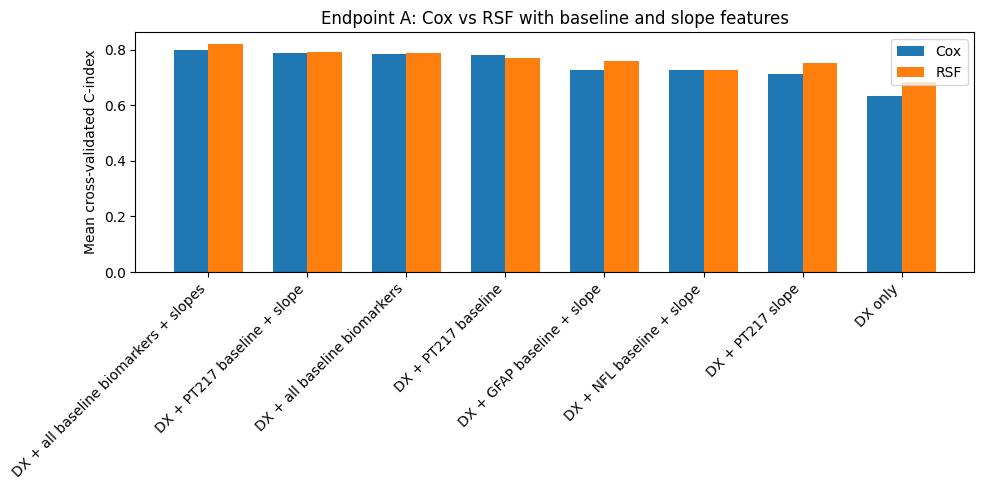

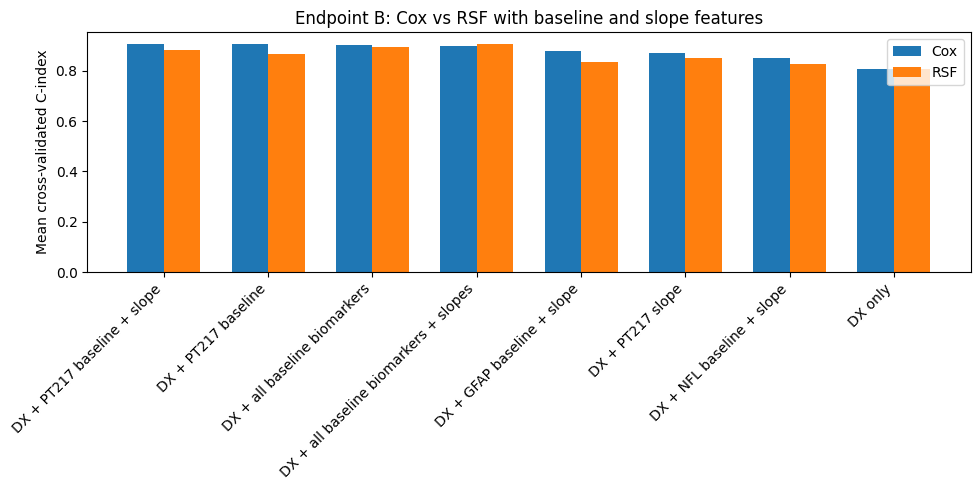

In [ ]:
plot_model_comparison(
    comparison_slopes_A,
    "Endpoint A: Cox vs RSF with baseline and slope features"
)

plot_model_comparison(
    comparison_slopes_B,
    "Endpoint B: Cox vs RSF with baseline and slope features"
)

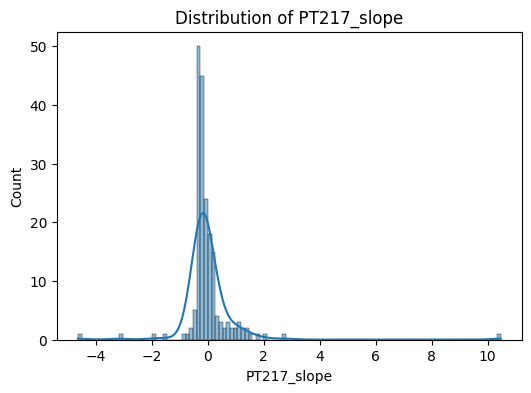

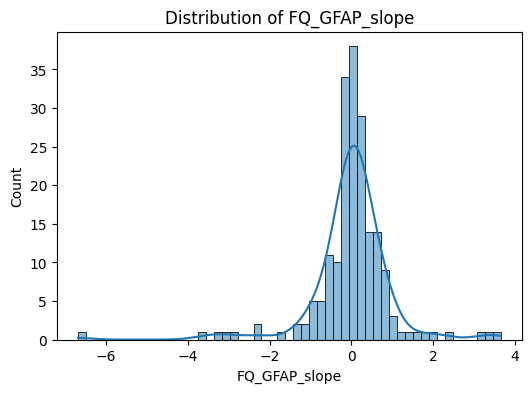

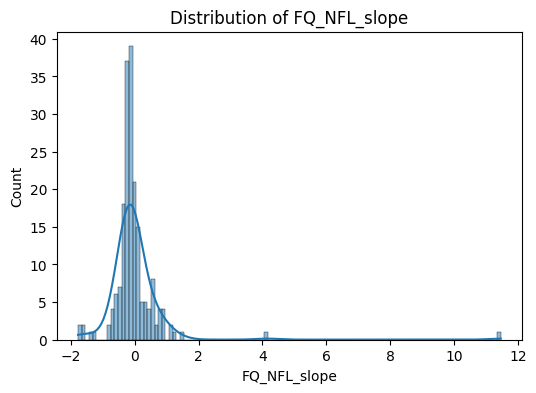

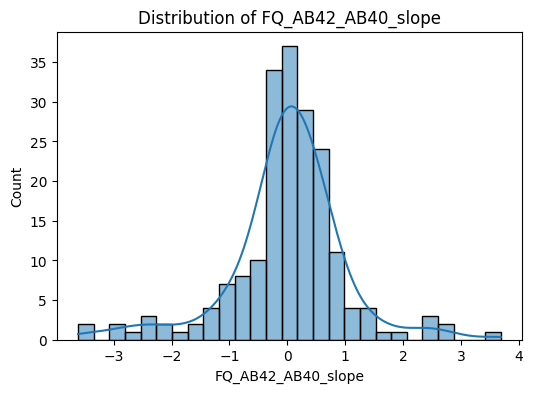

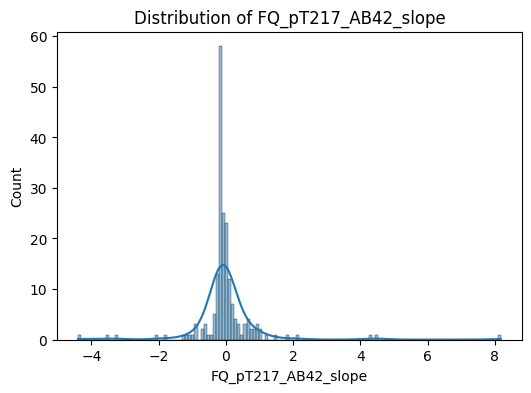

In [ ]:
import seaborn as sns

for col in slope_cols:
    if col in surv_worsen_slopes.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(surv_worsen_slopes[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

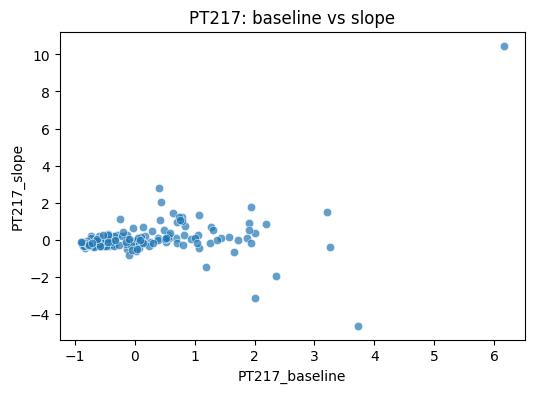

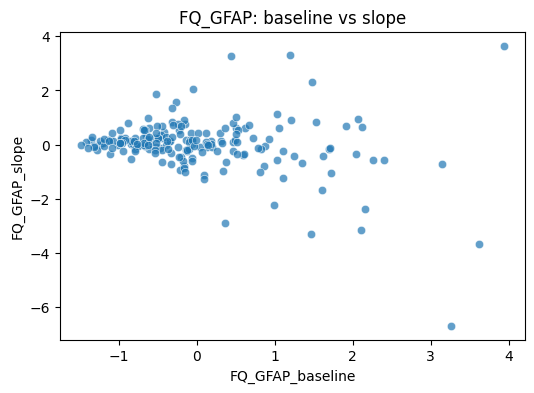

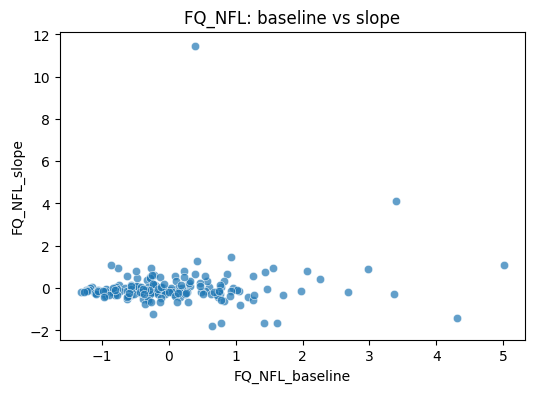

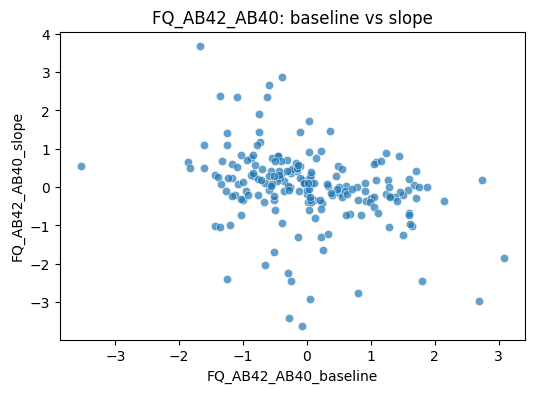

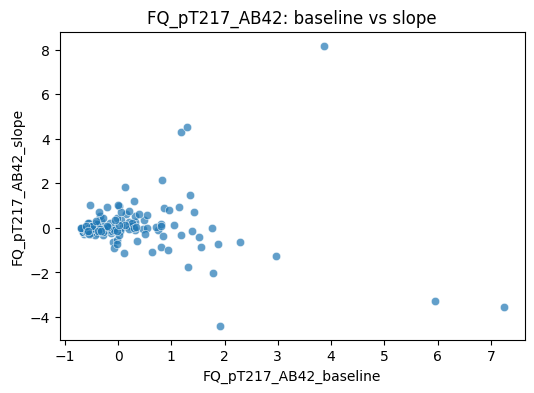

In [ ]:
for biomarker in biomarker_cols:
    baseline_col = f"{biomarker}_baseline"
    slope_col = f"{biomarker}_slope"

    if baseline_col in surv_worsen_slopes.columns and slope_col in surv_worsen_slopes.columns:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(
            data=surv_worsen_slopes,
            x=baseline_col,
            y=slope_col,
            alpha=0.7
        )
        plt.title(f"{biomarker}: baseline vs slope")
        plt.xlabel(baseline_col)
        plt.ylabel(slope_col)
        plt.show()

In [ ]:
for _, row in summary_table.iterrows():
    print(f"Endpoint {row['endpoint']} | {row['comparison']}")
    print(f"  Cox change in C-index: {row['cox_cindex_model_2'] - row['cox_cindex_model_1']:.4f}")
    print(f"  RSF change in C-index: {row['rsf_cindex_model_2'] - row['rsf_cindex_model_1']:.4f}")
    print(f"  Cox IBS: {row['cox_ibs']:.4f}")
    print(f"  RSF IBS: {row['rsf_ibs']:.4f}")
    print("-" * 50)

Endpoint A | Diagnosis only vs Diagnosis + PT217 baseline
  Cox change in C-index: 0.1488
  RSF change in C-index: 0.0854
  Cox IBS: 0.1073
  RSF IBS: 0.1025
--------------------------------------------------
Endpoint A | Diagnosis + PT217 baseline vs Diagnosis + PT217 baseline + slope
  Cox change in C-index: 0.0060
  RSF change in C-index: 0.0220
  Cox IBS: 0.1073
  RSF IBS: 0.1025
--------------------------------------------------
Endpoint B | Diagnosis only vs Diagnosis + PT217 baseline
  Cox change in C-index: 0.0999
  RSF change in C-index: 0.0604
  Cox IBS: 0.0893
  RSF IBS: 0.0882
--------------------------------------------------
Endpoint B | Diagnosis + PT217 baseline vs Diagnosis + PT217 baseline + slope
  Cox change in C-index: 0.0015
  RSF change in C-index: 0.0157
  Cox IBS: 0.0893
  RSF IBS: 0.0882
--------------------------------------------------


## Removing P-TAU217

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold

from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, integrated_brier_score

In [ ]:
def make_y(df_in):
    return Surv.from_arrays(
        event=df_in["event"].astype(bool).values,
        time=df_in["time_years"].astype(float).values
    )

In [ ]:
def fit_rsf(X_train, y_train,
            n_estimators=500,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42):
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        n_jobs=-1,
        random_state=random_state
    )
    rsf.fit(X_train, y_train)
    return rsf

In [ ]:
def fit_cox_safe(surv_df, covars, penalizer=0.1):
    d = surv_df[["time_years", "event"] + covars].dropna().copy()

    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[["time_years", "event"] + valid_covars].copy()

    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(d, duration_col="time_years", event_col="event")
    return cph, d, valid_covars

In [ ]:
def cox_cv_cindex(surv_df, covars, n_splits=5, penalizer=0.1):
    d = surv_df[["RID", "time_years", "event"] + covars].dropna().copy()

    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[["RID", "time_years", "event"] + valid_covars].copy()

    n_unique = d["RID"].nunique()
    n_splits = min(n_splits, n_unique)

    if n_splits < 2:
        return np.nan, np.nan

    groups = d["RID"].values
    gkf = GroupKFold(n_splits=n_splits)

    scores = []

    for train_idx, test_idx in gkf.split(d, groups=groups):
        train = d.iloc[train_idx].copy()
        test = d.iloc[test_idx].copy()

        train_covars = [c for c in valid_covars if train[c].nunique() > 1]
        if len(train_covars) == 0:
            continue

        cph = CoxPHFitter(penalizer=penalizer)
        cph.fit(
            train[["time_years", "event"] + train_covars],
            duration_col="time_years",
            event_col="event"
        )

        risk_scores = cph.predict_partial_hazard(test[train_covars]).values.flatten()

        cidx = concordance_index(
            test["time_years"],
            -risk_scores,
            test["event"]
        )
        scores.append(cidx)

    if len(scores) == 0:
        return np.nan, np.nan

    return np.mean(scores), np.std(scores)

In [ ]:
def rsf_cv_cindex(surv_df, covars, n_splits=5):
    d = surv_df[["RID", "time_years", "event"] + covars].dropna().copy()

    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[["RID", "time_years", "event"] + valid_covars].copy()

    n_unique = d["RID"].nunique()
    n_splits = min(n_splits, n_unique)

    if n_splits < 2:
        return np.nan, np.nan

    groups = d["RID"].values
    gkf = GroupKFold(n_splits=n_splits)

    scores = []

    for train_idx, test_idx in gkf.split(d, groups=groups):
        train = d.iloc[train_idx].copy()
        test = d.iloc[test_idx].copy()

        X_train = train[valid_covars]
        y_train = make_y(train)
        X_test = test[valid_covars]
        y_test = make_y(test)

        rsf = fit_rsf(X_train, y_train)
        risk_scores = rsf.predict(X_test)

        cidx = concordance_index_censored(
            y_test["event"],
            y_test["time"],
            risk_scores
        )[0]

        scores.append(cidx)

    if len(scores) == 0:
        return np.nan, np.nan

    return np.mean(scores), np.std(scores)

In [ ]:
def cox_survival_predictions(train_df, test_df, covars, penalizer=0.1):
    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(
        train_df[["time_years", "event"] + covars],
        duration_col="time_years",
        event_col="event"
    )
    surv_fns = cph.predict_survival_function(test_df[covars])
    return surv_fns

In [ ]:
def rsf_survival_predictions(train_df, test_df, covars):
    rsf = fit_rsf(train_df[covars], make_y(train_df))
    surv_fns = rsf.predict_survival_function(test_df[covars], return_array=False)
    return surv_fns

In [ ]:
def compare_ibs(surv_df, covars, n_splits=5, penalizer=0.1):
    d = surv_df[["RID", "time_years", "event"] + covars].dropna().copy()
    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[["RID", "time_years", "event"] + valid_covars].copy()

    n_unique = d["RID"].nunique()
    n_splits = min(n_splits, n_unique)

    if n_splits < 2:
        return {"cox_ibs_mean": np.nan, "rsf_ibs_mean": np.nan}

    groups = d["RID"].values
    gkf = GroupKFold(n_splits=n_splits)

    cox_scores = []
    rsf_scores = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(d, groups=groups), start=1):
        train = d.iloc[train_idx].copy()
        test = d.iloc[test_idx].copy()

        if train["event"].sum() < 5 or test["event"].sum() < 2:
            continue

        y_train = make_y(train)
        y_test = make_y(test)

        lower = np.percentile(test["time_years"], 15)
        upper = np.percentile(test["time_years"], 85)

        if not np.isfinite(lower) or not np.isfinite(upper) or upper <= lower:
            continue

        times = np.linspace(lower, upper, 20)

        try:
            cox_surv = cox_survival_predictions(train, test, valid_covars, penalizer=penalizer)
            cox_surv_interp = (
                cox_surv.reindex(cox_surv.index.union(times))
                .sort_index()
                .interpolate(method="index")
                .ffill()
                .bfill()
                .loc[times]
            )
            cox_preds = cox_surv_interp.T.values

            if not np.isnan(cox_preds).any():
                cox_ibs = integrated_brier_score(y_train, y_test, cox_preds, times)
                cox_scores.append(cox_ibs)
        except:
            pass

        try:
            rsf_surv = rsf_survival_predictions(train, test, valid_covars)
            rsf_preds = np.asarray([[fn(t) for t in times] for fn in rsf_surv])

            if not np.isnan(rsf_preds).any():
                rsf_ibs = integrated_brier_score(y_train, y_test, rsf_preds, times)
                rsf_scores.append(rsf_ibs)
        except:
            pass

    return {
        "cox_ibs_mean": np.mean(cox_scores) if cox_scores else np.nan,
        "rsf_ibs_mean": np.mean(rsf_scores) if rsf_scores else np.nan,
        "cox_n_folds": len(cox_scores),
        "rsf_n_folds": len(rsf_scores)
    }

In [ ]:
#Biomarkers
PTAU = "PT217"
GFAP = "FQ_GFAP"
NFL = "FQ_NFL"
AB = "FQ_AB42_AB40"
RATIO = "FQ_pT217_AB42"
DX = "DX_score_baseline"

In [ ]:
model_sets_with_ptau = {
    "DX only": [DX],
    "DX + PT217": [DX, PTAU],
    "DX + PT217 + GFAP": [DX, PTAU, GFAP],
    "DX + PT217 + NFL": [DX, PTAU, NFL],
    "DX + all biomarkers": [DX, PTAU, GFAP, NFL, AB, RATIO]
}

model_sets_without_ptau = {
    "DX only": [DX],
    "DX + GFAP": [DX, GFAP],
    "DX + NFL": [DX, NFL],
    "DX + GFAP + NFL": [DX, GFAP, NFL],
    "DX + all biomarkers excl PT217": [DX, GFAP, NFL, AB]
}

In [ ]:
model_sets_without_ptau_slopes = {
    "DX only": [DX],
    "DX + GFAP baseline": [DX, "FQ_GFAP_baseline"],
    "DX + NFL baseline": [DX, "FQ_NFL_baseline"],
    "DX + GFAP baseline + slope": [DX, "FQ_GFAP_baseline", "FQ_GFAP_slope"],
    "DX + NFL baseline + slope": [DX, "FQ_NFL_baseline", "FQ_NFL_slope"],
    "DX + all biomarkers excl PT217 baseline + slopes": [
        DX,
        "FQ_GFAP_baseline", "FQ_NFL_baseline", "FQ_AB42_AB40_baseline",
        "FQ_GFAP_slope", "FQ_NFL_slope", "FQ_AB42_AB40_slope"
    ]
}

In [ ]:
def compare_models_without_ptau(surv_df, endpoint_name, model_sets):
    rows = []

    for model_name, covars in model_sets.items():
        cox_mean, cox_sd = cox_cv_cindex(surv_df, covars)
        rsf_mean, rsf_sd = rsf_cv_cindex(surv_df, covars)

        rows.append({
            "endpoint": endpoint_name,
            "model": model_name,
            "mean_cv_cindex_cox": cox_mean,
            "sd_cv_cindex_cox": cox_sd,
            "mean_cv_cindex_rsf": rsf_mean,
            "sd_cv_cindex_rsf": rsf_sd
        })

    out = pd.DataFrame(rows)
    return out.sort_values("mean_cv_cindex_cox", ascending=False)

In [ ]:
comparison_with_ptau_A = compare_models_without_ptau(
    surv_worsen_z,
    "Endpoint A",
    model_sets_with_ptau
)

comparison_without_ptau_A = compare_models_without_ptau(
    surv_worsen_z,
    "Endpoint A",
    model_sets_without_ptau
)

comparison_with_ptau_B = compare_models_without_ptau(
    surv_ad_z,
    "Endpoint B",
    model_sets_with_ptau
)

comparison_without_ptau_B = compare_models_without_ptau(
    surv_ad_z,
    "Endpoint B",
    model_sets_without_ptau
)

display(comparison_with_ptau_A)
display(comparison_without_ptau_A)
display(comparison_with_ptau_B)
display(comparison_without_ptau_B)

,endpoint,model,mean_cv_cindex_cox,sd_cv_cindex_cox,mean_cv_cindex_rsf,sd_cv_cindex_rsf
2,Endpoint A,DX + PT217 + GFAP,0.778727,0.106387,0.810171,0.049859
1,Endpoint A,DX + PT217,0.776700,0.102382,0.795345,0.066636
4,Endpoint A,DX + all biomarkers,0.773783,0.092927,0.801185,0.090892
3,Endpoint A,DX + PT217 + NFL,0.763110,0.104515,0.795881,0.067845
0,Endpoint A,DX only,0.633780,0.076685,0.683867,0.060228


,endpoint,model,mean_cv_cindex_cox,sd_cv_cindex_cox,mean_cv_cindex_rsf,sd_cv_cindex_rsf
4,Endpoint A,DX + all biomarkers excl PT217,0.742474,0.103624,0.708870,0.116291
3,Endpoint A,DX + GFAP + NFL,0.729901,0.110293,0.745548,0.098472
1,Endpoint A,DX + GFAP,0.723279,0.126347,0.713117,0.125375
2,Endpoint A,DX + NFL,0.719306,0.107343,0.718382,0.037834
0,Endpoint A,DX only,0.633780,0.076685,0.683867,0.060228


,endpoint,model,mean_cv_cindex_cox,sd_cv_cindex_cox,mean_cv_cindex_rsf,sd_cv_cindex_rsf
3,Endpoint B,DX + PT217 + NFL,0.894012,0.033269,0.881860,0.028771
1,Endpoint B,DX + PT217,0.892374,0.041256,0.872544,0.021518
2,Endpoint B,DX + PT217 + GFAP,0.881217,0.034782,0.878142,0.041700
4,Endpoint B,DX + all biomarkers,0.880857,0.031128,0.897374,0.028128
0,Endpoint B,DX only,0.806735,0.057714,0.806735,0.057714


,endpoint,model,mean_cv_cindex_cox,sd_cv_cindex_cox,mean_cv_cindex_rsf,sd_cv_cindex_rsf
4,Endpoint B,DX + all biomarkers excl PT217,0.870749,0.058652,0.834643,0.047174
1,Endpoint B,DX + GFAP,0.864417,0.052185,0.826992,0.057424
3,Endpoint B,DX + GFAP + NFL,0.860502,0.051264,0.826184,0.050533
2,Endpoint B,DX + NFL,0.855517,0.046921,0.837180,0.038794
0,Endpoint B,DX only,0.806735,0.057714,0.806735,0.057714


In [ ]:
def best_model_summary(df_in):
    d = df_in.copy()
    best_cox_row = d.loc[d["mean_cv_cindex_cox"].idxmax()]
    best_rsf_row = d.loc[d["mean_cv_cindex_rsf"].idxmax()]

    return pd.DataFrame([
        {
            "type": "Best Cox",
            "model": best_cox_row["model"],
            "cindex": best_cox_row["mean_cv_cindex_cox"],
            "sd": best_cox_row["sd_cv_cindex_cox"]
        },
        {
            "type": "Best RSF",
            "model": best_rsf_row["model"],
            "cindex": best_rsf_row["mean_cv_cindex_rsf"],
            "sd": best_rsf_row["sd_cv_cindex_rsf"]
        }
    ])

In [ ]:
def best_model_summary(df_in):
    d = df_in.copy()
    best_cox_row = d.loc[d["mean_cv_cindex_cox"].idxmax()]
    best_rsf_row = d.loc[d["mean_cv_cindex_rsf"].idxmax()]

    return pd.DataFrame([
        {
            "type": "Best Cox",
            "model": best_cox_row["model"],
            "cindex": best_cox_row["mean_cv_cindex_cox"],
            "sd": best_cox_row["sd_cv_cindex_cox"]
        },
        {
            "type": "Best RSF",
            "model": best_rsf_row["model"],
            "cindex": best_rsf_row["mean_cv_cindex_rsf"],
            "sd": best_rsf_row["sd_cv_cindex_rsf"]
        }
    ])

In [ ]:
best_with_ptau_A = best_model_summary(comparison_with_ptau_A)
best_without_ptau_A = best_model_summary(comparison_without_ptau_A)

best_with_ptau_B = best_model_summary(comparison_with_ptau_B)
best_without_ptau_B = best_model_summary(comparison_without_ptau_B)

display(best_with_ptau_A)
display(best_without_ptau_A)
display(best_with_ptau_B)
display(best_without_ptau_B)

,type,model,cindex,sd
0,Best Cox,DX + PT217 + GFAP,0.778727,0.106387
1,Best RSF,DX + PT217 + GFAP,0.810171,0.049859


,type,model,cindex,sd
0,Best Cox,DX + all biomarkers excl PT217,0.742474,0.103624
1,Best RSF,DX + GFAP + NFL,0.745548,0.098472


,type,model,cindex,sd
0,Best Cox,DX + PT217 + NFL,0.894012,0.033269
1,Best RSF,DX + all biomarkers,0.897374,0.028128


,type,model,cindex,sd
0,Best Cox,DX + all biomarkers excl PT217,0.870749,0.058652
1,Best RSF,DX + NFL,0.837180,0.038794


In [ ]:
def performance_drop_table(best_with, best_without, endpoint_label):
    cox_with = best_with.loc[best_with["type"] == "Best Cox", "cindex"].values[0]
    cox_without = best_without.loc[best_without["type"] == "Best Cox", "cindex"].values[0]

    rsf_with = best_with.loc[best_with["type"] == "Best RSF", "cindex"].values[0]
    rsf_without = best_without.loc[best_without["type"] == "Best RSF", "cindex"].values[0]

    return pd.DataFrame([{
        "endpoint": endpoint_label,
        "best_cox_with_ptau": cox_with,
        "best_cox_without_ptau": cox_without,
        "cox_drop_when_remove_ptau": cox_with - cox_without,
        "best_rsf_with_ptau": rsf_with,
        "best_rsf_without_ptau": rsf_without,
        "rsf_drop_when_remove_ptau": rsf_with - rsf_without
    }])

In [ ]:
drop_A = performance_drop_table(best_with_ptau_A, best_without_ptau_A, "Endpoint A")
drop_B = performance_drop_table(best_with_ptau_B, best_without_ptau_B, "Endpoint B")

drop_summary = pd.concat([drop_A, drop_B], ignore_index=True)
display(drop_summary)

,endpoint,best_cox_with_ptau,best_cox_without_ptau,cox_drop_when_remove_ptau,best_rsf_with_ptau,best_rsf_without_ptau,rsf_drop_when_remove_ptau
0,Endpoint A,0.778727,0.742474,0.036253,0.810171,0.745548,0.064623
1,Endpoint B,0.894012,0.870749,0.023263,0.897374,0.837180,0.060194


In [ ]:
def get_best_covars_from_model_set(comparison_df, model_set_dict, which="cox"):
    if which == "cox":
        best_model_name = comparison_df.loc[comparison_df["mean_cv_cindex_cox"].idxmax(), "model"]
    else:
        best_model_name = comparison_df.loc[comparison_df["mean_cv_cindex_rsf"].idxmax(), "model"]

    return best_model_name, model_set_dict[best_model_name]

In [ ]:
# Endpoint A
best_cox_model_name_A_with, best_covars_A_with = get_best_covars_from_model_set(
    comparison_with_ptau_A, model_sets_with_ptau, which="cox"
)
best_cox_model_name_A_without, best_covars_A_without = get_best_covars_from_model_set(
    comparison_without_ptau_A, model_sets_without_ptau, which="cox"
)

ibs_A_with = compare_ibs(surv_worsen_z, best_covars_A_with)
ibs_A_without = compare_ibs(surv_worsen_z, best_covars_A_without)

print("Endpoint A best with PT217:", best_cox_model_name_A_with, ibs_A_with)
print("Endpoint A best without PT217:", best_cox_model_name_A_without, ibs_A_without)

Endpoint A best with PT217: DX + PT217 + GFAP {'cox_ibs_mean': np.float64(0.10565641065863207), 'rsf_ibs_mean': np.float64(0.09393753084563645), 'cox_n_folds': 5, 'rsf_n_folds': 5}
Endpoint A best without PT217: DX + all biomarkers excl PT217 {'cox_ibs_mean': np.float64(0.11388869904780322), 'rsf_ibs_mean': np.float64(0.11223961296666525), 'cox_n_folds': 5, 'rsf_n_folds': 5}


In [ ]:
# Endpoint B
best_cox_model_name_B_with, best_covars_B_with = get_best_covars_from_model_set(
    comparison_with_ptau_B, model_sets_with_ptau, which="cox"
)
best_cox_model_name_B_without, best_covars_B_without = get_best_covars_from_model_set(
    comparison_without_ptau_B, model_sets_without_ptau, which="cox"
)

ibs_B_with = compare_ibs(surv_ad_z, best_covars_B_with)
ibs_B_without = compare_ibs(surv_ad_z, best_covars_B_without)

print("Endpoint B best with PT217:", best_cox_model_name_B_with, ibs_B_with)
print("Endpoint B best without PT217:", best_cox_model_name_B_without, ibs_B_without)

Endpoint B best with PT217: DX + PT217 + NFL {'cox_ibs_mean': np.float64(0.08172063645039922), 'rsf_ibs_mean': np.float64(0.08168359365727737), 'cox_n_folds': 5, 'rsf_n_folds': 5}
Endpoint B best without PT217: DX + all biomarkers excl PT217 {'cox_ibs_mean': np.float64(0.08746612619565355), 'rsf_ibs_mean': np.float64(0.08775403491477132), 'cox_n_folds': 5, 'rsf_n_folds': 5}


In [ ]:
summary_without_ptau = pd.DataFrame([
    {
        "endpoint": "A",
        "best_model_with_ptau_cox": best_with_ptau_A.loc[0, "model"],
        "best_model_without_ptau_cox": best_without_ptau_A.loc[0, "model"],
        "best_model_with_ptau_rsf": best_with_ptau_A.loc[1, "model"],
        "best_model_without_ptau_rsf": best_without_ptau_A.loc[1, "model"],
        "cox_drop_when_remove_ptau": drop_summary.loc[drop_summary["endpoint"] == "Endpoint A", "cox_drop_when_remove_ptau"].values[0],
        "rsf_drop_when_remove_ptau": drop_summary.loc[drop_summary["endpoint"] == "Endpoint A", "rsf_drop_when_remove_ptau"].values[0],
        "cox_ibs_with_ptau": ibs_A_with["cox_ibs_mean"],
        "cox_ibs_without_ptau": ibs_A_without["cox_ibs_mean"],
        "rsf_ibs_with_ptau": ibs_A_with["rsf_ibs_mean"],
        "rsf_ibs_without_ptau": ibs_A_without["rsf_ibs_mean"],
    },
    {
        "endpoint": "B",
        "best_model_with_ptau_cox": best_with_ptau_B.loc[0, "model"],
        "best_model_without_ptau_cox": best_without_ptau_B.loc[0, "model"],
        "best_model_with_ptau_rsf": best_with_ptau_B.loc[1, "model"],
        "best_model_without_ptau_rsf": best_without_ptau_B.loc[1, "model"],
        "cox_drop_when_remove_ptau": drop_summary.loc[drop_summary["endpoint"] == "Endpoint B", "cox_drop_when_remove_ptau"].values[0],
        "rsf_drop_when_remove_ptau": drop_summary.loc[drop_summary["endpoint"] == "Endpoint B", "rsf_drop_when_remove_ptau"].values[0],
        "cox_ibs_with_ptau": ibs_B_with["cox_ibs_mean"],
        "cox_ibs_without_ptau": ibs_B_without["cox_ibs_mean"],
        "rsf_ibs_with_ptau": ibs_B_with["rsf_ibs_mean"],
        "rsf_ibs_without_ptau": ibs_B_without["rsf_ibs_mean"],
    }
])

display(summary_without_ptau)

,endpoint,best_model_with_ptau_cox,best_model_without_ptau_cox,best_model_with_ptau_rsf,best_model_without_ptau_rsf,cox_drop_when_remove_ptau,rsf_drop_when_remove_ptau,cox_ibs_with_ptau,cox_ibs_without_ptau,rsf_ibs_with_ptau,rsf_ibs_without_ptau
0,A,DX + PT217 + GFAP,DX + all biomarkers excl PT217,DX + PT217 + GFAP,DX + GFAP + NFL,0.036253,0.064623,0.105656,0.113889,0.093938,0.112240
1,B,DX + PT217 + NFL,DX + all biomarkers excl PT217,DX + all biomarkers,DX + NFL,0.023263,0.060194,0.081721,0.087466,0.081684,0.087754


In [ ]:
def plot_with_vs_without_ptau(drop_table):
    plt.figure(figsize=(8, 5))

    endpoints = drop_table["endpoint"].tolist()
    x = np.arange(len(endpoints))
    width = 0.35

    plt.bar(
        x - width/2,
        drop_table["cox_drop_when_remove_ptau"],
        width,
        label="Cox"
    )
    plt.bar(
        x + width/2,
        drop_table["rsf_drop_when_remove_ptau"],
        width,
        label="RSF"
    )

    plt.xticks(x, endpoints)
    plt.ylabel("Drop in C-index after removing PT217")
    plt.title("Impact of removing PT217 on model discrimination")
    plt.legend()
    plt.tight_layout()
    plt.show()

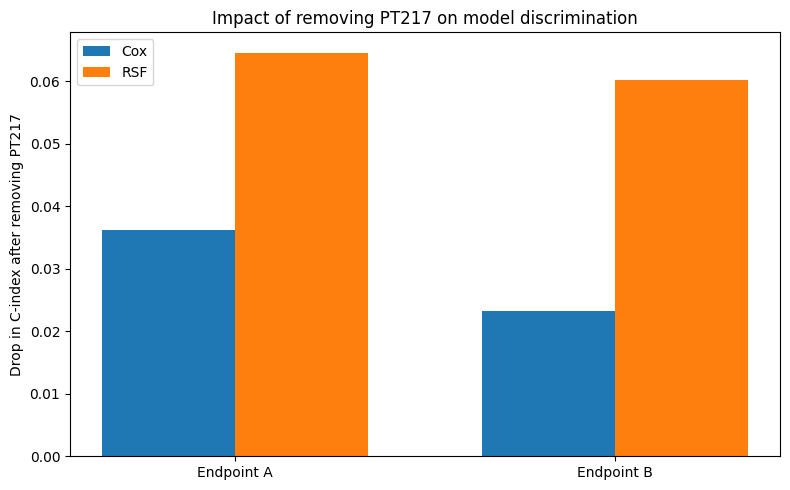

In [ ]:
plot_with_vs_without_ptau(drop_summary)

In [ ]:
comparison_with_ptau_A.to_csv("comparison_with_ptau_A.csv", index=False)
comparison_without_ptau_A.to_csv("comparison_without_ptau_A.csv", index=False)

comparison_with_ptau_B.to_csv("comparison_with_ptau_B.csv", index=False)
comparison_without_ptau_B.to_csv("comparison_without_ptau_B.csv", index=False)

drop_summary.to_csv("ptau_removal_cindex_drop.csv", index=False)
summary_without_ptau.to_csv("ptau_removal_summary.csv", index=False)

# Sensitivity, Specificity and Confusion Matrix-Style Analysis for Survival Models

This section evaluates whether the survival models can be interpreted in a clinically familiar classification framework.

Survival models predict risk over time rather than directly predicting a binary class. To calculate sensitivity, specificity, PPV, NPV and confusion matrices, we convert the survival prediction into a binary outcome at a fixed time horizon.

For example:

- Did the participant progress within 3 years?
- Was the participant predicted to be high risk by the model?

This allows Cox and Random Survival Forest models to be compared using classification-style performance metrics.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    roc_curve,
    roc_auc_score
)

from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

## 1. Load the survival dataset

This section loads the participant-level survival dataset. The dataset should contain:

- `RID`: participant identifier
- `time_years`: follow-up time in years
- `event`: event indicator, where 1 = progression and 0 = censored
- baseline diagnosis and biomarker predictors

The analysis can be repeated separately for each endpoint, such as Endpoint A and Endpoint B.

In [ ]:
# Load your dataset

df = pd.read_csv("MERGED_TIMEPOINTS_CLEAN_BIOMARKERS.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Dataset shape: (402, 17)
   RID Visit.Code   Exam.Date  PT217  FQ_AB42  FQ_AB40  FQ_AB42_AB40  \
0   10         bl  2005-11-10  0.472    24.44   332.15      0.073581   
1   10        m24  2007-11-07  0.586    19.61   288.14      0.068057   
2   93         bl  2006-01-26  1.021    25.05   359.49      0.069682   
3   93        m24  2008-01-28  1.204    21.65   316.65      0.068372   
4  108         bl  2006-02-14  0.606    26.65   317.70      0.083884   

   FQ_pT217_AB42  FQ_NFL  FQ_GFAP   DX  CDRSB  MMSE  ADAS13  ADAS11ish  \
0       0.019313    26.5    194.3   AD    NaN   NaN   24.33      12.33   
1       0.029883    30.2    221.3   AD    5.0  28.0   30.33      19.33   
2       0.040758    48.6    364.4   AD    NaN   NaN   36.67      22.67   
3       0.055612    62.4    587.0   AD   17.0   4.0     NaN        NaN   
4       0.022739    33.4    257.3  MCI    NaN   NaN   21.00      13.00   

   Gender  APOE4  
0  Female    1.0  
1  Female    1.0  
2  Female    1.0  
3  Female    1.0  
4 

## 2. Define required columns and predictors

The confusion matrix-style analysis needs a survival dataset with one row per participant. If the dataset contains repeated visits, this section keeps the baseline record for predictors.

The key predictors used here are:

- baseline diagnosis
- PT217
- GFAP
- NfL
- Aβ42/Aβ40
- p-tau217/Aβ42

Column names should be edited if they differ in the dataset.

In [ ]:
ID_COL = "RID"
VISIT_COL = "Visit.Code"

DX = "DX_score_baseline"
PTAU = "PT217"
GFAP = "FQ_GFAP"
NFL = "FQ_NFL"
AB = "FQ_AB42_AB40"
RATIO = "FQ_pT217_AB42"

TIME_COL = "time_years"
EVENT_COL = "event"

predictor_cols = [DX, PTAU, GFAP, NFL, AB, RATIO]

print("Predictors used:")
print(predictor_cols)

Predictors used:
['DX_score_baseline', 'PT217', 'FQ_GFAP', 'FQ_NFL', 'FQ_AB42_AB40', 'FQ_pT217_AB42']


## 3. Create or load endpoint-specific survival datasets

If endpoint-specific survival datasets already exist from earlier analysis, such as `surv_worsen_z` and `surv_ad_z`, use those directly.

If not, this section provides a placeholder structure. The dataset must contain one row per participant, with:

- follow-up time
- event indicator
- baseline predictors

Replace this section with the endpoint datasets already created in the main analysis notebook.

In [ ]:
# Check that your endpoint data exists
try:
    print("Endpoint A dataset:", surv_worsen_z.shape)
    print("Endpoint B dataset:", surv_ad_z.shape)
except NameError:
    print("Please define surv_worsen_z and surv_ad_z before continuing.")

Endpoint A dataset: (195, 14)
Endpoint B dataset: (157, 14)


## 4. Helper function for survival outcome format

Random Survival Forests require the outcome to be stored in a structured survival format containing both event status and follow-up time.

This helper function converts the dataset into the required format.

In [ ]:
def make_y(df_in, time_col="time_years", event_col="event"):
    """
    Convert survival dataframe into scikit-survival format.
    """
    return Surv.from_arrays(
        event=df_in[event_col].astype(bool).values,
        time=df_in[time_col].astype(float).values
    )

## 5. Define a binary outcome at a fixed time horizon

To create a confusion matrix, the survival outcome is converted into a binary outcome at a selected time horizon.

For example, at 3 years:

- 1 = participant progressed within 3 years
- 0 = participant did not progress within 3 years

Participants censored before the time horizon are difficult to classify definitively. In this simple version, they are treated as non-events, but this should be acknowledged as a limitation.

In [ ]:
def create_binary_outcome_at_time(df_in, time_horizon=3.0,
                                  time_col="time_years",
                                  event_col="event"):
    """
    Creates binary outcome:
    1 = event occurred by time_horizon
    0 = event did not occur by time_horizon

    Note: Participants censored before the horizon are treated as non-events
    in this simplified classification analysis.
    """
    y_binary = np.where(
        (df_in[event_col] == 1) & (df_in[time_col] <= time_horizon),
        1,
        0
    )
    return y_binary

## 6. Fit Cox model and predict risk at a fixed time horizon

The Cox model estimates relative hazard. To use it for classification-style analysis, we calculate the predicted survival probability at a selected time horizon and convert this to risk:

`risk = 1 - predicted survival probability`

Higher values indicate greater predicted risk of progression by the selected timepoint.

In [ ]:
def fit_cox_and_predict_risk(df_in, covars, time_horizon=3.0,
                             time_col="time_years",
                             event_col="event",
                             penalizer=0.1):
    """
    Fits Cox model and returns predicted event risk by time_horizon.
    """
    d = df_in[[time_col, event_col] + covars].dropna().copy()

    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[[time_col, event_col] + valid_covars].copy()

    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(d, duration_col=time_col, event_col=event_col)

    surv = cph.predict_survival_function(d[valid_covars])

    # interpolate survival probability at selected horizon
    surv_at_t = (
        surv.reindex(surv.index.union([time_horizon]))
        .sort_index()
        .interpolate(method="index")
        .ffill()
        .bfill()
        .loc[time_horizon]
    )

    risk = 1 - surv_at_t.values

    return cph, d, valid_covars, risk

## 7. Fit Random Survival Forest and predict risk at a fixed time horizon

Random Survival Forests estimate survival functions without requiring proportional hazards assumptions. As with the Cox model, predicted survival probability is converted to predicted event risk at the selected time horizon.

In [ ]:
def fit_rsf_and_predict_risk(df_in, covars, time_horizon=3.0,
                             time_col="time_years",
                             event_col="event",
                             random_state=42):
    """
    Fits RSF model and returns predicted event risk by time_horizon.
    """
    d = df_in[[time_col, event_col] + covars].dropna().copy()

    valid_covars = [c for c in covars if d[c].nunique() > 1]
    d = d[[time_col, event_col] + valid_covars].copy()

    X = d[valid_covars]
    y = make_y(d, time_col=time_col, event_col=event_col)

    rsf = RandomSurvivalForest(
        n_estimators=500,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=random_state
    )

    rsf.fit(X, y)

    surv_fns = rsf.predict_survival_function(X, return_array=False)

    risk = np.asarray([
        1 - fn(time_horizon) for fn in surv_fns
    ])

    return rsf, d, valid_covars, risk

## 8. Choose a risk threshold

Predicted risks must be converted into binary predictions.

A fixed threshold can be chosen manually, for example:

- risk ≥ 0.20 = high risk
- risk < 0.20 = low risk

Alternatively, the threshold can be selected using Youden's index from the ROC curve, which balances sensitivity and specificity.

In [ ]:
def get_best_threshold_youden(y_true, risk):
    """
    Selects threshold using Youden's index:
    sensitivity + specificity - 1
    """
    fpr, tpr, thresholds = roc_curve(y_true, risk)

    youden = tpr - fpr
    best_idx = np.argmax(youden)

    return thresholds[best_idx], fpr, tpr

## 9. Calculate confusion matrix and classification metrics

This section calculates:

- True positives
- False positives
- True negatives
- False negatives
- Sensitivity
- Specificity
- Accuracy
- Positive predictive value
- Negative predictive value

Sensitivity reflects the ability to identify participants who progress. Specificity reflects the ability to correctly identify participants who do not progress.

In [ ]:
def classification_metrics_from_risk(y_true, risk, threshold, model_name="Model"):
    """
    Converts predicted risk into binary classification and calculates metrics.
    """
    y_pred = (risk >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    # Handle cases where confusion matrix is not 2x2
    if cm.shape != (2, 2):
        print(f"{model_name}: Confusion matrix is not 2x2. Check class balance.")
        return None

    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

    auc = roc_auc_score(y_true, risk) if len(np.unique(y_true)) == 2 else np.nan

    results = {
        "model": model_name,
        "threshold": threshold,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "accuracy": accuracy,
        "ppv": ppv,
        "npv": npv,
        "auc": auc
    }

    return results

## 10. Run analysis for one endpoint

This function runs the full classification-style analysis for one endpoint and one predictor set.

It fits Cox and RSF models, calculates predicted risk at the selected time horizon, identifies optimal thresholds, and returns sensitivity/specificity results.

In [ ]:
def run_confusion_analysis_for_endpoint(df_endpoint,
                                        endpoint_name,
                                        covars,
                                        time_horizon=3.0,
                                        time_col="time_years",
                                        event_col="event"):
    """
    Runs Cox and RSF confusion matrix-style analysis for one endpoint.
    """

    print(f"\nRunning analysis for {endpoint_name}")
    print(f"Time horizon: {time_horizon} years")
    print(f"Covariates: {covars}")

    # ----------------------
    # Cox model
    # ----------------------
    cox_model, cox_data, cox_covars, cox_risk = fit_cox_and_predict_risk(
        df_endpoint,
        covars,
        time_horizon=time_horizon,
        time_col=time_col,
        event_col=event_col
    )

    y_cox = create_binary_outcome_at_time(
        cox_data,
        time_horizon=time_horizon,
        time_col=time_col,
        event_col=event_col
    )

    cox_threshold, cox_fpr, cox_tpr = get_best_threshold_youden(y_cox, cox_risk)

    cox_metrics = classification_metrics_from_risk(
        y_cox,
        cox_risk,
        cox_threshold,
        model_name=f"{endpoint_name} - Cox"
    )

    # ----------------------
    # RSF model
    # ----------------------
    rsf_model, rsf_data, rsf_covars, rsf_risk = fit_rsf_and_predict_risk(
        df_endpoint,
        covars,
        time_horizon=time_horizon,
        time_col=time_col,
        event_col=event_col
    )

    y_rsf = create_binary_outcome_at_time(
        rsf_data,
        time_horizon=time_horizon,
        time_col=time_col,
        event_col=event_col
    )

    rsf_threshold, rsf_fpr, rsf_tpr = get_best_threshold_youden(y_rsf, rsf_risk)

    rsf_metrics = classification_metrics_from_risk(
        y_rsf,
        rsf_risk,
        rsf_threshold,
        model_name=f"{endpoint_name} - RSF"
    )

    results_df = pd.DataFrame([cox_metrics, rsf_metrics])

    return {
        "results": results_df,
        "cox_model": cox_model,
        "rsf_model": rsf_model,
        "cox_risk": cox_risk,
        "rsf_risk": rsf_risk,
        "y_cox": y_cox,
        "y_rsf": y_rsf,
        "cox_roc": (cox_fpr, cox_tpr),
        "rsf_roc": (rsf_fpr, rsf_tpr)
    }

## 11. Run the analysis using the main model

The main model includes baseline diagnosis and PT217, as previous analyses showed that PT217 provided the strongest incremental predictive value.

This section runs the confusion matrix-style analysis for both endpoints at a 3-year time horizon.

In [ ]:
main_covars = [DX, PTAU]

time_horizon = 3.0

endpoint_A_confusion = run_confusion_analysis_for_endpoint(
    surv_worsen_z,
    endpoint_name="Endpoint A",
    covars=main_covars,
    time_horizon=time_horizon
)

endpoint_B_confusion = run_confusion_analysis_for_endpoint(
    surv_ad_z,
    endpoint_name="Endpoint B",
    covars=main_covars,
    time_horizon=time_horizon
)

display(endpoint_A_confusion["results"])
display(endpoint_B_confusion["results"])


Running analysis for Endpoint A
Time horizon: 3.0 years
Covariates: ['DX_score_baseline', 'PT217']

Running analysis for Endpoint B
Time horizon: 3.0 years
Covariates: ['DX_score_baseline', 'PT217']


,model,threshold,true_negative,false_positive,false_negative,true_positive,sensitivity,specificity,accuracy,ppv,npv,auc
0,Endpoint A - Cox,0.042066,61,124,0,10,1.0,0.329730,0.364103,0.074627,1.0,0.657297
1,Endpoint A - RSF,0.114529,158,27,0,10,1.0,0.854054,0.861538,0.270270,1.0,0.941622


,model,threshold,true_negative,false_positive,false_negative,true_positive,sensitivity,specificity,accuracy,ppv,npv,auc
0,Endpoint B - Cox,0.117496,142,9,2,4,0.666667,0.940397,0.929936,0.307692,0.986111,0.844371
1,Endpoint B - RSF,0.150165,137,14,0,6,1.000000,0.907285,0.910828,0.300000,1.000000,0.948124


## 12. Compare models with and without PT217

This section repeats the classification-style analysis after removing PT217. This helps assess whether sensitivity and specificity are reduced when PT217 is excluded from the model.

In [ ]:
without_ptau_covars = [DX, GFAP, NFL, AB]

endpoint_A_no_ptau = run_confusion_analysis_for_endpoint(
    surv_worsen_z,
    endpoint_name="Endpoint A without PT217",
    covars=without_ptau_covars,
    time_horizon=time_horizon
)

endpoint_B_no_ptau = run_confusion_analysis_for_endpoint(
    surv_ad_z,
    endpoint_name="Endpoint B without PT217",
    covars=without_ptau_covars,
    time_horizon=time_horizon
)

display(endpoint_A_no_ptau["results"])
display(endpoint_B_no_ptau["results"])


Running analysis for Endpoint A without PT217
Time horizon: 3.0 years
Covariates: ['DX_score_baseline', 'FQ_GFAP', 'FQ_NFL', 'FQ_AB42_AB40']

Running analysis for Endpoint B without PT217
Time horizon: 3.0 years
Covariates: ['DX_score_baseline', 'FQ_GFAP', 'FQ_NFL', 'FQ_AB42_AB40']


,model,threshold,true_negative,false_positive,false_negative,true_positive,sensitivity,specificity,accuracy,ppv,npv,auc
0,Endpoint A without PT217 - Cox,0.041853,64,121,0,10,1.0,0.345946,0.379487,0.076336,1.0,0.636216
1,Endpoint A without PT217 - RSF,0.145990,167,18,0,10,1.0,0.902703,0.907692,0.357143,1.0,0.956757


,model,threshold,true_negative,false_positive,false_negative,true_positive,sensitivity,specificity,accuracy,ppv,npv,auc
0,Endpoint B without PT217 - Cox,0.032546,84,67,0,6,1.0,0.556291,0.573248,0.082192,1.0,0.764901
1,Endpoint B without PT217 - RSF,0.155553,144,7,0,6,1.0,0.953642,0.955414,0.461538,1.0,0.966887


## 13. Combine all classification results

This table combines sensitivity, specificity, accuracy, PPV, NPV and AUC across models and endpoints.

In [ ]:
classification_summary = pd.concat([
    endpoint_A_confusion["results"],
    endpoint_B_confusion["results"],
    endpoint_A_no_ptau["results"],
    endpoint_B_no_ptau["results"]
], ignore_index=True)

display(classification_summary)

classification_summary.to_csv("classification_summary_survival_models.csv", index=False)

,model,threshold,true_negative,false_positive,false_negative,true_positive,sensitivity,specificity,accuracy,ppv,npv,auc
0,Endpoint A - Cox,0.042066,61,124,0,10,1.000000,0.329730,0.364103,0.074627,1.000000,0.657297
1,Endpoint A - RSF,0.114529,158,27,0,10,1.000000,0.854054,0.861538,0.270270,1.000000,0.941622
2,Endpoint B - Cox,0.117496,142,9,2,4,0.666667,0.940397,0.929936,0.307692,0.986111,0.844371
3,Endpoint B - RSF,0.150165,137,14,0,6,1.000000,0.907285,0.910828,0.300000,1.000000,0.948124
4,Endpoint A without PT217 - Cox,0.041853,64,121,0,10,1.000000,0.345946,0.379487,0.076336,1.000000,0.636216
5,Endpoint A without PT217 - RSF,0.145990,167,18,0,10,1.000000,0.902703,0.907692,0.357143,1.000000,0.956757
6,Endpoint B without PT217 - Cox,0.032546,84,67,0,6,1.000000,0.556291,0.573248,0.082192,1.000000,0.764901
7,Endpoint B without PT217 - RSF,0.155553,144,7,0,6,1.000000,0.953642,0.955414,0.461538,1.000000,0.966887


## 14. Plot ROC curves

ROC curves show the trade-off between sensitivity and specificity across all possible thresholds. A higher AUC indicates better binary discrimination at the selected time horizon.

In [ ]:
def plot_roc(endpoint_result, title):
    cox_fpr, cox_tpr = endpoint_result["cox_roc"]
    rsf_fpr, rsf_tpr = endpoint_result["rsf_roc"]

    cox_auc = endpoint_result["results"].loc[
        endpoint_result["results"]["model"].str.contains("Cox"), "auc"
    ].values[0]

    rsf_auc = endpoint_result["results"].loc[
        endpoint_result["results"]["model"].str.contains("RSF"), "auc"
    ].values[0]

    plt.figure(figsize=(6, 5))
    plt.plot(cox_fpr, cox_tpr, label=f"Cox AUC = {cox_auc:.3f}")
    plt.plot(rsf_fpr, rsf_tpr, label=f"RSF AUC = {rsf_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Sensitivity")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

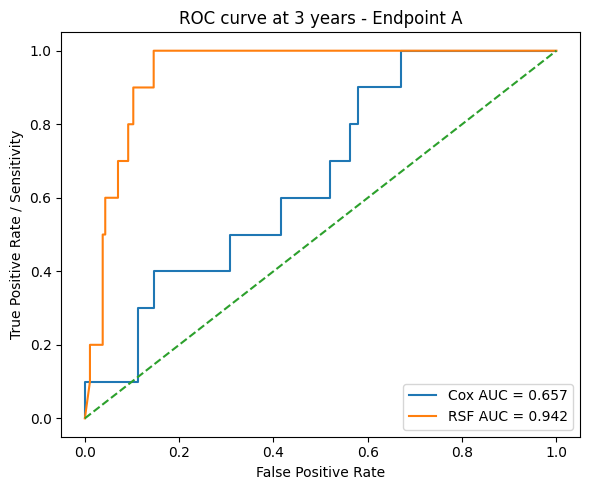

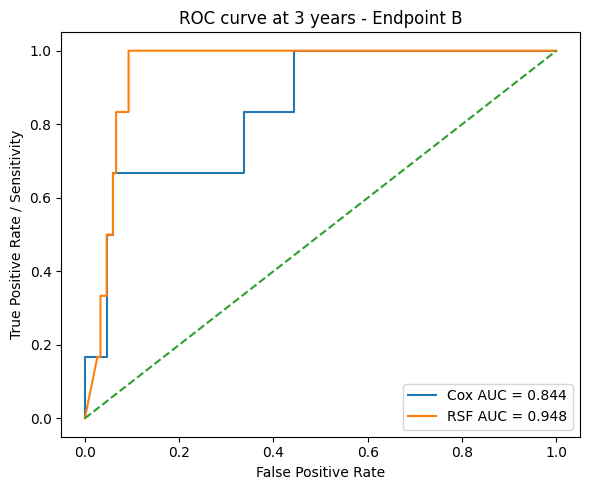

In [ ]:
plot_roc(endpoint_A_confusion, "ROC curve at 3 years - Endpoint A")
plot_roc(endpoint_B_confusion, "ROC curve at 3 years - Endpoint B")

## 15. Plot confusion matrices

The confusion matrix shows how many participants were correctly or incorrectly classified as progressing by the selected time horizon.

In [ ]:
def plot_confusion_matrix_from_metrics(row, title):
    cm = np.array([
        [row["true_negative"], row["false_positive"]],
        [row["false_negative"], row["true_positive"]]
    ])

    plt.figure(figsize=(4, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xticks([0, 1], ["Predicted no event", "Predicted event"], rotation=45, ha="right")
    plt.yticks([0, 1], ["Observed no event", "Observed event"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

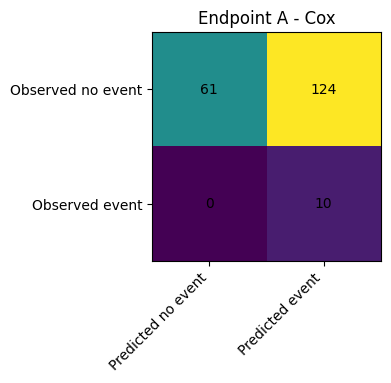

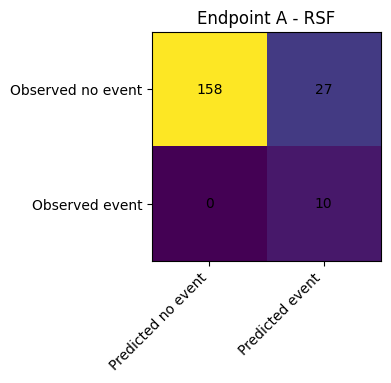

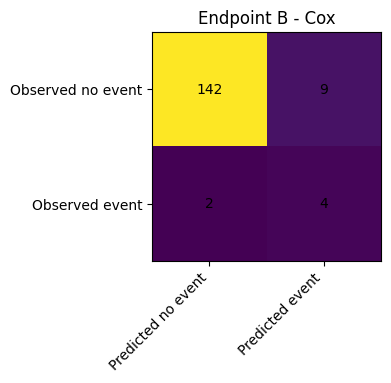

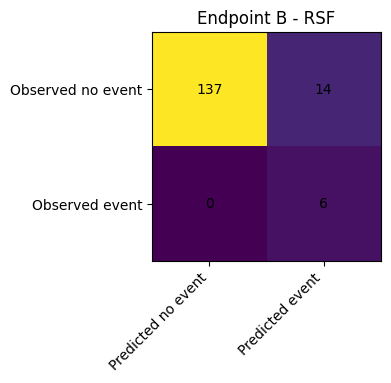

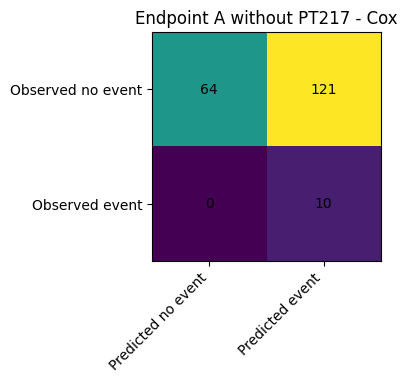

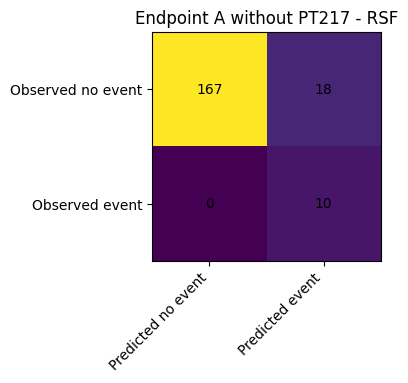

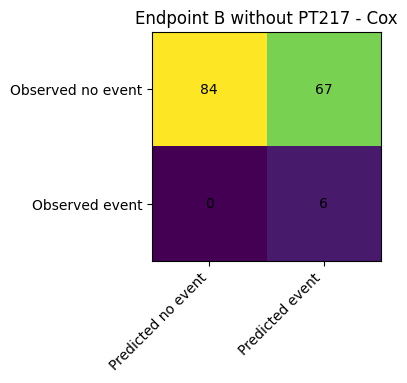

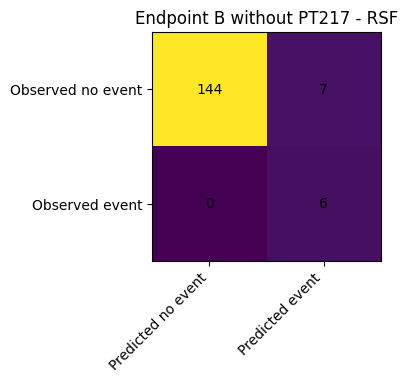

In [ ]:
for _, row in classification_summary.iterrows():
    plot_confusion_matrix_from_metrics(row, row["model"])

## 16. Interpretation

This analysis translates survival model predictions into a clinically familiar classification framework.

Sensitivity indicates how well the model detects participants who progress by the selected time horizon. Specificity indicates how well it identifies participants who do not progress. PPV reflects the probability that a participant predicted as high risk actually progresses, while NPV reflects the probability that a participant predicted as low risk does not progress.

These metrics are threshold-dependent and should be interpreted as complementary to survival-specific metrics such as the C-index and IBS.

# Comparison of Endpoint A and Endpoint B model performance

Endpoint B has been prioritised as the primary outcome because it represents conversion to Alzheimer’s disease, which is more clinically specific than the broader Endpoint A definition of any worsening.

Endpoint A is retained as a supplementary analysis because it captures earlier clinical worsening, including CN to MCI transitions. However, this endpoint may be more heterogeneous because MCI can reflect normal ageing, non-AD pathology, or other causes of cognitive impairment.

This section directly compares model performance between Endpoint A and Endpoint B for both Cox proportional hazards models and Random Survival Forest models.

In [ ]:
# Add model type labels
cox_A = cox_table_A.copy()
cox_B = cox_table_B.copy()

cox_A["model_type"] = "Cox"
cox_B["model_type"] = "Cox"

cox_combined = pd.concat([cox_A, cox_B], ignore_index=True)

display(cox_combined)

,endpoint,model,mean_cv_cindex,sd_cv_cindex,model_type
0,Endpoint A,DX + PT217,0.775863,0.102997,Cox
1,Endpoint A,DX + PT217 + GFAP,0.770565,0.110440,Cox
2,Endpoint A,DX + all biomarkers,0.766643,0.097144,Cox
3,Endpoint A,DX + PT217 + NFL,0.765520,0.105599,Cox
4,Endpoint A,DX only,0.633780,0.076685,Cox
5,Endpoint B,DX + PT217,0.892374,0.041256,Cox
6,Endpoint B,DX + PT217 + NFL,0.892119,0.037489,Cox
7,Endpoint B,DX + all biomarkers,0.875741,0.036898,Cox
8,Endpoint B,DX + PT217 + GFAP,0.875454,0.034924,Cox
9,Endpoint B,DX only,0.806735,0.057714,Cox


In [ ]:
rsf_A = rsf_table_A.copy()
rsf_B = rsf_table_B.copy()

rsf_A["model_type"] = "RSF"
rsf_B["model_type"] = "RSF"

rsf_combined = pd.concat([rsf_A, rsf_B], ignore_index=True)

display(rsf_combined)

,endpoint,model,mean_cv_cindex,sd_cv_cindex,model_type
0,Endpoint A,DX + PT217 + GFAP,0.810171,0.049859,RSF
1,Endpoint A,DX + PT217 + NFL,0.795881,0.067845,RSF
2,Endpoint A,DX + all biomarkers,0.795351,0.081424,RSF
3,Endpoint A,DX + PT217,0.795345,0.066636,RSF
4,Endpoint A,DX only,0.683867,0.060228,RSF
5,Endpoint B,DX + all biomarkers,0.901169,0.030005,RSF
6,Endpoint B,DX + PT217 + NFL,0.881860,0.028771,RSF
7,Endpoint B,DX + PT217 + GFAP,0.878142,0.041700,RSF
8,Endpoint B,DX + PT217,0.872544,0.021518,RSF
9,Endpoint B,DX only,0.806735,0.057714,RSF


In [ ]:
all_endpoint_results = pd.concat([cox_combined, rsf_combined], ignore_index=True)

# Make sure endpoint names are consistent
all_endpoint_results["endpoint"] = all_endpoint_results["endpoint"].astype(str)

display(all_endpoint_results)

,endpoint,model,mean_cv_cindex,sd_cv_cindex,model_type
0,Endpoint A,DX + PT217,0.775863,0.102997,Cox
1,Endpoint A,DX + PT217 + GFAP,0.770565,0.110440,Cox
2,Endpoint A,DX + all biomarkers,0.766643,0.097144,Cox
3,Endpoint A,DX + PT217 + NFL,0.765520,0.105599,Cox
4,Endpoint A,DX only,0.633780,0.076685,Cox
5,Endpoint B,DX + PT217,0.892374,0.041256,Cox
6,Endpoint B,DX + PT217 + NFL,0.892119,0.037489,Cox
7,Endpoint B,DX + all biomarkers,0.875741,0.036898,Cox
8,Endpoint B,DX + PT217 + GFAP,0.875454,0.034924,Cox
9,Endpoint B,DX only,0.806735,0.057714,Cox


## Direct comparison of Endpoint A and Endpoint B

This table compares the same model specification across Endpoint A and Endpoint B. A positive value means the model performed better for Endpoint B than Endpoint A.

In [ ]:
endpoint_comparison = (
    all_endpoint_results
    .pivot_table(
        index=["model_type", "model"],
        columns="endpoint",
        values="mean_cv_cindex"
    )
    .reset_index()
)

# Rename columns if needed
endpoint_cols = endpoint_comparison.columns.tolist()
print(endpoint_cols)

# Adjust these names if your endpoints are named slightly differently
endpoint_A_col = [c for c in endpoint_comparison.columns if "Endpoint A" in str(c)][0]
endpoint_B_col = [c for c in endpoint_comparison.columns if "Endpoint B" in str(c)][0]

endpoint_comparison["Endpoint_B_minus_Endpoint_A"] = (
    endpoint_comparison[endpoint_B_col] - endpoint_comparison[endpoint_A_col]
)

endpoint_comparison = endpoint_comparison.sort_values(
    "Endpoint_B_minus_Endpoint_A",
    ascending=False
)

display(endpoint_comparison)

['model_type', 'model', 'Endpoint A', 'Endpoint B']


endpoint,model_type,model,Endpoint A,Endpoint B,Endpoint_B_minus_Endpoint_A
4,Cox,DX only,0.633780,0.806735,0.172955
2,Cox,DX + PT217 + NFL,0.765520,0.892119,0.126599
9,RSF,DX only,0.683867,0.806735,0.122868
0,Cox,DX + PT217,0.775863,0.892374,0.116511
3,Cox,DX + all biomarkers,0.766643,0.875741,0.109098
8,RSF,DX + all biomarkers,0.795351,0.901169,0.105817
1,Cox,DX + PT217 + GFAP,0.770565,0.875454,0.104890
7,RSF,DX + PT217 + NFL,0.795881,0.881860,0.085979
5,RSF,DX + PT217,0.795345,0.872544,0.077198
6,RSF,DX + PT217 + GFAP,0.810171,0.878142,0.067971


In [ ]:
endpoint_comparison_sd = (
    all_endpoint_results
    .pivot_table(
        index=["model_type", "model"],
        columns="endpoint",
        values="sd_cv_cindex"
    )
    .reset_index()
)

endpoint_A_sd_col = [c for c in endpoint_comparison_sd.columns if "Endpoint A" in str(c)][0]
endpoint_B_sd_col = [c for c in endpoint_comparison_sd.columns if "Endpoint B" in str(c)][0]

endpoint_comparison_sd["SD_difference_B_minus_A"] = (
    endpoint_comparison_sd[endpoint_B_sd_col] - endpoint_comparison_sd[endpoint_A_sd_col]
)

display(endpoint_comparison_sd)

endpoint,model_type,model,Endpoint A,Endpoint B,SD_difference_B_minus_A
0,Cox,DX + PT217,0.102997,0.041256,-0.061741
1,Cox,DX + PT217 + GFAP,0.110440,0.034924,-0.075516
2,Cox,DX + PT217 + NFL,0.105599,0.037489,-0.068110
3,Cox,DX + all biomarkers,0.097144,0.036898,-0.060246
4,Cox,DX only,0.076685,0.057714,-0.018971
5,RSF,DX + PT217,0.066636,0.021518,-0.045118
6,RSF,DX + PT217 + GFAP,0.049859,0.041700,-0.008158
7,RSF,DX + PT217 + NFL,0.067845,0.028771,-0.039074
8,RSF,DX + all biomarkers,0.081424,0.030005,-0.051419
9,RSF,DX only,0.060228,0.057714,-0.002514


## Cox versus RSF comparison within each endpoint

This section compares whether RSF outperformed Cox within each endpoint for the same model specification.

In [ ]:
cox_vs_rsf = (
    all_endpoint_results
    .pivot_table(
        index=["endpoint", "model"],
        columns="model_type",
        values="mean_cv_cindex"
    )
    .reset_index()
)

cox_vs_rsf["RSF_minus_Cox"] = cox_vs_rsf["RSF"] - cox_vs_rsf["Cox"]

cox_vs_rsf = cox_vs_rsf.sort_values(
    ["endpoint", "RSF_minus_Cox"],
    ascending=[True, False]
)

display(cox_vs_rsf)

model_type,endpoint,model,Cox,RSF,RSF_minus_Cox
4,Endpoint A,DX only,0.633780,0.683867,0.050087
1,Endpoint A,DX + PT217 + GFAP,0.770565,0.810171,0.039606
2,Endpoint A,DX + PT217 + NFL,0.765520,0.795881,0.030361
3,Endpoint A,DX + all biomarkers,0.766643,0.795351,0.028708
0,Endpoint A,DX + PT217,0.775863,0.795345,0.019482
8,Endpoint B,DX + all biomarkers,0.875741,0.901169,0.025428
6,Endpoint B,DX + PT217 + GFAP,0.875454,0.878142,0.002687
9,Endpoint B,DX only,0.806735,0.806735,0.000000
7,Endpoint B,DX + PT217 + NFL,0.892119,0.881860,-0.010259
5,Endpoint B,DX + PT217,0.892374,0.872544,-0.019830


## Best model comparison by endpoint

This section identifies the best-performing Cox and RSF models for each endpoint.

In [ ]:
best_models_by_endpoint = (
    all_endpoint_results
    .sort_values("mean_cv_cindex", ascending=False)
    .groupby(["endpoint", "model_type"])
    .head(1)
    .reset_index(drop=True)
)

display(best_models_by_endpoint)

,endpoint,model,mean_cv_cindex,sd_cv_cindex,model_type
0,Endpoint B,DX + all biomarkers,0.901169,0.030005,RSF
1,Endpoint B,DX + PT217,0.892374,0.041256,Cox
2,Endpoint A,DX + PT217 + GFAP,0.810171,0.049859,RSF
3,Endpoint A,DX + PT217,0.775863,0.102997,Cox


## Summary table for reporting

This summary table gives the best Cox and RSF performance for Endpoint A and Endpoint B, making it easier to report the main findings.

In [ ]:
summary_endpoint_table = best_models_by_endpoint[
    ["endpoint", "model_type", "model", "mean_cv_cindex", "sd_cv_cindex"]
].copy()

summary_endpoint_table["C-index mean ± SD"] = (
    summary_endpoint_table["mean_cv_cindex"].round(3).astype(str)
    + " ± "
    + summary_endpoint_table["sd_cv_cindex"].round(3).astype(str)
)

summary_endpoint_table = summary_endpoint_table[
    ["endpoint", "model_type", "model", "C-index mean ± SD"]
]

display(summary_endpoint_table)

,endpoint,model_type,model,C-index mean ± SD
0,Endpoint B,RSF,DX + all biomarkers,0.901 ± 0.03
1,Endpoint B,Cox,DX + PT217,0.892 ± 0.041
2,Endpoint A,RSF,DX + PT217 + GFAP,0.81 ± 0.05
3,Endpoint A,Cox,DX + PT217,0.776 ± 0.103


In [ ]:
ibs_comparison = pd.DataFrame([
    {
        "endpoint": "Endpoint A",
        "cox_ibs": ibs_A["cox_ibs_mean"],
        "rsf_ibs": ibs_A["rsf_ibs_mean"]
    },
    {
        "endpoint": "Endpoint B",
        "cox_ibs": ibs_B["cox_ibs_mean"],
        "rsf_ibs": ibs_B["rsf_ibs_mean"]
    }
])

ibs_comparison["rsf_minus_cox_ibs"] = (
    ibs_comparison["rsf_ibs"] - ibs_comparison["cox_ibs"]
)

display(ibs_comparison)

,endpoint,cox_ibs,rsf_ibs,rsf_minus_cox_ibs
0,Endpoint A,0.107273,0.102495,-0.004778
1,Endpoint B,0.089283,0.088243,-0.001040


# Endpoint B progression routes

Endpoint B focuses on conversion to Alzheimer’s disease. This section identifies which participants progressed to AD and separates the progression routes into:

- CN → AD
- MCI → AD

This is useful because Endpoint B may be driven mostly by participants who were already MCI at baseline, rather than by direct CN to AD conversion.

In [ ]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("MERGED_TIMEPOINTS_CLEAN_BIOMARKERS.csv")

print(df.shape)
print(df.columns.tolist())

display(df.head())

(402, 17)
['RID', 'Visit.Code', 'Exam.Date', 'PT217', 'FQ_AB42', 'FQ_AB40', 'FQ_AB42_AB40', 'FQ_pT217_AB42', 'FQ_NFL', 'FQ_GFAP', 'DX', 'CDRSB', 'MMSE', 'ADAS13', 'ADAS11ish', 'Gender', 'APOE4']


,RID,Visit.Code,Exam.Date,PT217,FQ_AB42,FQ_AB40,FQ_AB42_AB40,FQ_pT217_AB42,FQ_NFL,FQ_GFAP,DX,CDRSB,MMSE,ADAS13,ADAS11ish,Gender,APOE4
0,10,bl,2005-11-10,0.472,24.44,332.15,0.073581,0.019313,26.5,194.3,AD,NaN,NaN,24.33,12.33,Female,1.0
1,10,m24,2007-11-07,0.586,19.61,288.14,0.068057,0.029883,30.2,221.3,AD,5.0,28.0,30.33,19.33,Female,1.0
2,93,bl,2006-01-26,1.021,25.05,359.49,0.069682,0.040758,48.6,364.4,AD,NaN,NaN,36.67,22.67,Female,1.0
3,93,m24,2008-01-28,1.204,21.65,316.65,0.068372,0.055612,62.4,587.0,AD,17.0,4.0,NaN,NaN,Female,1.0
4,108,bl,2006-02-14,0.606,26.65,317.70,0.083884,0.022739,33.4,257.3,MCI,NaN,NaN,21.00,13.00,Male,1.0


In [ ]:
print("Diagnosis counts:")
display(df["DX"].value_counts(dropna=False))

print("Visit counts:")
display(df["Visit.Code"].value_counts(dropna=False))

Diagnosis counts:


,count
DX,
CN,157
MCI,132
AD,111
NaN,2


Visit counts:


,count
Visit.Code,
bl,195
m72,47
m12,42
m36,37
m24,35
m60,23
m48,23


In [ ]:
def visit_to_month(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower()
    if x == "bl":
        return 0
    match = re.match(r"m(\d+)", x)
    if match:
        return int(match.group(1))
    return np.nan

df["visit_month"] = df["Visit.Code"].apply(visit_to_month)

df_prog = (
    df
    .dropna(subset=["RID", "Visit.Code", "DX", "visit_month"])
    .copy()
)

df_prog["Exam.Date"] = pd.to_datetime(df_prog["Exam.Date"], errors="coerce")

df_prog = df_prog.sort_values(["RID", "visit_month", "Exam.Date"])

print(df_prog.shape)
display(df_prog[["RID", "Visit.Code", "visit_month", "Exam.Date", "DX"]].head(10))

(400, 18)


,RID,Visit.Code,visit_month,Exam.Date,DX
0,10,bl,0,2005-11-10,AD
1,10,m24,24,2007-11-07,AD
2,93,bl,0,2006-01-26,AD
3,93,m24,24,2008-01-28,AD
4,108,bl,0,2006-02-14,MCI
5,108,m72,72,2012-02-07,AD
6,149,bl,0,2006-02-08,AD
7,149,m24,24,2008-02-11,AD
8,183,bl,0,2006-04-04,AD
9,183,m24,24,2008-04-09,AD


## Identify baseline diagnosis and AD conversion

For Endpoint B, participants with baseline AD are excluded because they have already reached the endpoint at baseline.

For participants who start as CN or MCI, the code checks whether they ever have a later diagnosis of AD.

In [ ]:
def summarise_endpoint_b(group):
    group = group.sort_values(["visit_month", "Exam.Date"])

    baseline_dx = group["DX"].iloc[0]
    baseline_visit = group["Visit.Code"].iloc[0]
    baseline_month = group["visit_month"].iloc[0]

    # Exclude baseline AD from Endpoint B risk set
    if baseline_dx == "AD":
        return pd.Series({
            "baseline_dx": baseline_dx,
            "baseline_visit": baseline_visit,
            "baseline_month": baseline_month,
            "endpoint_b_event": np.nan,
            "conversion_route": "Baseline AD - excluded",
            "first_ad_visit": np.nan,
            "first_ad_month": np.nan,
            "final_dx": group["DX"].iloc[-1],
            "n_visits": group["Visit.Code"].nunique()
        })

    # Look for first AD diagnosis after baseline
    ad_rows = group[(group["DX"] == "AD") & (group["visit_month"] > baseline_month)]

    if len(ad_rows) > 0:
        first_ad = ad_rows.iloc[0]
        endpoint_b_event = 1
        conversion_route = f"{baseline_dx} → AD"
        first_ad_visit = first_ad["Visit.Code"]
        first_ad_month = first_ad["visit_month"]
    else:
        endpoint_b_event = 0
        conversion_route = f"{baseline_dx} → no AD"
        first_ad_visit = np.nan
        first_ad_month = np.nan

    return pd.Series({
        "baseline_dx": baseline_dx,
        "baseline_visit": baseline_visit,
        "baseline_month": baseline_month,
        "endpoint_b_event": endpoint_b_event,
        "conversion_route": conversion_route,
        "first_ad_visit": first_ad_visit,
        "first_ad_month": first_ad_month,
        "final_dx": group["DX"].iloc[-1],
        "n_visits": group["Visit.Code"].nunique()
    })

endpoint_b_summary = (
    df_prog
    .groupby("RID")
    .apply(summarise_endpoint_b)
    .reset_index()
)

display(endpoint_b_summary.head())

,RID,baseline_dx,baseline_visit,baseline_month,endpoint_b_event,conversion_route,first_ad_visit,first_ad_month,final_dx,n_visits
0,10,AD,bl,0,NaN,Baseline AD - excluded,NaN,NaN,AD,2
1,93,AD,bl,0,NaN,Baseline AD - excluded,NaN,NaN,AD,2
2,108,MCI,bl,0,1.0,MCI → AD,m72,72.0,AD,2
3,149,AD,bl,0,NaN,Baseline AD - excluded,NaN,NaN,AD,2
4,183,AD,bl,0,NaN,Baseline AD - excluded,NaN,NaN,AD,2


In [ ]:
endpoint_b_risk_set = endpoint_b_summary[
    endpoint_b_summary["baseline_dx"].isin(["CN", "MCI"])
].copy()

route_counts = (
    endpoint_b_risk_set["conversion_route"]
    .value_counts()
    .reset_index()
)

route_counts.columns = ["conversion_route", "n_participants"]

display(route_counts)

,conversion_route,n_participants
0,CN → no AD,84
1,MCI → no AD,39
2,MCI → AD,33
3,CN → AD,1


In [ ]:
cn_to_ad = endpoint_b_risk_set[
    endpoint_b_risk_set["conversion_route"] == "CN → AD"
].shape[0]

mci_to_ad = endpoint_b_risk_set[
    endpoint_b_risk_set["conversion_route"] == "MCI → AD"
].shape[0]

cn_no_ad = endpoint_b_risk_set[
    endpoint_b_risk_set["conversion_route"] == "CN → no AD"
].shape[0]

mci_no_ad = endpoint_b_risk_set[
    endpoint_b_risk_set["conversion_route"] == "MCI → no AD"
].shape[0]

progression_route_table = pd.DataFrame({
    "Route": ["CN → AD", "MCI → AD", "CN → no AD", "MCI → no AD"],
    "n_participants": [cn_to_ad, mci_to_ad, cn_no_ad, mci_no_ad]
})

display(progression_route_table)

,Route,n_participants
0,CN → AD,1
1,MCI → AD,33
2,CN → no AD,84
3,MCI → no AD,39


In [ ]:
baseline_counts = (
    endpoint_b_risk_set["baseline_dx"]
    .value_counts()
)

n_cn = baseline_counts.get("CN", 0)
n_mci = baseline_counts.get("MCI", 0)

cn_to_ad_pct = 100 * cn_to_ad / n_cn if n_cn > 0 else np.nan
mci_to_ad_pct = 100 * mci_to_ad / n_mci if n_mci > 0 else np.nan

percentage_table = pd.DataFrame({
    "Baseline group": ["CN", "MCI"],
    "n_at_baseline": [n_cn, n_mci],
    "n_converted_to_AD": [cn_to_ad, mci_to_ad],
    "percentage_converted_to_AD": [cn_to_ad_pct, mci_to_ad_pct]
})

display(percentage_table)

,Baseline group,n_at_baseline,n_converted_to_AD,percentage_converted_to_AD
0,CN,85,1,1.176471
1,MCI,72,33,45.833333


In [ ]:
endpoint_b_summary.to_csv("endpoint_b_progression_routes.csv", index=False)
progression_route_table.to_csv("endpoint_b_route_counts.csv", index=False)
percentage_table.to_csv("endpoint_b_route_percentages.csv", index=False)

print("Saved:")
print("- endpoint_b_progression_routes.csv")
print("- endpoint_b_route_counts.csv")
print("- endpoint_b_route_percentages.csv")

Saved:
- endpoint_b_progression_routes.csv
- endpoint_b_route_counts.csv
- endpoint_b_route_percentages.csv


# Endpoint B subgroup analyses

This section investigates whether prediction of Alzheimer’s disease conversion differs depending on baseline diagnosis.

Two clinically relevant subgroups are evaluated:

1. CN → AD
2. MCI → AD

The aim is to determine whether model performance is primarily driven by individuals with baseline MCI, who are generally considered at higher risk of progression to Alzheimer’s disease.

In [ ]:
# CN baseline subgroup
cn_baseline_df = endpoint_b_summary[
    endpoint_b_summary["baseline_dx"] == "CN"
].copy()

# MCI baseline subgroup
mci_baseline_df = endpoint_b_summary[
    endpoint_b_summary["baseline_dx"] == "MCI"
].copy()

print("CN baseline participants:", cn_baseline_df.shape[0])
print("MCI baseline participants:", mci_baseline_df.shape[0])

print("\nCN subgroup event counts:")
print(cn_baseline_df["endpoint_b_event"].value_counts())

print("\nMCI subgroup event counts:")
print(mci_baseline_df["endpoint_b_event"].value_counts())

CN baseline participants: 85
MCI baseline participants: 72

CN subgroup event counts:
endpoint_b_event
0.0    84
1.0     1
Name: count, dtype: int64

MCI subgroup event counts:
endpoint_b_event
0.0    39
1.0    33
Name: count, dtype: int64


In [ ]:
cn_ids = cn_baseline_df["RID"].unique()
mci_ids = mci_baseline_df["RID"].unique()

cn_longitudinal = df_prog[df_prog["RID"].isin(cn_ids)].copy()
mci_longitudinal = df_prog[df_prog["RID"].isin(mci_ids)].copy()

print("CN longitudinal shape:", cn_longitudinal.shape)
print("MCI longitudinal shape:", mci_longitudinal.shape)

CN longitudinal shape: (175, 18)
MCI longitudinal shape: (148, 18)


## Create subgroup-specific survival datasets

For each subgroup:
- time-to-event represents time to AD conversion,
- event = 1 if AD conversion occurred,
- event = 0 if censored.

In [ ]:
# Keep only required survival columns
survival_cols = [
    "RID",
    "endpoint_b_event",
    "first_ad_month",
    "baseline_dx"
]

cn_survival = cn_baseline_df[survival_cols].copy()
mci_survival = mci_baseline_df[survival_cols].copy()

# Create duration variable
# If converted → use conversion time
# If censored → use max follow-up

max_followup = (
    df_prog
    .groupby("RID")["visit_month"]
    .max()
    .reset_index(name="max_followup")
)

cn_survival = cn_survival.merge(max_followup, on="RID", how="left")
mci_survival = mci_survival.merge(max_followup, on="RID", how="left")

cn_survival["time_years"] = np.where(
    cn_survival["endpoint_b_event"] == 1,
    cn_survival["first_ad_month"],
    cn_survival["max_followup"]
) / 12

mci_survival["time_years"] = np.where(
    mci_survival["endpoint_b_event"] == 1,
    mci_survival["first_ad_month"],
    mci_survival["max_followup"]
) / 12

display(cn_survival.head())
display(mci_survival.head())

,RID,endpoint_b_event,first_ad_month,baseline_dx,max_followup,time_years
0,223,1.0,36.0,CN,36,3.0
1,479,0.0,NaN,CN,72,6.0
2,1203,0.0,NaN,CN,48,4.0
3,4071,0.0,NaN,CN,48,4.0
4,4158,0.0,NaN,CN,48,4.0


,RID,endpoint_b_event,first_ad_month,baseline_dx,max_followup,time_years
0,108,1.0,72.0,MCI,72,6.0
1,256,1.0,72.0,MCI,72,6.0
2,269,1.0,60.0,MCI,60,5.0
3,326,1.0,36.0,MCI,36,3.0
4,362,1.0,48.0,MCI,48,4.0


In [ ]:
baseline_biomarkers = (
    df_prog
    .sort_values(["RID", "visit_month"])
    .groupby("RID")
    .first()
    .reset_index()
)

# Example biomarker list
biomarker_cols = [
    "PT217",
    "GFAP",
    "NFL"
]

existing_biomarkers = [
    c for c in biomarker_cols
    if c in baseline_biomarkers.columns
]

merge_cols = ["RID"] + existing_biomarkers

baseline_biomarkers_small = baseline_biomarkers[merge_cols].copy()

cn_survival = cn_survival.merge(
    baseline_biomarkers_small,
    on="RID",
    how="left"
)

mci_survival = mci_survival.merge(
    baseline_biomarkers_small,
    on="RID",
    how="left"
)

print(cn_survival.shape)
print(mci_survival.shape)

(85, 7)
(72, 7)


## Cox proportional hazards subgroup analyses

In [ ]:
from lifelines import CoxPHFitter

# Example predictor set
predictors = existing_biomarkers.copy()

# --------------------------
# CN subgroup
# --------------------------

cn_model_df = cn_survival[
    ["time_years", "endpoint_b_event"] + predictors
].dropna()

print("CN subgroup modelling shape:", cn_model_df.shape)

if cn_model_df["endpoint_b_event"].sum() >= 5:

    cph_cn = CoxPHFitter()

    cph_cn.fit(
        cn_model_df,
        duration_col="time_years",
        event_col="endpoint_b_event"
    )

    print("\nCN → AD Cox model")
    cph_cn.print_summary()

else:
    print("Too few CN → AD events for reliable Cox modelling.")

# --------------------------
# MCI subgroup
# --------------------------

mci_model_df = mci_survival[
    ["time_years", "endpoint_b_event"] + predictors
].dropna()

print("\nMCI subgroup modelling shape:", mci_model_df.shape)

if mci_model_df["endpoint_b_event"].sum() >= 5:

    cph_mci = CoxPHFitter()

    cph_mci.fit(
        mci_model_df,
        duration_col="time_years",
        event_col="endpoint_b_event"
    )

    print("\nMCI → AD Cox model")
    cph_mci.print_summary()

else:
    print("Too few MCI → AD events for reliable Cox modelling.")

CN subgroup modelling shape: (85, 3)
Too few CN → AD events for reliable Cox modelling.

MCI subgroup modelling shape: (72, 3)

MCI → AD Cox model


<lifelines.CoxPHFitter: fitted with 72 total observations, 39 right-censored observations>
             duration col = 'time_years'
                event col = 'endpoint_b_event'
      baseline estimation = breslow
   number of observations = 72
number of events observed = 33
   partial log-likelihood = -99.23
         time fit was run = 2026-06-25 14:04:54 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PT217      1.85      6.38      0.42            1.03            2.68                2.80               14.54

           cmp to    z      p  -log2(p)
covariate                              
PT217        0.00 4.41 <0.005     16.59
---
Concordance = 0.74
Partial AIC = 200.47
log-likelihood ratio test = 14.83 on 1 df
-log2(p) of ll-ratio test = 13.06

In [ ]:
results = []

# CN
if "cph_cn" in locals():

    results.append({
        "subgroup": "CN → AD",
        "n": cn_model_df.shape[0],
        "events": int(cn_model_df["endpoint_b_event"].sum()),
        "cox_cindex": cph_cn.concordance_index_
    })

# MCI
if "cph_mci" in locals():

    results.append({
        "subgroup": "MCI → AD",
        "n": mci_model_df.shape[0],
        "events": int(mci_model_df["endpoint_b_event"].sum()),
        "cox_cindex": cph_mci.concordance_index_
    })

subgroup_results = pd.DataFrame(results)

display(subgroup_results)

,subgroup,n,events,cox_cindex
0,MCI → AD,72,33,0.73878


The CN → AD subgroup analysis was limited by the low number of direct conversion events from cognitively normal status to Alzheimer’s disease. This likely reduced statistical power and model stability. In contrast, the MCI → AD subgroup produced more stable estimates and stronger predictive performance, consistent with MCI representing a higher-risk prodromal stage of Alzheimer’s disease.

## Tables for results section

In [ ]:
import pandas as pd
import numpy as np

# Load your final merged dataset
df = pd.read_csv("MERGED_TIMEPOINTS_CLEAN_BIOMARKERS.csv")

# Check columns
print(df.shape)
print(df.columns.tolist())

(402, 17)
['RID', 'Visit.Code', 'Exam.Date', 'PT217', 'FQ_AB42', 'FQ_AB40', 'FQ_AB42_AB40', 'FQ_pT217_AB42', 'FQ_NFL', 'FQ_GFAP', 'DX', 'CDRSB', 'MMSE', 'ADAS13', 'ADAS11ish', 'Gender', 'APOE4']


In [ ]:
# Key variables - amend names if needed
ID_COL = "RID"
VISIT_COL = "Visit.Code"
DX_COL = "DX"
TIME_COL = "time_years"
EVENT_COL = "event"

biomarkers = [
    "PT217",
    "FQ_GFAP",
    "FQ_NFL",
    "FQ_AB42_AB40",
    "FQ_pT217_AB42"
]

biomarkers = [b for b in biomarkers if b in df.columns]
print("Biomarkers found:", biomarkers)

Biomarkers found: ['PT217', 'FQ_GFAP', 'FQ_NFL', 'FQ_AB42_AB40', 'FQ_pT217_AB42']


In [ ]:
# Baseline-only dataset for participant summary
df_bl = df[df[VISIT_COL] == "bl"].copy()

print("Baseline rows:", df_bl.shape)
print("Unique participants at baseline:", df_bl[ID_COL].nunique())

Baseline rows: (195, 17)
Unique participants at baseline: 195


In [ ]:
# Overall cohort summary
summary = {
    "Total participants": df_bl[ID_COL].nunique(),
    "Total longitudinal rows": len(df),
    "Number of visits": df[VISIT_COL].nunique(),
    "Median visits per participant": df.groupby(ID_COL)[VISIT_COL].nunique().median(),
    "Participants with >1 visit": (df.groupby(ID_COL)[VISIT_COL].nunique() > 1).sum()
}

summary_df = pd.DataFrame(summary.items(), columns=["Characteristic", "Value"])
display(summary_df)

,Characteristic,Value
0,Total participants,195.0
1,Total longitudinal rows,402.0
2,Number of visits,7.0
3,Median visits per participant,2.0
4,Participants with >1 visit,195.0


In [ ]:
# Diagnosis counts at baseline
dx_summary = (
    df_bl[DX_COL]
    .value_counts(dropna=False)
    .reset_index()
)

dx_summary.columns = ["Baseline diagnosis", "n"]
dx_summary["%"] = 100 * dx_summary["n"] / dx_summary["n"].sum()

display(dx_summary)

,Baseline diagnosis,n,%
0,CN,85,43.589744
1,MCI,72,36.923077
2,AD,38,19.487179


In [ ]:
# Biomarker summary overall
def median_iqr(x):
    x = x.dropna()
    if len(x) == 0:
        return "NA"
    return f"{x.median():.3f} ({x.quantile(0.25):.3f}–{x.quantile(0.75):.3f})"

biomarker_summary = []

for b in biomarkers:
    biomarker_summary.append({
        "Variable": b,
        "n available": df_bl[b].notna().sum(),
        "Missing n": df_bl[b].isna().sum(),
        "Median (IQR)": median_iqr(df_bl[b]),
        "Mean": df_bl[b].mean(),
        "SD": df_bl[b].std(),
        "Min": df_bl[b].min(),
        "Max": df_bl[b].max()
    })

biomarker_summary_df = pd.DataFrame(biomarker_summary)

display(biomarker_summary_df)

,Variable,n available,Missing n,Median (IQR),Mean,SD,Min,Max
0,PT217,195,0,0.189 (0.098–0.485),0.335374,0.339270,0.033000,2.432000
1,FQ_GFAP,195,0,178.030 (126.600–252.600),200.857179,110.365408,36.400000,637.800000
2,FQ_NFL,195,0,19.500 (13.850–28.300),22.509077,12.521164,6.000000,85.500000
3,FQ_AB42_AB40,195,0,0.084 (0.077–0.093),0.085447,0.011872,0.044304,0.123700
4,FQ_pT217_AB42,195,0,0.008 (0.004–0.021),0.016112,0.021381,0.001310,0.171549


In [ ]:
# Biomarkers by baseline diagnosis
rows = []

for dx in sorted(df_bl[DX_COL].dropna().unique()):
    temp = df_bl[df_bl[DX_COL] == dx]

    for b in biomarkers:
        rows.append({
            "Diagnosis": dx,
            "Biomarker": b,
            "n": temp[b].notna().sum(),
            "Median (IQR)": median_iqr(temp[b]),
            "Mean": temp[b].mean(),
            "SD": temp[b].std()
        })

biomarker_by_dx = pd.DataFrame(rows)

display(biomarker_by_dx)

,Diagnosis,Biomarker,n,Median (IQR),Mean,SD
0,AD,PT217,38,0.524 (0.362–0.766),0.602289,0.305442
1,AD,FQ_GFAP,38,249.800 (168.550–322.050),264.520263,126.150491
2,AD,FQ_NFL,38,26.300 (21.325–34.275),29.286842,11.416256
3,AD,FQ_AB42_AB40,38,0.078 (0.072–0.081),0.077047,0.008643
4,AD,FQ_pT217_AB42,38,0.023 (0.017–0.041),0.028352,0.015225
5,CN,PT217,85,0.105 (0.072–0.164),0.138647,0.099283
6,CN,FQ_GFAP,85,133.800 (107.600–178.300),151.905882,78.259266
7,CN,FQ_NFL,85,15.300 (10.900–19.900),17.059529,8.770382
8,CN,FQ_AB42_AB40,85,0.091 (0.084–0.100),0.091237,0.010270
9,CN,FQ_pT217_AB42,85,0.004 (0.003–0.006),0.005307,0.004025


In [ ]:
# Endpoint/event summary if your survival datasets already exist
def endpoint_summary(surv_df, endpoint_name):
    return {
        "Endpoint": endpoint_name,
        "n": len(surv_df),
        "Events": int(surv_df["event"].sum()),
        "Censored": int((surv_df["event"] == 0).sum()),
        "Event %": 100 * surv_df["event"].mean(),
        "Median follow-up years": surv_df["time_years"].median(),
        "IQR follow-up years": f"{surv_df['time_years'].quantile(0.25):.2f}–{surv_df['time_years'].quantile(0.75):.2f}"
    }

endpoint_rows = []

try:
    endpoint_rows.append(endpoint_summary(surv_worsen_z, "Endpoint A: Any worsening"))
except NameError:
    print("surv_worsen_z not found")

try:
    endpoint_rows.append(endpoint_summary(surv_ad_z, "Endpoint B: AD conversion"))
except NameError:
    print("surv_ad_z not found")

endpoint_summary_df = pd.DataFrame(endpoint_rows)
display(endpoint_summary_df)

,Endpoint,n,Events,Censored,Event %,Median follow-up years,IQR follow-up years
0,Endpoint A: Any worsening,195,52,143,26.666667,3.049966,1.97–5.12
1,Endpoint B: AD conversion,157,34,123,21.656051,4.008214,2.38–5.89


In [ ]:
# Create publication-style Table 1
table1_rows = []

table1_rows.append({
    "Characteristic": "Participants, n",
    "Overall": df_bl[ID_COL].nunique()
})

table1_rows.append({
    "Characteristic": "Participants with >1 visit, n",
    "Overall": (df.groupby(ID_COL)[VISIT_COL].nunique() > 1).sum()
})

for dx, n in df_bl[DX_COL].value_counts().items():
    pct = 100 * n / len(df_bl)
    table1_rows.append({
        "Characteristic": f"Baseline diagnosis: {dx}, n (%)",
        "Overall": f"{n} ({pct:.1f}%)"
    })

for b in biomarkers:
    table1_rows.append({
        "Characteristic": f"{b}, median (IQR)",
        "Overall": median_iqr(df_bl[b])
    })

table1 = pd.DataFrame(table1_rows)
display(table1)

,Characteristic,Overall
0,"Participants, n",195
1,"Participants with >1 visit, n",195
2,"Baseline diagnosis: CN, n (%)",85 (43.6%)
3,"Baseline diagnosis: MCI, n (%)",72 (36.9%)
4,"Baseline diagnosis: AD, n (%)",38 (19.5%)
5,"PT217, median (IQR)",0.189 (0.098–0.485)
6,"FQ_GFAP, median (IQR)",178.030 (126.600–252.600)
7,"FQ_NFL, median (IQR)",19.500 (13.850–28.300)
8,"FQ_AB42_AB40, median (IQR)",0.084 (0.077–0.093)
9,"FQ_pT217_AB42, median (IQR)",0.008 (0.004–0.021)


In [ ]:
gender_summary = (
    df_bl["Gender"]
    .value_counts(dropna=False)
    .reset_index()
)

gender_summary.columns = ["Gender", "n"]

gender_summary["%"] = (
    100 * gender_summary["n"] /
    gender_summary["n"].sum()
)

display(gender_summary)

,Gender,n,%
0,Male,110,56.410256
1,Female,85,43.589744


## Table 2

In [ ]:
endpoint_b_table = pd.DataFrame({
    "Outcome": [
        "Participants included",
        "AD conversion events",
        "Censored observations",
        "Event rate (%)",
        "Median follow-up (years)",
        "IQR follow-up (years)",
        "Maximum follow-up (years)"
    ],
    "Value": [
        len(surv_ad_z),
        int(surv_ad_z["event"].sum()),
        int((surv_ad_z["event"] == 0).sum()),
        round(100 * surv_ad_z["event"].mean(), 1),
        round(surv_ad_z["time_years"].median(), 2),
        f"{surv_ad_z['time_years'].quantile(0.25):.2f}–{surv_ad_z['time_years'].quantile(0.75):.2f}",
        round(surv_ad_z["time_years"].max(), 2)
    ]
})

display(endpoint_b_table)

,Outcome,Value
0,Participants included,157
1,AD conversion events,34
2,Censored observations,123
3,Event rate (%),21.7
4,Median follow-up (years),4.01
5,IQR follow-up (years),2.38–5.89
6,Maximum follow-up (years),6.59


## Figures for Dissertation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter

FIG_DPI = 300

def save_or_show(filename=None):
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

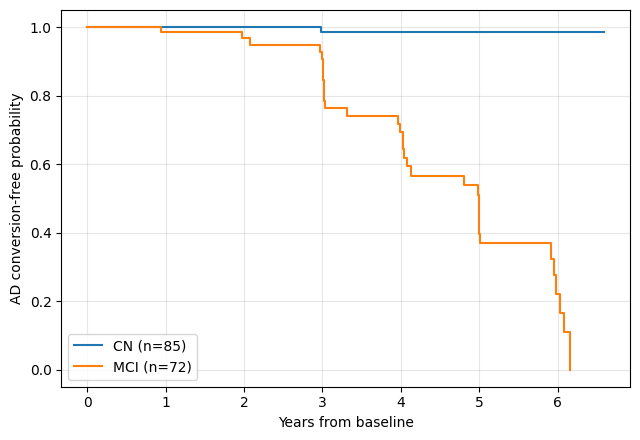

In [ ]:
def plot_km_by_baseline_diagnosis_endpoint_b(
    df=surv_ad_z,
    filename="figure_1_km_baseline_diagnosis_endpoint_b.png"
):
    dx_label_map = {0: "CN", 1: "MCI", 2: "AD"}
    plot_df = df.copy()

    if "DX_baseline_label" not in plot_df.columns:
        plot_df["DX_baseline_label"] = plot_df["DX_score_baseline"].map(dx_label_map)

    kmf = KaplanMeierFitter()

    plt.figure(figsize=(6.5, 4.5))

    for group in ["CN", "MCI"]:
        sub = plot_df[plot_df["DX_baseline_label"] == group]
        if len(sub) > 0:
            kmf.fit(
                sub["time_years"],
                sub["event"],
                label=f"{group} (n={len(sub)})"
            )
            kmf.plot(ci_show=False)

    plt.xlabel("Years from baseline")
    plt.ylabel("AD conversion-free probability")
    #plt.title("Endpoint B: AD conversion by baseline diagnosis")
    plt.grid(alpha=0.3)

    save_or_show(filename)

plot_km_by_baseline_diagnosis_endpoint_b()

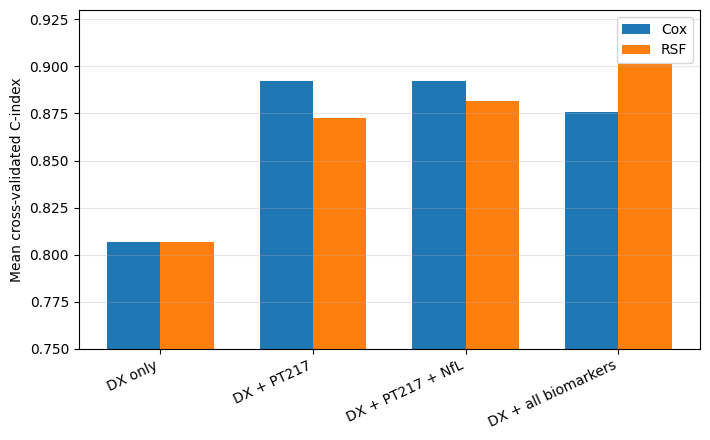

In [ ]:
def plot_cox_vs_rsf_endpoint_b(
    filename="figure_2_cox_vs_rsf_endpoint_b.png"
):
    plot_df = pd.DataFrame({
        "Model": [
            "DX only",
            "DX + PT217",
            "DX + PT217 + NfL",
            "DX + all biomarkers"
        ],
        "Cox": [0.806735, 0.892374, 0.892119, 0.875741],
        "RSF": [0.806735, 0.872544, 0.881860, 0.901169]
    })

    x = np.arange(len(plot_df))
    width = 0.35

    plt.figure(figsize=(7.2, 4.5))

    plt.bar(x - width / 2, plot_df["Cox"], width, label="Cox")
    plt.bar(x + width / 2, plot_df["RSF"], width, label="RSF")

    plt.xticks(x, plot_df["Model"], rotation=25, ha="right")
    plt.ylabel("Mean cross-validated C-index")
    plt.ylim(0.75, 0.93)
    #plt.title("Endpoint B: Cox and RSF model performance")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    save_or_show(filename)

plot_cox_vs_rsf_endpoint_b()

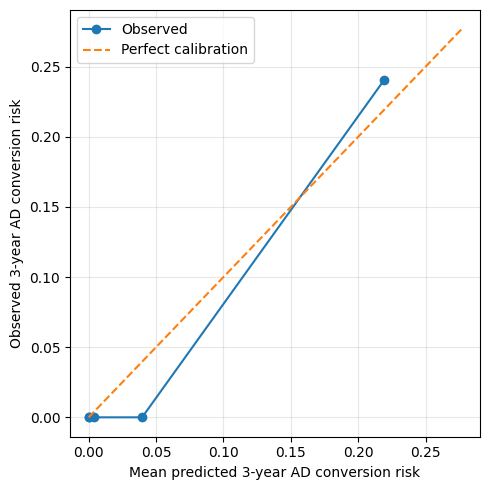

In [ ]:
def plot_calibration_endpoint_b(
    cal_df=cal_B,
    filename="figure_3_calibration_endpoint_b.png"
):
    plt.figure(figsize=(5, 5))

    plt.plot(
        cal_df["mean_predicted"],
        cal_df["observed"],
        marker="o",
        label="Observed"
    )

    max_axis = max(
        cal_df["mean_predicted"].max(),
        cal_df["observed"].max()
    ) * 1.15

    plt.plot(
        [0, max_axis],
        [0, max_axis],
        linestyle="--",
        label="Perfect calibration"
    )

    plt.xlabel("Mean predicted 3-year AD conversion risk")
    plt.ylabel("Observed 3-year AD conversion risk")
    #plt.title("Endpoint B: Calibration at 3 years")
    plt.legend()
    plt.grid(alpha=0.3)

    save_or_show(filename)

plot_calibration_endpoint_b()

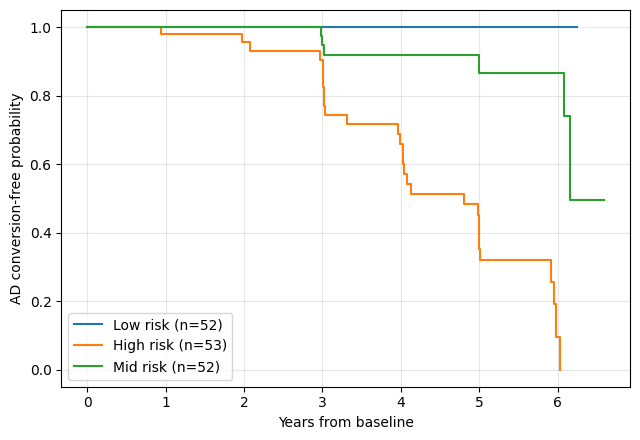

In [ ]:
def plot_km_by_cox_risk_group_endpoint_b(
    filename="figure_4_km_cox_risk_group_endpoint_b.png"
):
    cox_rg_B, cox_groups_B = add_risk_groups_from_cox(
        surv_ad_z,
        best_covars_B
    )

    kmf = KaplanMeierFitter()

    plt.figure(figsize=(6.5, 4.5))

    risk_order = ["Low", "Medium", "High", "G1", "G2", "G3"]

    groups = list(cox_groups_B["risk_group"].dropna().unique())
    groups = sorted(
        groups,
        key=lambda x: risk_order.index(x) if x in risk_order else 999
    )

    for group in groups:
        sub = cox_groups_B[cox_groups_B["risk_group"] == group]
        kmf.fit(
            sub["time_years"],
            sub["event"],
            label=f"{group} risk (n={len(sub)})"
        )
        kmf.plot(ci_show=False)

    plt.xlabel("Years from baseline")
    plt.ylabel("AD conversion-free probability")
    #plt.title("Endpoint B: AD conversion by Cox risk group")
    plt.grid(alpha=0.3)

    save_or_show(filename)

plot_km_by_cox_risk_group_endpoint_b()

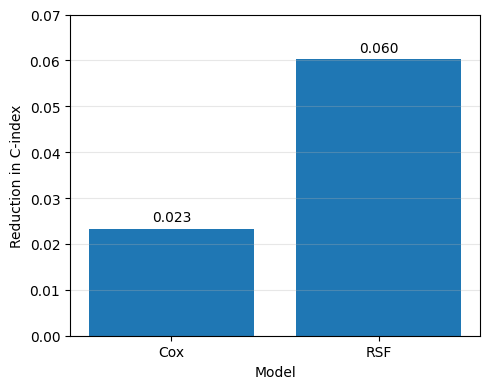

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Endpoint B ablation values
ablation_b = pd.DataFrame({
    "Model": ["Cox", "RSF"],
    "Drop in C-index": [0.023263, 0.060194]
})

plt.figure(figsize=(5, 4))

bars = plt.bar(
    ablation_b["Model"],
    ablation_b["Drop in C-index"]
)

plt.ylabel("Reduction in C-index")
plt.xlabel("Model")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.001,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 0.07)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("figure_pt217_ablation_endpoint_b.png", dpi=300, bbox_inches="tight")
plt.show()

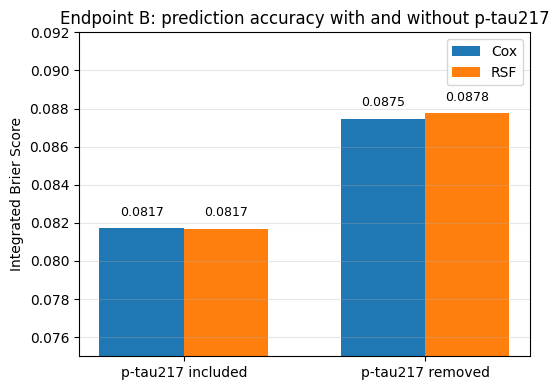

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Use Endpoint B only
ibs_b = summary_without_ptau[summary_without_ptau["endpoint"] == "B"].iloc[0]

plot_df = pd.DataFrame({
    "Model": ["Cox", "Cox", "RSF", "RSF"],
    "p-tau217": ["Included", "Removed", "Included", "Removed"],
    "IBS": [
        ibs_b["cox_ibs_with_ptau"],
        ibs_b["cox_ibs_without_ptau"],
        ibs_b["rsf_ibs_with_ptau"],
        ibs_b["rsf_ibs_without_ptau"]
    ]
})

x = np.arange(2)
width = 0.35

cox_values = plot_df[plot_df["Model"] == "Cox"]["IBS"].values
rsf_values = plot_df[plot_df["Model"] == "RSF"]["IBS"].values

plt.figure(figsize=(5.5, 4))

bars1 = plt.bar(x - width/2, cox_values, width, label="Cox")
bars2 = plt.bar(x + width/2, rsf_values, width, label="RSF")

plt.xticks(x, ["p-tau217 included", "p-tau217 removed"])
plt.ylabel("Integrated Brier Score")
plt.title("Endpoint B: prediction accuracy with and without p-tau217")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.0005,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.ylim(0.075, 0.092)
plt.tight_layout()

plt.savefig("figure_ibs_ptau217_endpoint_b.png", dpi=300, bbox_inches="tight")
plt.show()